# The Human Geography Factbook: Insights & Analysis on Populations

##### By Jex Pearce

## Sections: 

#### 1. Introduction

#### 2. A Worldwide Population Analysis

#### 3. Specific Country Population Reports

#### 4. Population Comparisons and Insights

#### 5. Economic Analysis


## 1. Introduction:

This project will take you on an in-depth exploration of population insights from countries around the world, providing a thorough analysis of key demographic trends. We'll first examine the world as a whole, using SQL, Python, and Geopandas to generate intuitive heatmaps of various metrics. Next, through a combination of population pyramids and other visualization libraries, you'll gain insights into today’s populations, such as Japan’s aging citizens, male-to-female ratios in countries like India, and Africa's booming youth population. Additionally, you'll understand how past events have shaped today’s populations, for example, how China’s demographic data responded to the 'One Child Policy,' the impact of Cambodia’s genocide, and the Gulf States’ labor immigration laws. After some additional population comparisons and a section on density, we’ll end with a bonus section on countries’ GDP per Capita, and their credit ratings.



For my dataset, I initially used the free data available from the CIA's World Factbook: (https://www.cia.gov/the-world-factbook/). I've then loaded this data into an SQLite database within Jupyter to efficiently query this large dataset for analysis.

##### Imports:

In [322]:
%load_ext sql
%sql sqlite:///factbook.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [323]:
%%sql
SELECT *
FROM facts
Where name LIKE '%union'
    OR name LIKE '%ocean'
    OR name LIKE '%island'
    OR name = 'World';


 * sqlite:///factbook.db
Done.


id,code,name,area,area_land,area_water,population,population_growth,birth_rate,death_rate,migration_rate
197,ee,European Union,4324782,None,None,513949445,0.25,10.2,10.2,2.5
199,kt,Christmas Island,135,135,0,1530,1.11,None,None,None
203,nf,Norfolk Island,36,36,0,2210,0.01,None,None,None
208,ip,Clipperton Island,6,6,0,None,None,None,None,None
222,bv,Bouvet Island,49,49,0,None,None,None,None,None
244,bq,Navassa Island,5,5,0,None,None,None,None,None
248,wq,Wake Island,6,6,0,None,None,None,None,None
256,xq,Arctic Ocean,None,None,None,None,None,None,None,None
257,zh,Atlantic Ocean,None,None,None,None,None,None,None,None
258,xo,Indian Ocean,None,None,None,None,None,None,None,None


## 2. Worldwide Population Analysis:

Starting simple, we will first conduct a brief look at the world's population as a whole before diving deeper into specific nations and their demographics.

#### Most Populated Countries:

In [324]:
%%sql
SELECT name AS '5 Most Populated Countries',
       population,
       ROUND(CAST(population AS FLOAT) /
             CAST((SELECT MAX(population) FROM facts) AS FLOAT), 3)
             AS world_population
FROM facts
WHERE code NOT IN ('ee', 'xx') AND population > 0
ORDER BY 2 DESC
LIMIT 5;

 * sqlite:///factbook.db
Done.


5 Most Populated Countries,population,world_population
China,1367485388,0.188
India,1251695584,0.172
United States,321368864,0.044
Indonesia,255993674,0.035
Brazil,204259812,0.028


China makes up 18.8% of the worlds population! Comparing it the USA, the third most populous nation, which only makes up 4.4%, China has 4.27 times more people.

#### Least Populated Territories:

In [325]:
%%sql
SELECT name, population
FROM facts
WHERE code NOT IN ('ee', 'xx') AND population > 0 
ORDER BY population ASC
LIMIT 10;

 * sqlite:///factbook.db
Done.


name,population
Pitcairn Islands,48
Cocos (Keeling) Islands,596
Holy See (Vatican City),842
Niue,1190
Tokelau,1337
Christmas Island,1530
Svalbard,1872
Norfolk Island,2210
Falkland Islands (Islas Malvinas),3361
Montserrat,5241


The only UN recognized country on this list is the Vatican City. The remaining entries are either territories, dependencies, or unrecognized states.

I'll now convert the CIA Factbook database from SQLite to Pandas, in order to use the incredibly useful plugin called 'Geopandas', which allows us to analyze metrics visually on a global scale.

In [494]:
import sqlite3
import pandas as pd

cnx = sqlite3.connect('factbook.db')
#Need to match the names with the geopandas names to create a worldmap below. This took a lot longer than I wanted  it to take.
df = pd.read_sql_query("SELECT CASE name WHEN 'United States' THEN 'United States of America' WHEN 'Congo, Democratic Republic of the' THEN 'Democratic Republic of the Congo' WHEN 'Burma' THEN 'Myanmar' WHEN 'Korea, South' THEN 'South Korea' WHEN 'Congo, Republic of the' THEN 'Republic of the Congo' WHEN 'Cote d''Ivoire' THEN 'Ivory Coast' WHEN 'Tanzania' THEN 'United Republic of Tanzania' WHEN 'Czech Republic' THEN 'Czechia' WHEN 'Serbia' THEN 'Republic of Serbia' WHEN 'Macedonia' THEN 'North Macedonia' ELSE name END as corrected_name, * FROM facts", cnx)
df.head()

,corrected_name,id,code,name,area,area_land,area_water,population,population_growth,birth_rate,death_rate,migration_rate
0,Afghanistan,1,af,Afghanistan,652230.0,652230.0,0.0,32564342.0,2.32,38.57,13.89,1.51
1,Albania,2,al,Albania,28748.0,27398.0,1350.0,3029278.0,0.30,12.92,6.58,3.30
2,Algeria,3,ag,Algeria,2381741.0,2381741.0,0.0,39542166.0,1.84,23.67,4.31,0.92
3,Andorra,4,an,Andorra,468.0,468.0,0.0,85580.0,0.12,8.13,6.96,0.00
4,Angola,5,ao,Angola,1246700.0,1246700.0,0.0,19625353.0,2.78,38.78,11.49,0.46


### The Worldwide Population Heatmap:

7


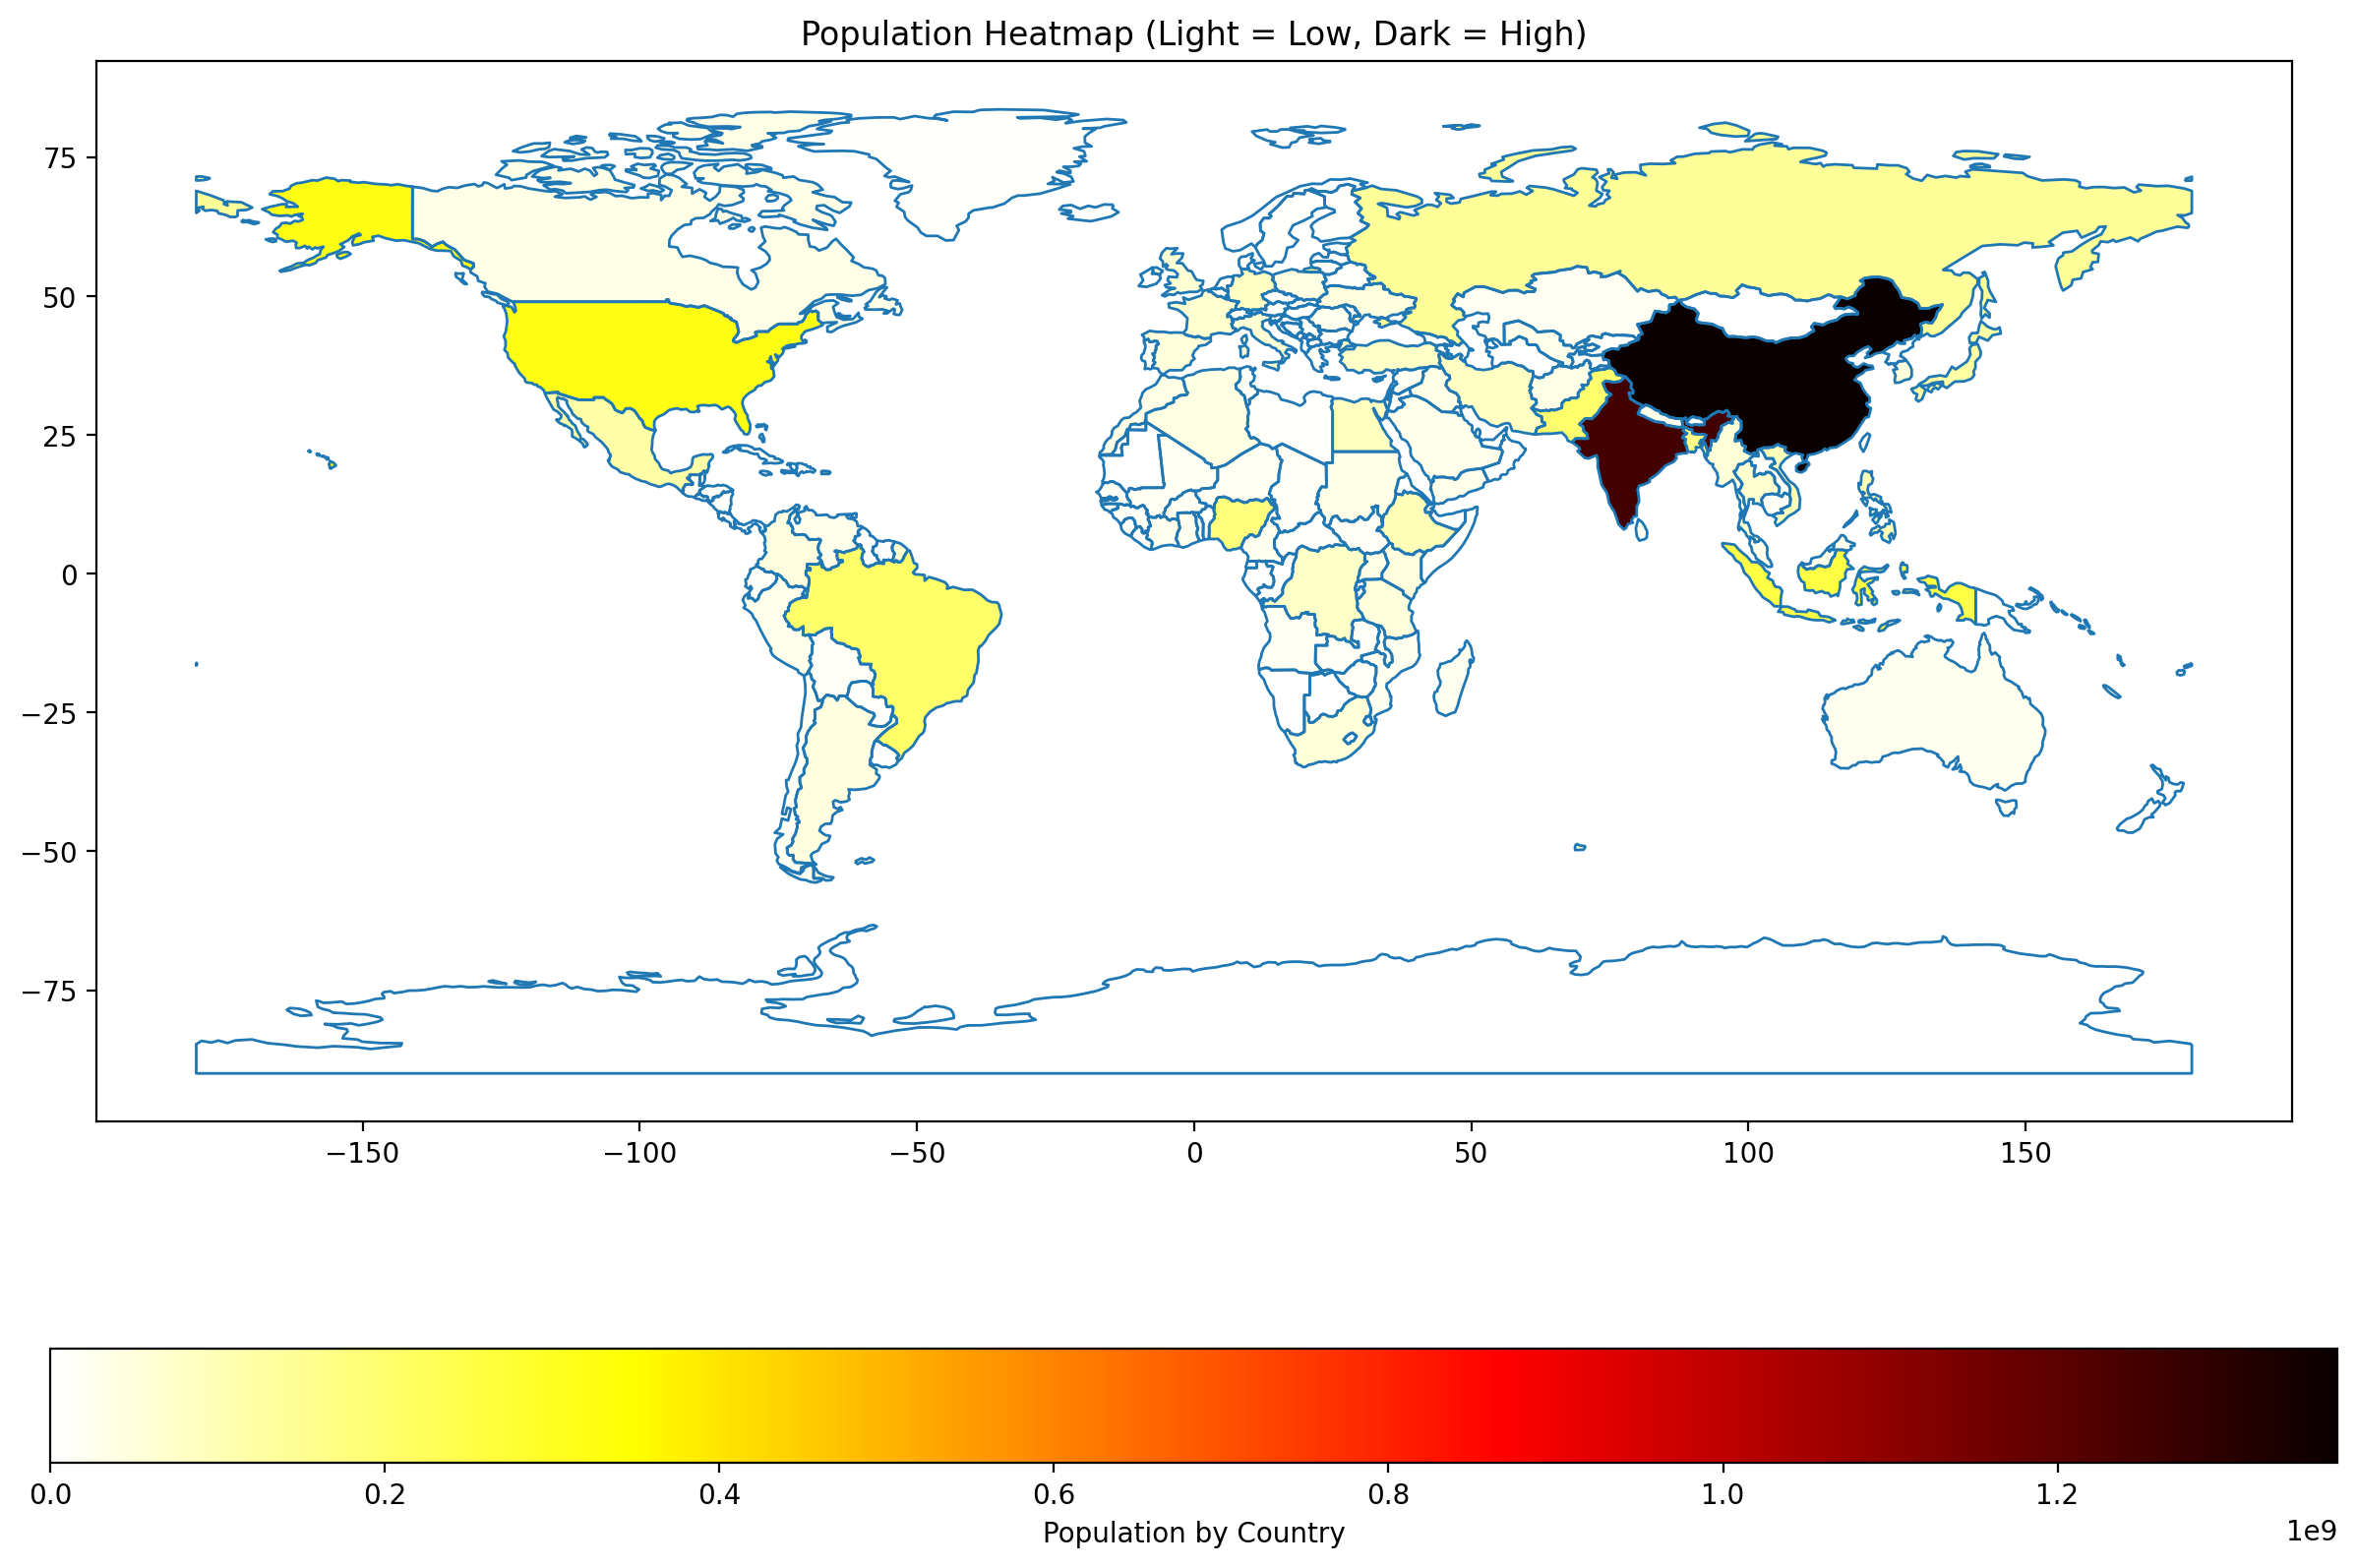

In [493]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file('110m_cultural/ne_110m_admin_0_countries.shp')
df_filtered = df[(df['corrected_name'] != 'European Union') & (~df['corrected_name'].str.contains('Ocean'))]
merged = world.merge(df_filtered, left_on='SOVEREIGNT', right_on='corrected_name', how='left')
print(merged['population'].isnull().sum())
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.boundary.plot(ax=ax, linewidth=1)
merged.plot(column='population', cmap='hot_r', legend=True, ax=ax,
            legend_kwds={'label': "Population by Country",
                         'orientation': "horizontal"})
plt.title('Population Heatmap (Light = Low, Dark = High)')
plt.show()

It's important to note for the sake of visual accuracy, that while Somaliland and Western Sahara are recognized by the Geopandas worldmap, they are not acknowledged by the CIA's factbook, resulting in a blank area on the map in those regions. 

Notice the extremeties in population from countries like China and India. We will now take a deeper look at their population demographics.

## 3. Specific Country Population Reports

##### More Imports:

In [492]:
import numpy as np

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [329]:
data = pd.read_csv('populationpyramid1950-2022.csv')

In [331]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44604 entries, 0 to 44603
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Country  44604 non-null  object
 1   Year     44604 non-null  int64 
 2   Age      44604 non-null  object
 3   M        44604 non-null  int64 
 4   F        44604 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.7+ MB


In [491]:
def filter(
    country_ddl=data["Country"].unique(),
    year_ddl=data["Year"].unique(),
):
    return data[(data["Country"] == country_ddl) & (data["Year"] == year_ddl)] 
#this filter function returns a filtered DataFrame where the "Country" column matches the selected country and the "Year" column matches the selected year.

### Population Pyramid Reports: The UK

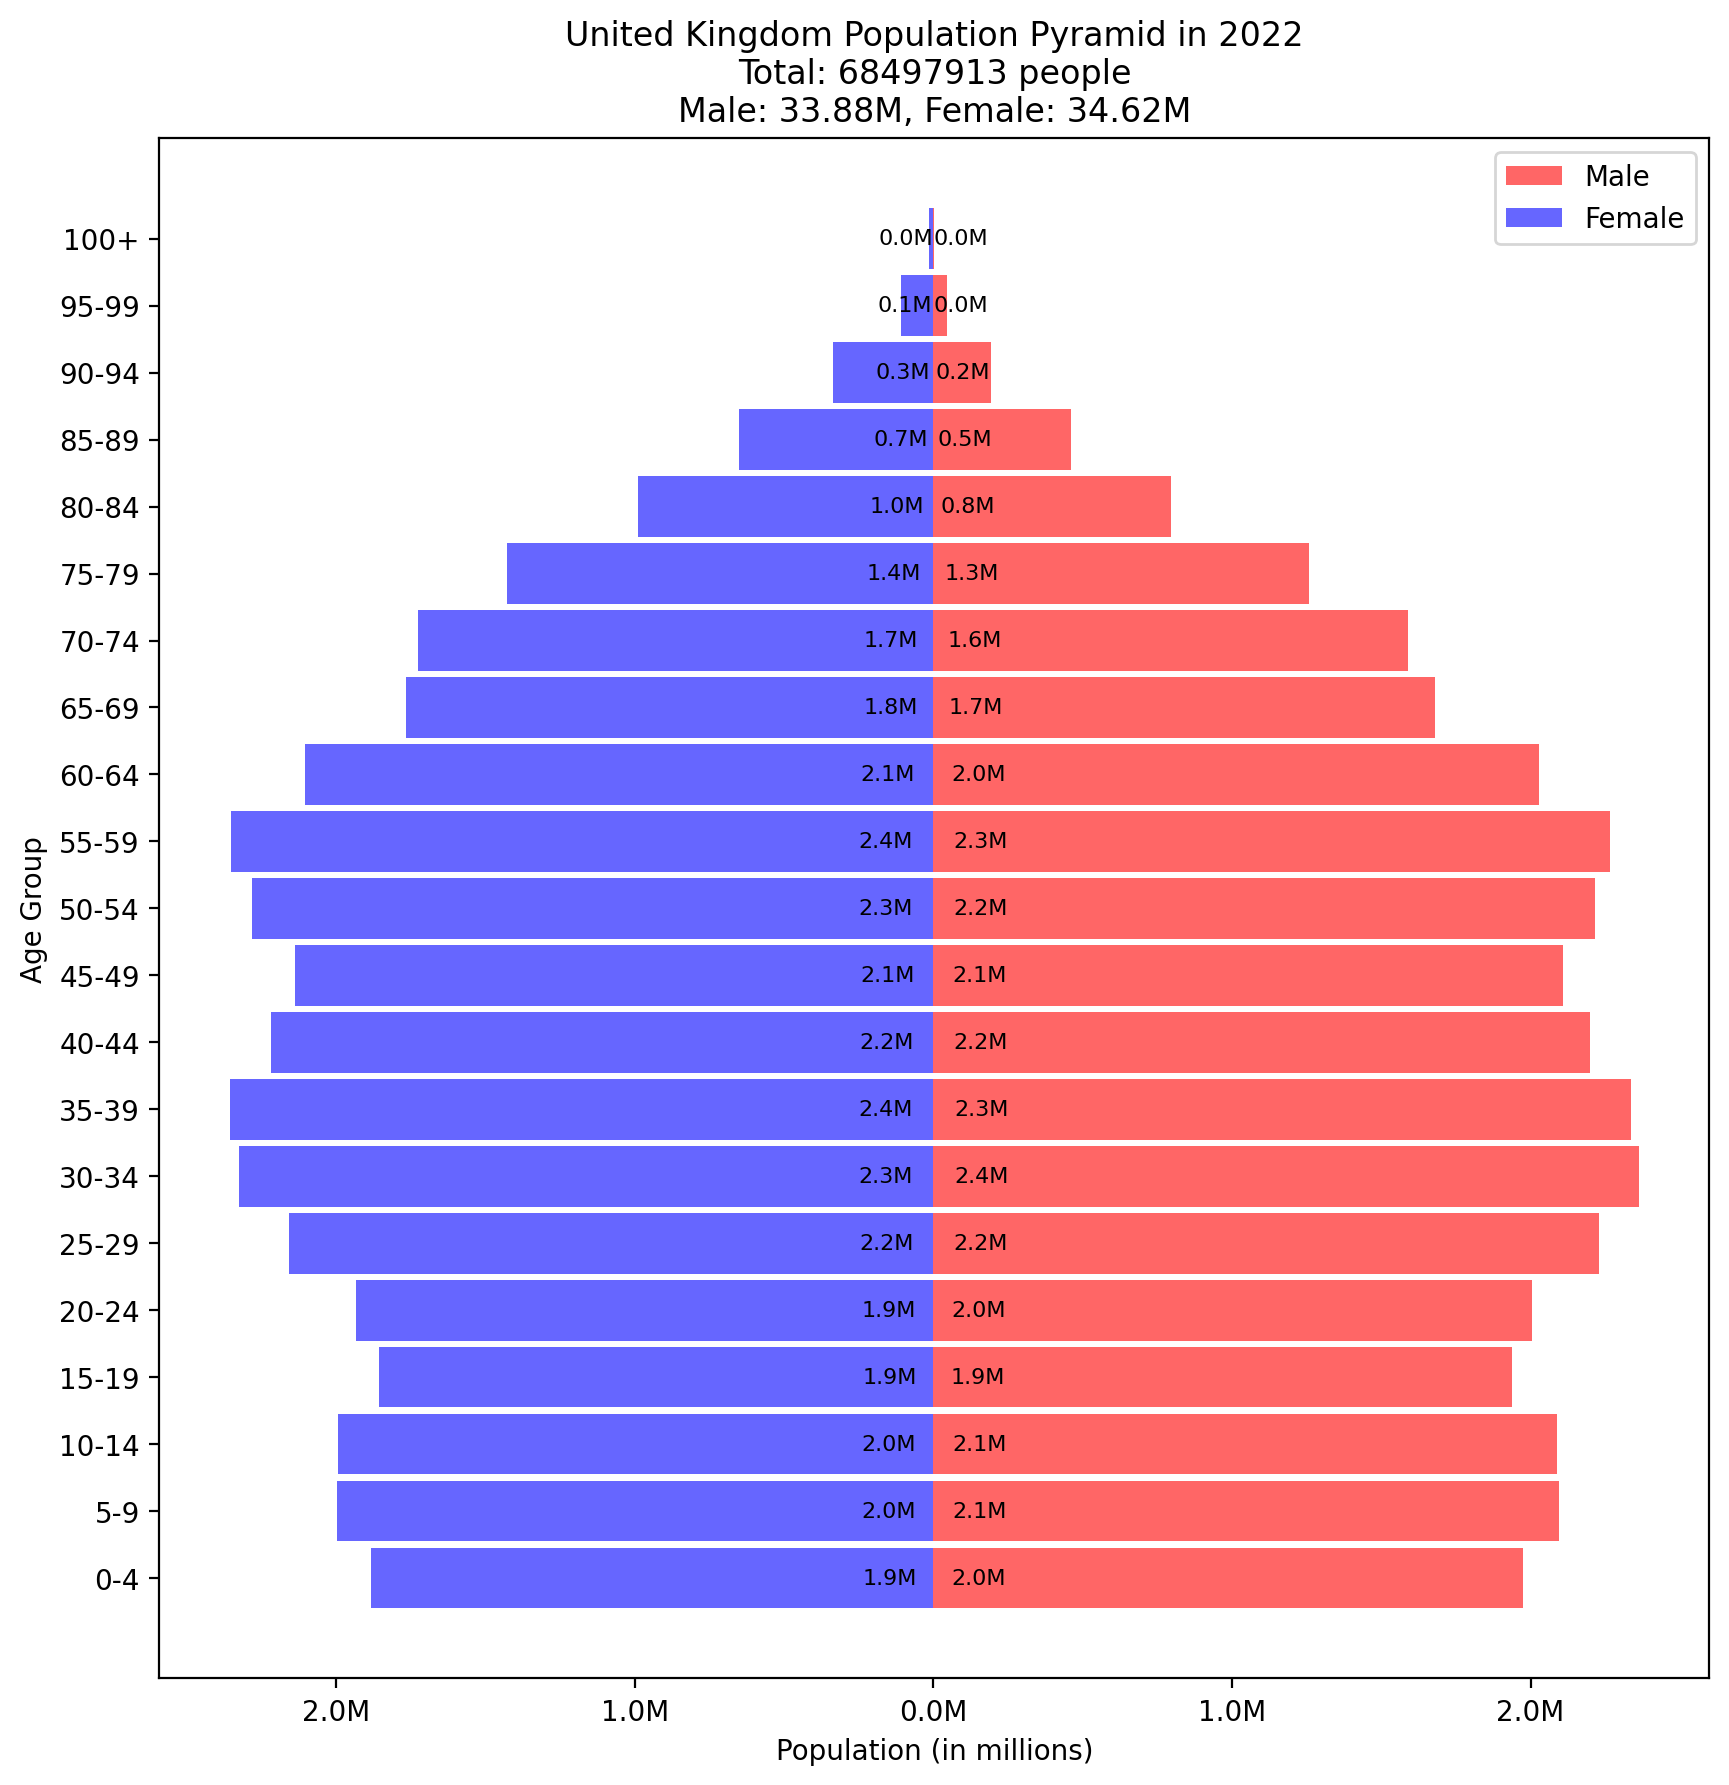

In [333]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter #Necessary import

def populationpyramid(country="Thailand", year=2022): #Example country
    #this is just a function to handle large numbers in the millions, purely for visual clarity
    def formatmillions(value, tick_position):
        return f"{abs(value) / 1e6:.1f}M"

    populationdata = filter(country, year)
    agegroups = populationdata["Age"].values
    malepopulation = populationdata["M"].values
    femalepopulation = populationdata["F"].values

    #calculating total population
    totalmale = malepopulation.sum()
    totalfemale = femalepopulation.sum()
    totalpopulation = totalmale + totalfemale
    y_positions = np.arange(len(agegroups))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.xaxis.set_major_formatter(FuncFormatter(formatmillions))

    #plotting the population data: male as negative values, female as positive for the graph

    ax.barh(y_positions, malepopulation, color="red", label="Male", alpha=0.6, height=0.9)
    ax.barh(y_positions, -femalepopulation, color="blue", label="Female", alpha=0.6, height=0.9)
    for i in range(len(agegroups)):
        ax.text(malepopulation[i] * 0.03, i, f"{malepopulation[i] / 1e6:.1f}M",
                va='center', ha='left', fontsize=8)
        ax.text(-femalepopulation[i] * 0.03, i, f"{femalepopulation[i] / 1e6:.1f}M",
                va='center', ha='right', fontsize=8)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(agegroups)
    ax.set_xlabel("Population (in millions)")
    ax.set_ylabel("Age Group")
    ax.set_title(f"{country} Population Pyramid in {year}\nTotal: {totalpopulation} people\n"
                 f"Male: {totalmale / 1e6:.2f}M, Female: {totalfemale / 1e6:.2f}M")

    ax.legend(loc="upper right")
    plt.show()
populationpyramid("United Kingdom", 2022)


Starting with the United Kingdom, we see a relatively average population pyramid. Ripple effects in birth rates from WW2 can be seen, as the decrease in citizens (particularly male) in the 1940s lead to a slightly less population of citizens eligible to have families every 20-30 years. But it's nothing too severe. This is an example of a healthy population pyramid, with these demographic characteristics being shared by the majority of developed European nations and the USA. 

### India

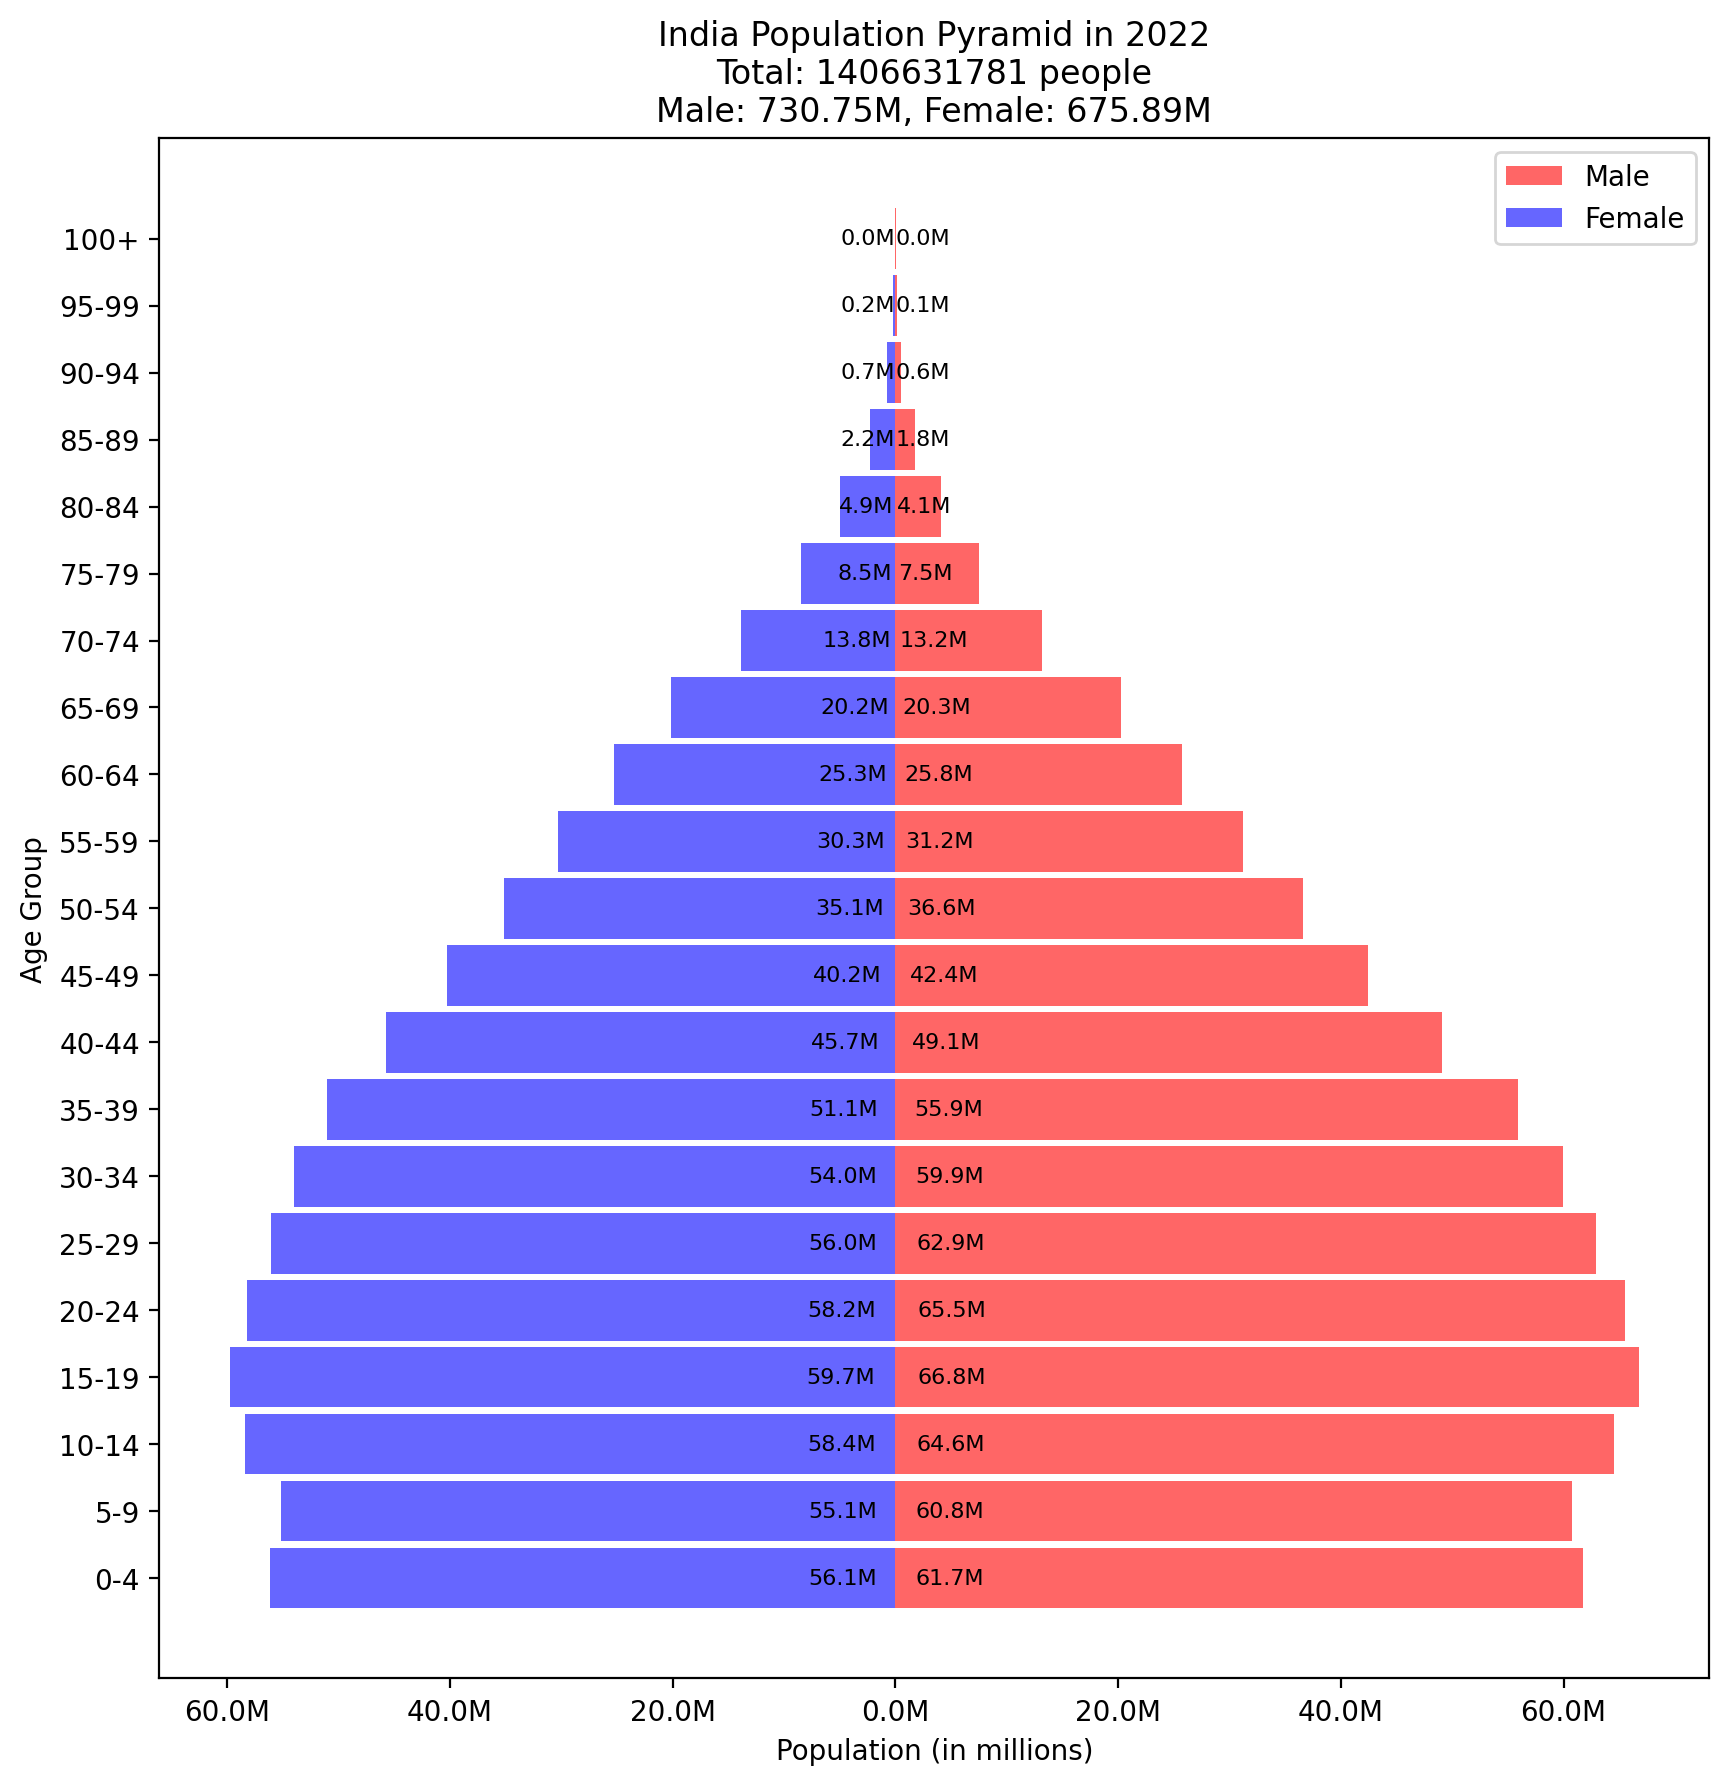

In [334]:
populationpyramid("India", 2022)

At a glance, this may look like a normal population pyramid. However, after a better look you can see how extreme the gender balance is. There are 21.3 MILLION more men than women in the 15-29 age group, and this surplus of indian men has had disastrous social effects on India.

- Given this aforementioned age group is the range in when marriage is typically sought after, this increased level of competition has caused profound irritation among Indian men in the dating pool. Sociologists argue that frustration and a sense of deprivation can increase aggression toward women leading to a 71.7% increase in reported rape cases in the last 16 years. (source: https://www.statista.com/statistics/632493/reported-rape-cases-india/). The amount of unreported cases is likely much higher.

- In the rural parts of India, the surplus of men has fueled human trafficking and forced marriages, where women and girls are often trafficked from poorer regions to meet the demand for brides.

All of this results in a serious problem for India, and the government is taking many steps to combat it. Programs like the Beti Bachao Beti Padhao (Save the Daughter, Educate the Daughter) campaign focuses on preventing gender-biased sex-selective elimination, raising rape awareness, and promoting education for girls.

Incorporating time as a new variable, lets take a further look at that very interesting Male-to-Female ratio India has:

#### Male-to-Female Ratio of Babies in India over the years 

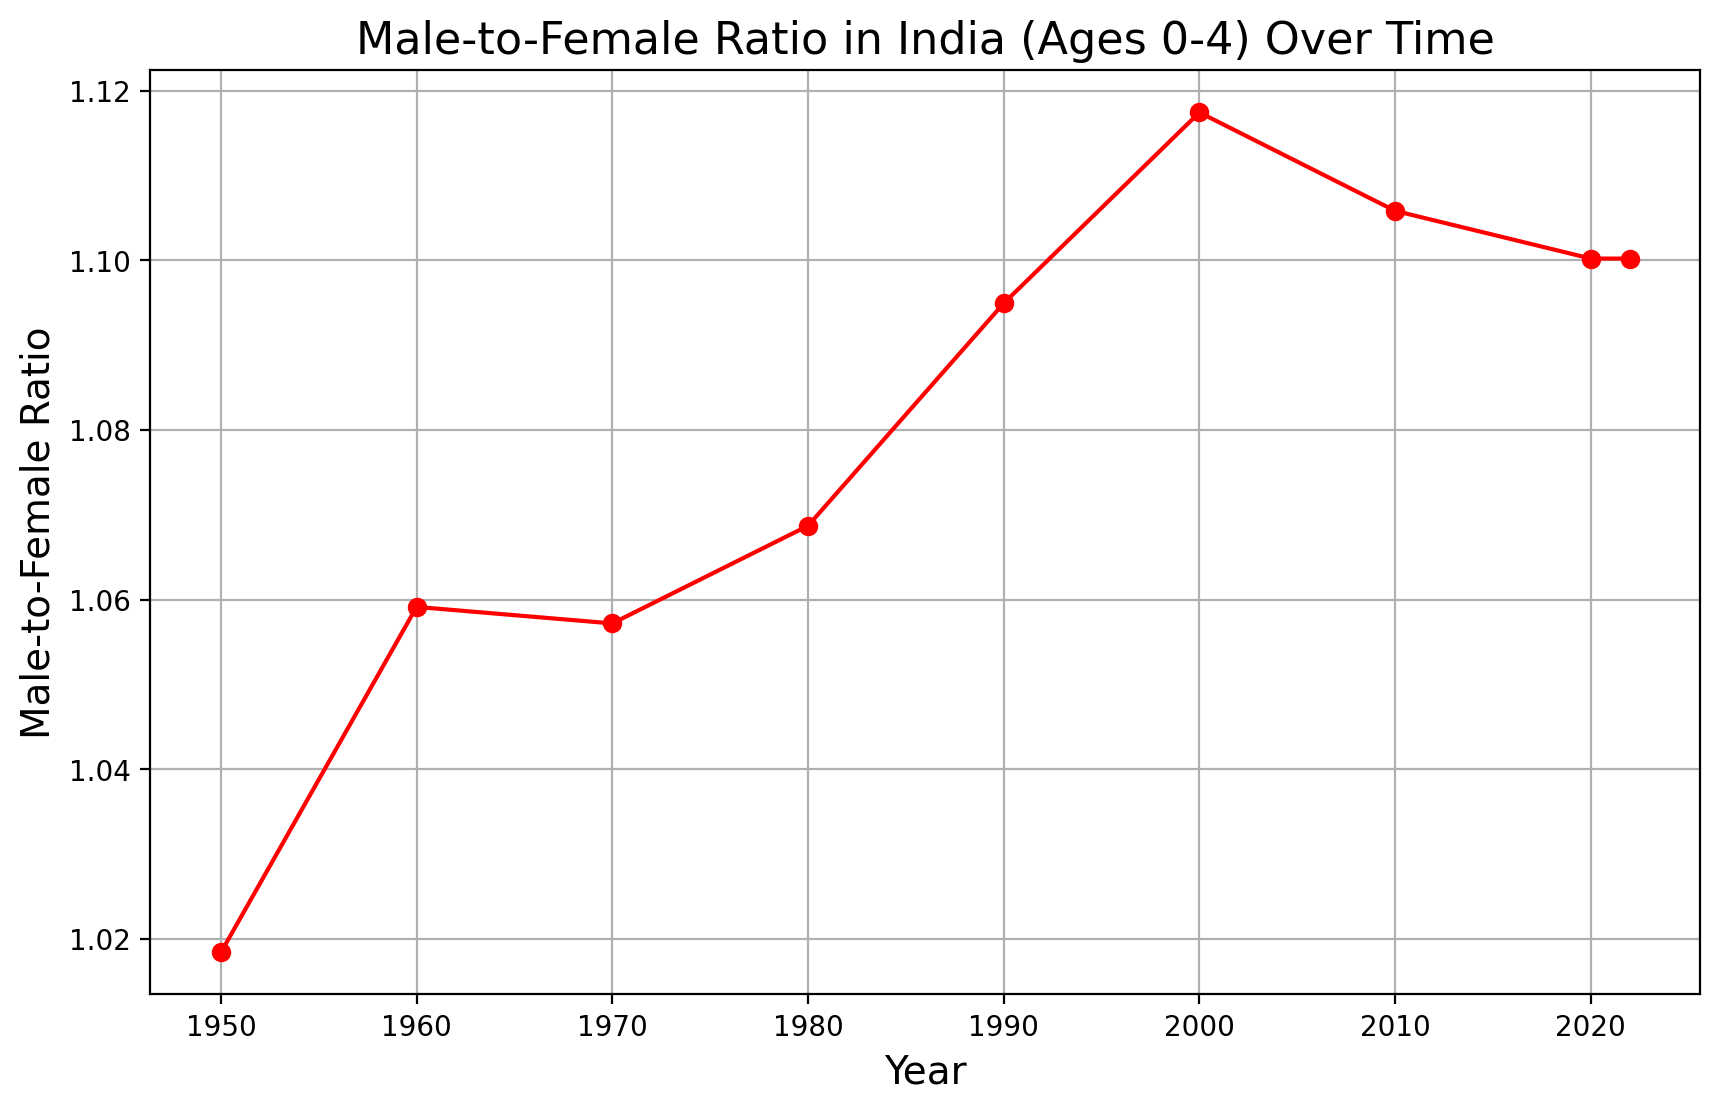

In [335]:
import matplotlib.pyplot as plt

indiadata = data[(data['Country'] == 'India') & (data['Age'] == '0-4')].copy()
indiagenderpopulation = indiadata.groupby('Year')[['M', 'F']].sum().reset_index()
indiagenderpopulation['M_to_F_Ratio'] = indiagenderpopulation['M'] / indiagenderpopulation['F']

plt.figure(figsize=(10,6))
plt.plot(indiagenderpopulation['Year'], indiagenderpopulation['M_to_F_Ratio'], marker='o', color='r')
plt.title('Male-to-Female Ratio in India (Ages 0-4) Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Male-to-Female Ratio', fontsize=14)
plt.grid(True)

Throughout time, the skewed male-to-female ratio in India has had historical and cultural roots. Traditionally, Indian society valued sons more than daughters for several reasons:

- **Dowry System**: Families of girls were expected to pay a dowry during marriage, which was seen as a financial burden. This made having daughters less desirable, especially in rural areas.

- **Economic Contribution**: Traditionally, young boys have been viewed as a valuable long-term investment because they are expected to contribute more labor in agricultural work and support the family financially as they grow older, compared to girls.

- **Female Feticide**: With the availability of sex-selective technology, some families resorted to female feticide to avoid having daughters, worsening the gender ratio.

There have been recent government interventions to put an end to the Female Feticide atrocities. The Pre-Conception and Pre-Natal Diagnostic Techniques (PCPNDT) prohibits sex selection and the misuse of pre-natal diagnostic techniques to determine the sex of a fetus. Implemented in the early 2000s, it's clear this has had a positive effect on the ratio since.


At its peak, in 2000, before efforts were made by the indian government to tackle infanticide of girls, for every 100 girls, 111 boys are also born, leading to a surplus of 11 males in that respective cohort.

### China

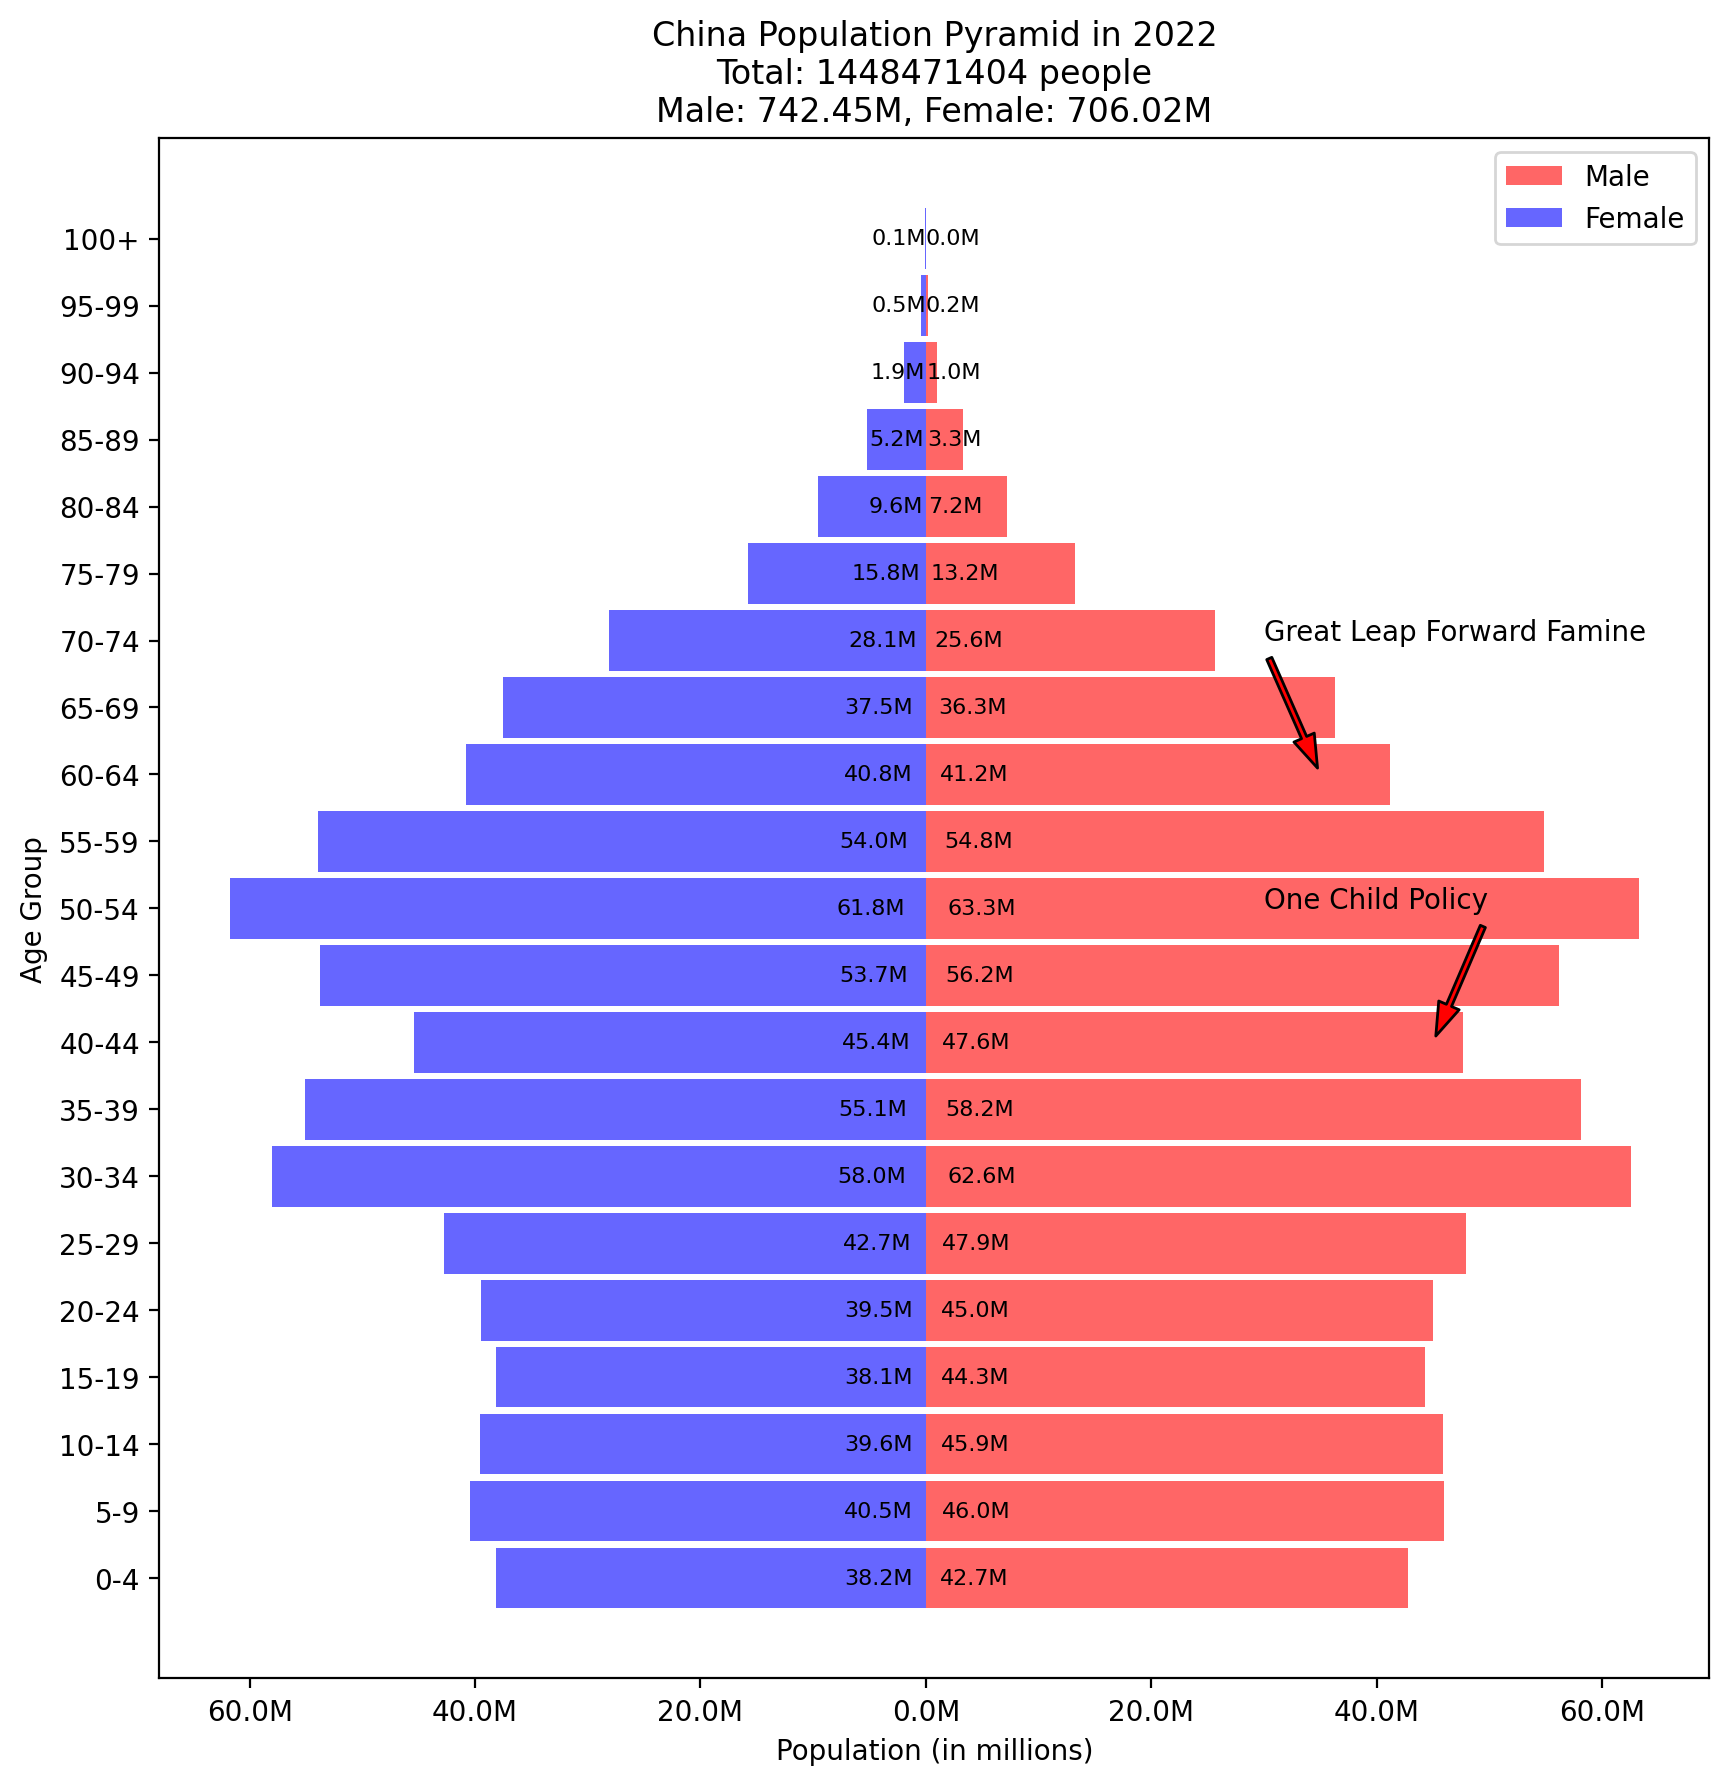

In [490]:
def annotationpopulationpyramid(country="China", year=2022): 
    #this is just a function to handle large numbers in the millions, purely for visual clarity
    def formatmillions(value, tick_position):
        return f"{abs(value) / 1e6:.1f}M"

    populationdata = filter(country, year)
    agegroups = populationdata["Age"].values
    malepopulation = populationdata["M"].values
    femalepopulation = populationdata["F"].values

    #calculating total population
    totalmale = malepopulation.sum()
    totalfemale = femalepopulation.sum()
    totalpopulation = totalmale + totalfemale
    y_positions = np.arange(len(agegroups))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.xaxis.set_major_formatter(FuncFormatter(formatmillions))

    ax.barh(y_positions, malepopulation, color="red", label="Male", alpha=0.6, height=0.9)
    ax.barh(y_positions, -femalepopulation, color="blue", label="Female", alpha=0.6, height=0.9)
    for i in range(len(agegroups)):
        ax.text(malepopulation[i] * 0.03, i, f"{malepopulation[i] / 1e6:.1f}M",
                va='center', ha='left', fontsize=8)
        ax.text(-femalepopulation[i] * 0.03, i, f"{femalepopulation[i] / 1e6:.1f}M",
                va='center', ha='right', fontsize=8)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(agegroups)
    ax.set_xlabel("Population (in millions)")
    ax.set_ylabel("Age Group")
    ax.set_title(f"{country} Population Pyramid in {year}\nTotal: {totalpopulation} people\n"
                 f"Male: {totalmale / 1e6:.2f}M, Female: {totalfemale / 1e6:.2f}M")

    ax.legend(loc="upper right")
    return ax

ax = annotationpopulationpyramid("China", 2022)
ax.annotate('Great Leap Forward Famine',
            xy=(35000000,12), 
            xytext=(30000000, 14),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')

ax.annotate('One Child Policy',
            xy=(45000000, 8), 
            xytext=(30000000, 10),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')

plt.show()


- As shown above, you can see firsthand the effects of these historical events on China's population. The Great famine in the 1950s killed over 30 million.

However, the main culprit for China's aging population is most certainly due to Deng Xiaoping's One Child Policy, implemented in the late 1970s. With parents only being able to have one child, many in rural areas opted for female infanticide in order to ensure that they had a boy. Like the situation in India, a son will generally yield greater profit especially in the agricultural fields in comparison to a daughter. It was so severe, that academics often talk about between 30 and 60 million “missing girls” in China, that were either killed in the womb or after birth, due to the aforementioned preference for sons and the repressive one-child policy. It's also important to note that the data for female infanticide was heavily covered up by the Chinese Communist party in the 1980s, leading to inaccurate ratios ever since.


#### Male-to-Female Ratio of Babies in China over the years

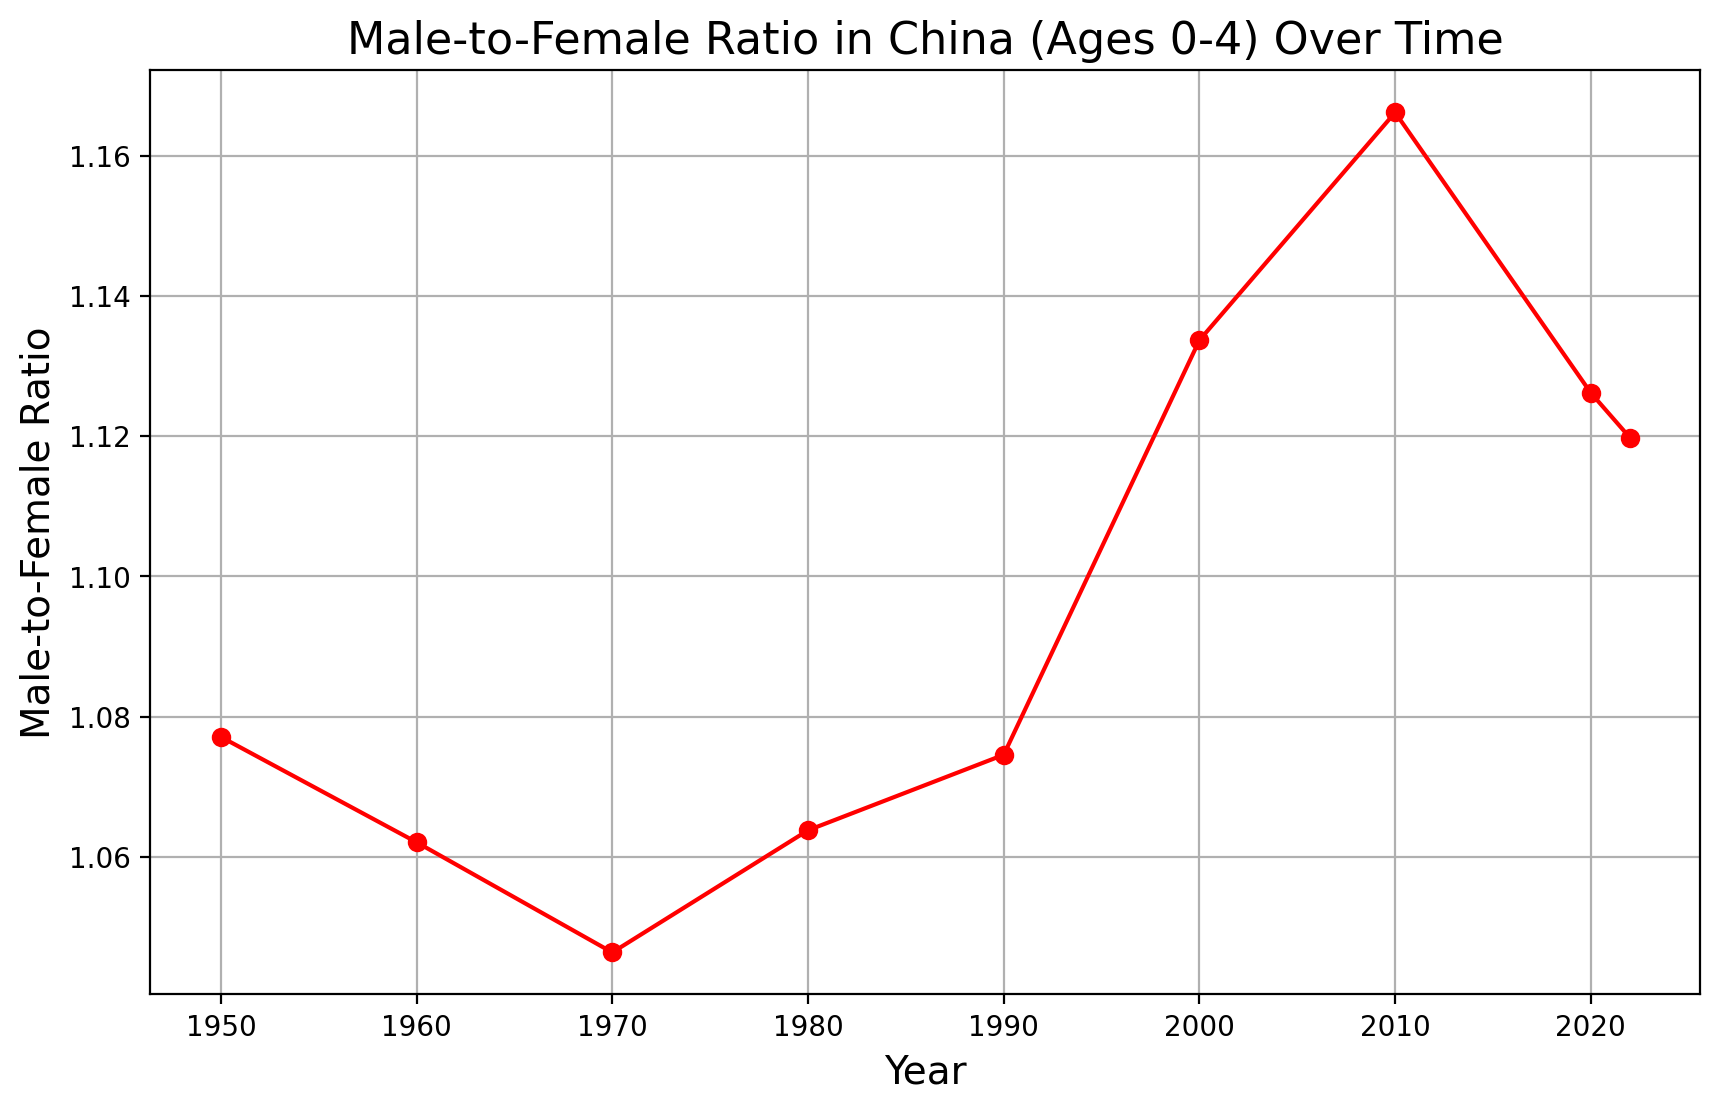

In [337]:
chinadata = data[(data['Country'] == 'China') & (data['Age'] == '0-4')].copy()
chinagenderpopulation = chinadata.groupby('Year')[['M', 'F']].sum().reset_index()
chinagenderpopulation['M_to_F_Ratio'] = chinagenderpopulation['M'] / chinagenderpopulation['F']

plt.figure(figsize=(10,6))
plt.plot(chinagenderpopulation['Year'], chinagenderpopulation['M_to_F_Ratio'], marker='o', color='r')
plt.title('Male-to-Female Ratio in China (Ages 0-4) Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Male-to-Female Ratio', fontsize=14)
plt.grid(True)

- In 2010, for every 100 girls born, 117 boys were born

China has since introduced various government incentives to encourage families to have daughters and address the gender ratio imbalance. Some of these measures include: 

- **Financial Support**: In several regions, local governments provided financial incentives to families with daughters, especially in rural areas. These included direct financial payments, subsidies for education, and healthcare support aimed at easing the economic burden traditionally associated with raising girls. 

- **Relaxation of the One-Child Policy**: In rural areas, China allowed families to have a second child if their first child was a girl. This measure was implemented to balance the preference for sons by encouraging families to keep their first-born daughters rather than aborting female fetuses. 

- **Subsidies for Single-Daughter Households**: Some local governments offered economic benefits to families who chose to have only one child and that child was a girl. These subsidies were provided to help cover education and living expenses, reducing the financial concerns often associated with raising daughters.

These government programs have clearly made a difference since, as can see above.

### Japan

Text(2400000, 14, 'Ripple Effect of WW2')

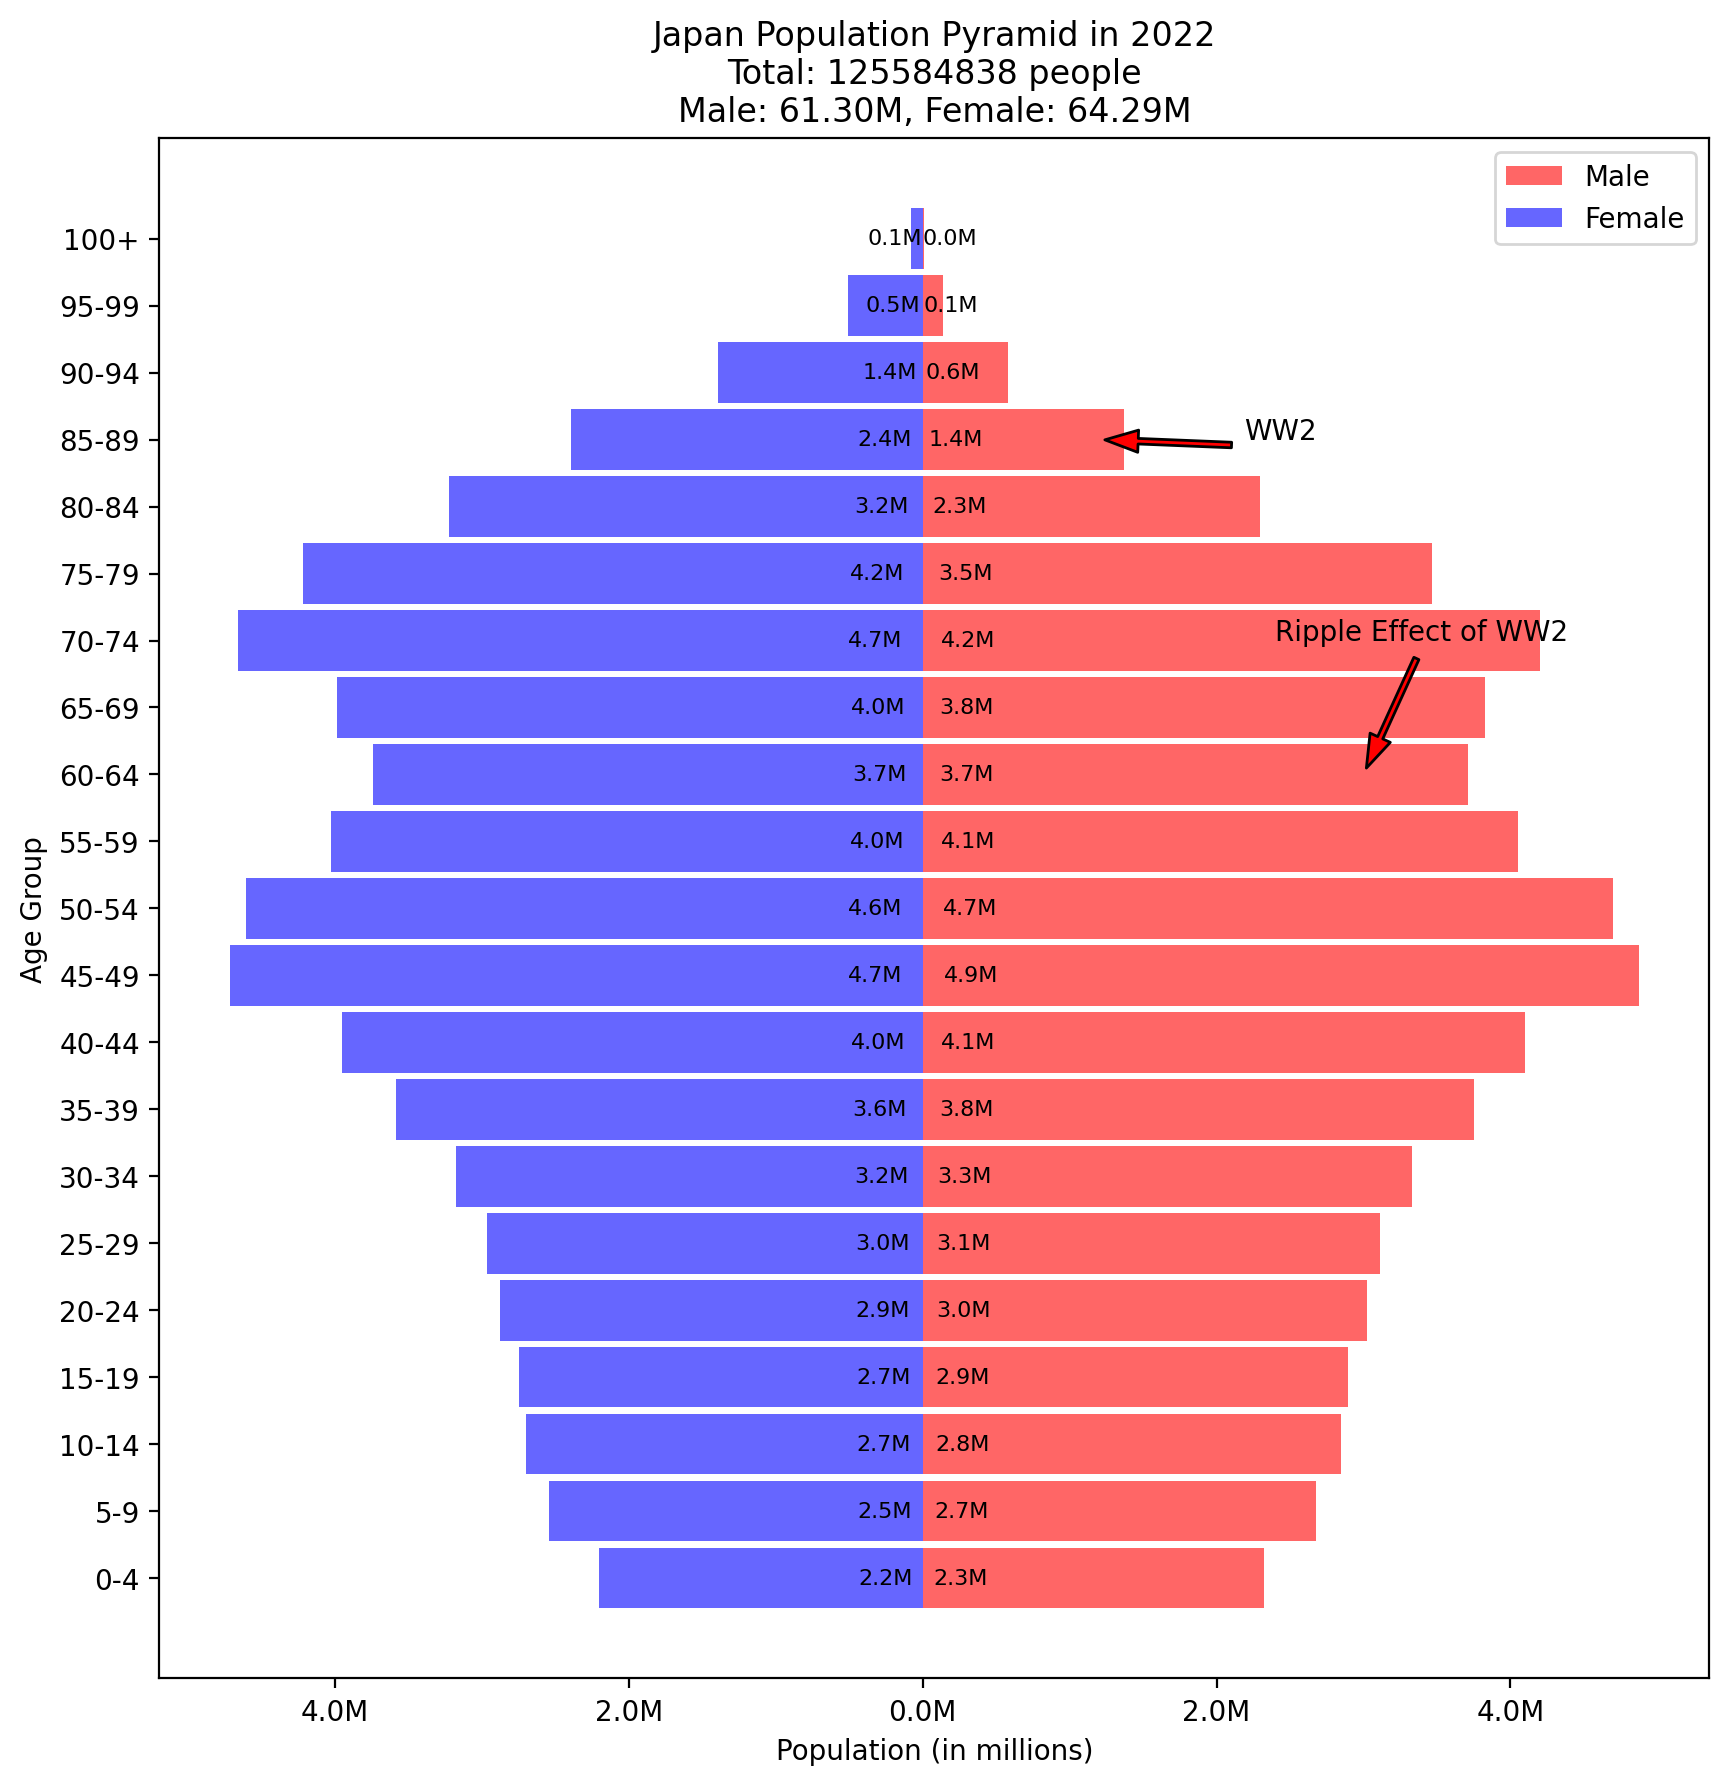

In [338]:
ax = annotationpopulationpyramid("Japan", 2022)
ax.annotate('WW2',
            xy=(1190000,17), 
            xytext=(2190000, 17),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')

ax.annotate('Ripple Effect of WW2',
            xy=(3000000, 12), 
            xytext=(2400000, 14),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')

Japan is suffering from an aging population. Let's take a deeper dive into that. 

- The sharp decrease in males above the age of 80 in comparison to women is most certainly due to the second world war, where young Japanese men suffered the second most deaths relative to the overall population after the USSR. This decrease in young men in the 1950s led to a ripple effect 20-25 years later.

- After the Gen X baby boom, many countries, including Japan, experienced a sharp decline in birth rates due to various factors, such as economic changes, urbanization, and shifts in social norms. Japan in particular saw significant economic growth after WW2, and as people moved to cities, had better access to education, and women joined the workforce, family sizes began to decrease. 

- The main culprit in the 21st century, while not statistically examinable, is most certainly Japan's competitive work culture, which is seen as extreme compared to other developed nations. This loss of free time is most definitely a strong reason for why fewer adults are having children. (source: https://www.theatlantic.com/business/archive/2017/07/japan-mystery-low-birth-rate/534291/)

#### Dependancy Ratio:

The dependency ratio is a measure of the proportion of dependents (young and elderly) to the working-age population. Typically, dependents are considered to be those under 15 years old and those 65 years or older, while the working-age population is considered to be those aged 15 to 64.

\begin{equation}
\text{Total Dependency Ratio} = \frac{   \text{(Children age 0-14)} + \text{(Elderly age > 65)}}{\text{(Population age 15-65)}} \times 100
\end{equation}

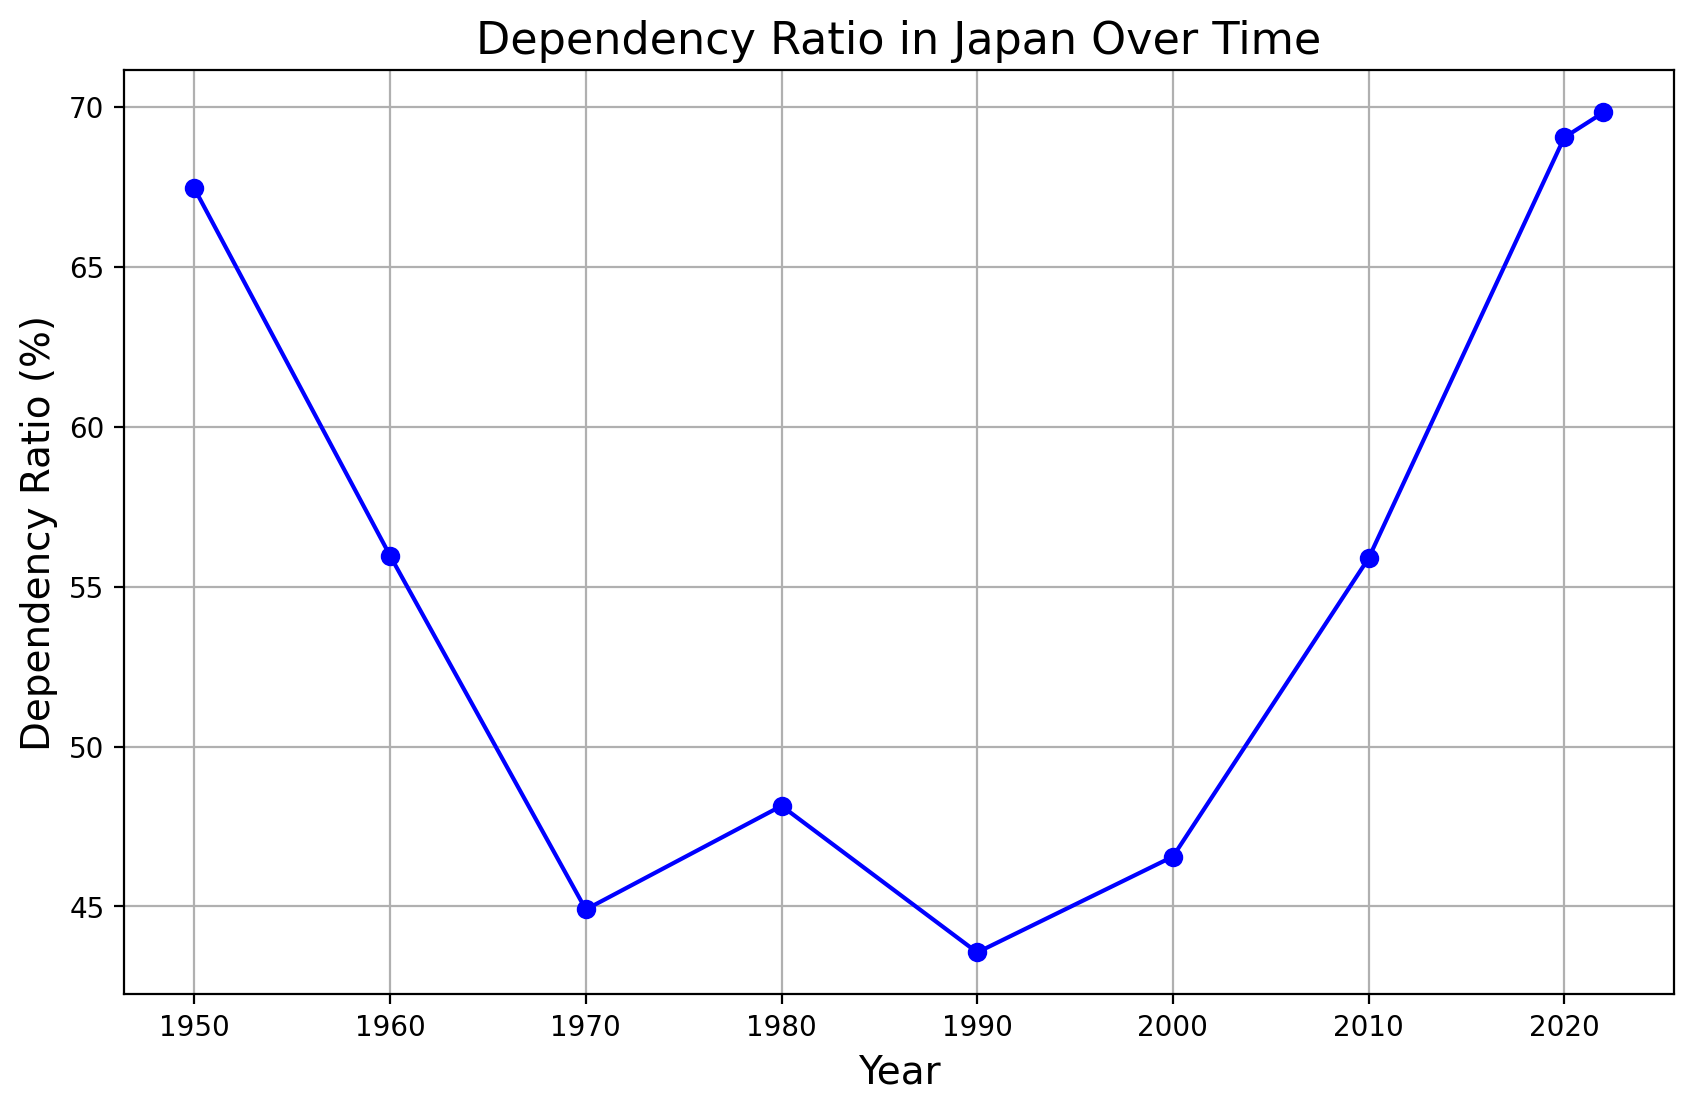

In [375]:
import seaborn as sns

japandata = data[data['Country'] == 'Japan'].copy()

# define the age groups for young dependents (0-14), working-age (15-64), and elderly dependents (65+)
youngdependents = japandata[japandata['Age'].isin(['0-4', '5-9', '10-14'])].groupby('Year')[['M', 'F']].sum()
workingage = japandata[japandata['Age'].isin(['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64'])].groupby('Year')[['M', 'F']].sum()
elderlydependents = japandata[japandata['Age'].isin(['65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95-99', '100+'])].groupby('Year')[['M', 'F']].sum()

#calculating the proportionsssss
youngdependents['Total'] = youngdependents['M'] + youngdependents['F']
workingage['Total'] = workingage['M'] + workingage['F']
elderlydependents['Total'] = elderlydependents['M'] + elderlydependents['F']
dependencyratio = (youngdependents['Total'] + elderlydependents['Total']) / workingage['Total'] * 100

plt.figure(figsize=(10,6))
plt.plot(dependencyratio.index, dependencyratio, marker='o', color='b')
plt.title('Dependency Ratio in Japan Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Dependency Ratio (%)', fontsize=14)
plt.grid(True)

Japan had a high Dependency Ratio in 1950 due to the lack of youth from the war being able to help the elderly. The ratio is now even higher, at roughly 70%.

A dependency ratio of 70% means that for every 100 working-age individuals (typically ages 15-65), there are 70 people who are considered dependent, meaning they are either too young (under 15) or too old (over 64) to work. In other words, the working-age population is supporting 70 dependents for every 100 workers. This ratio conveys the disastrous economic pressure on the working-age population to support these non-working citizens.

In [340]:
#for 2022
dependencyratio2022 = dependencyratio.loc[2022]
print(f"Percentage: {dependencyratio2022:.2f}%")

Percentage: 69.83%


Japan had a 69.3% Dependency Ratio in 2022

### Cambodia

Text(600000, 10, "Pol Pot's Genocide")

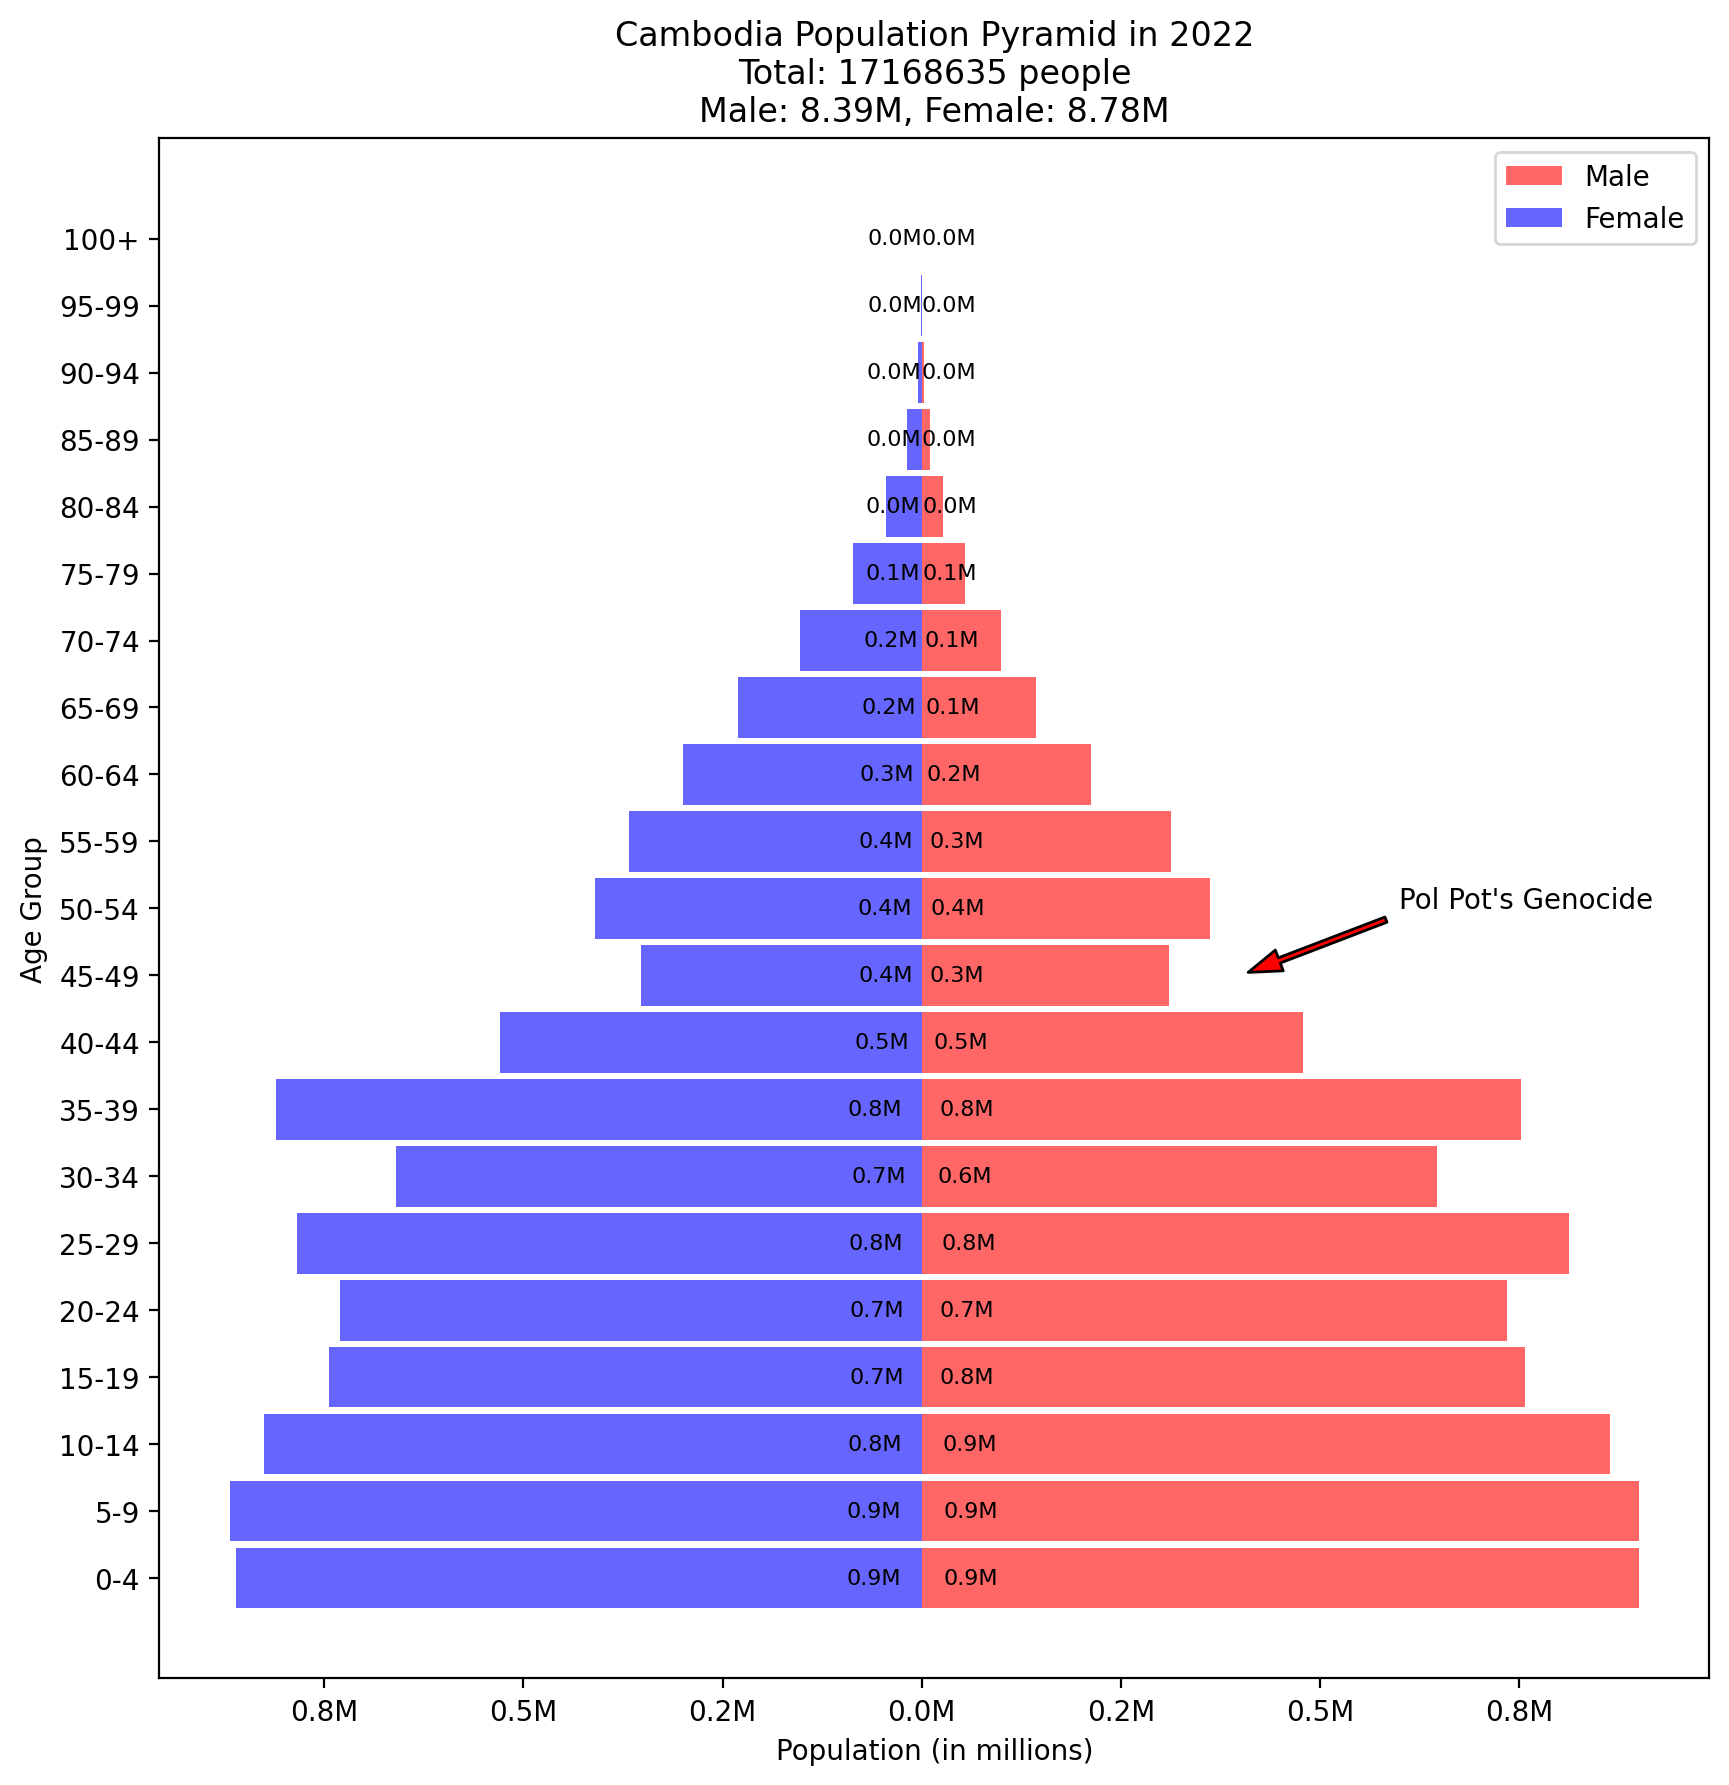

In [455]:
ax = annotationpopulationpyramid("Cambodia", 2022)

ax.annotate("Pol Pot's Genocide",
            xy=(400000, 9), 
            xytext=(600000, 10),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')

From my time in Cambodia this summer, the 'missing generation' of middle aged individuals from the genocide in the 1970s and 80s was certainly noticeable. 

### The United Arab Emirates

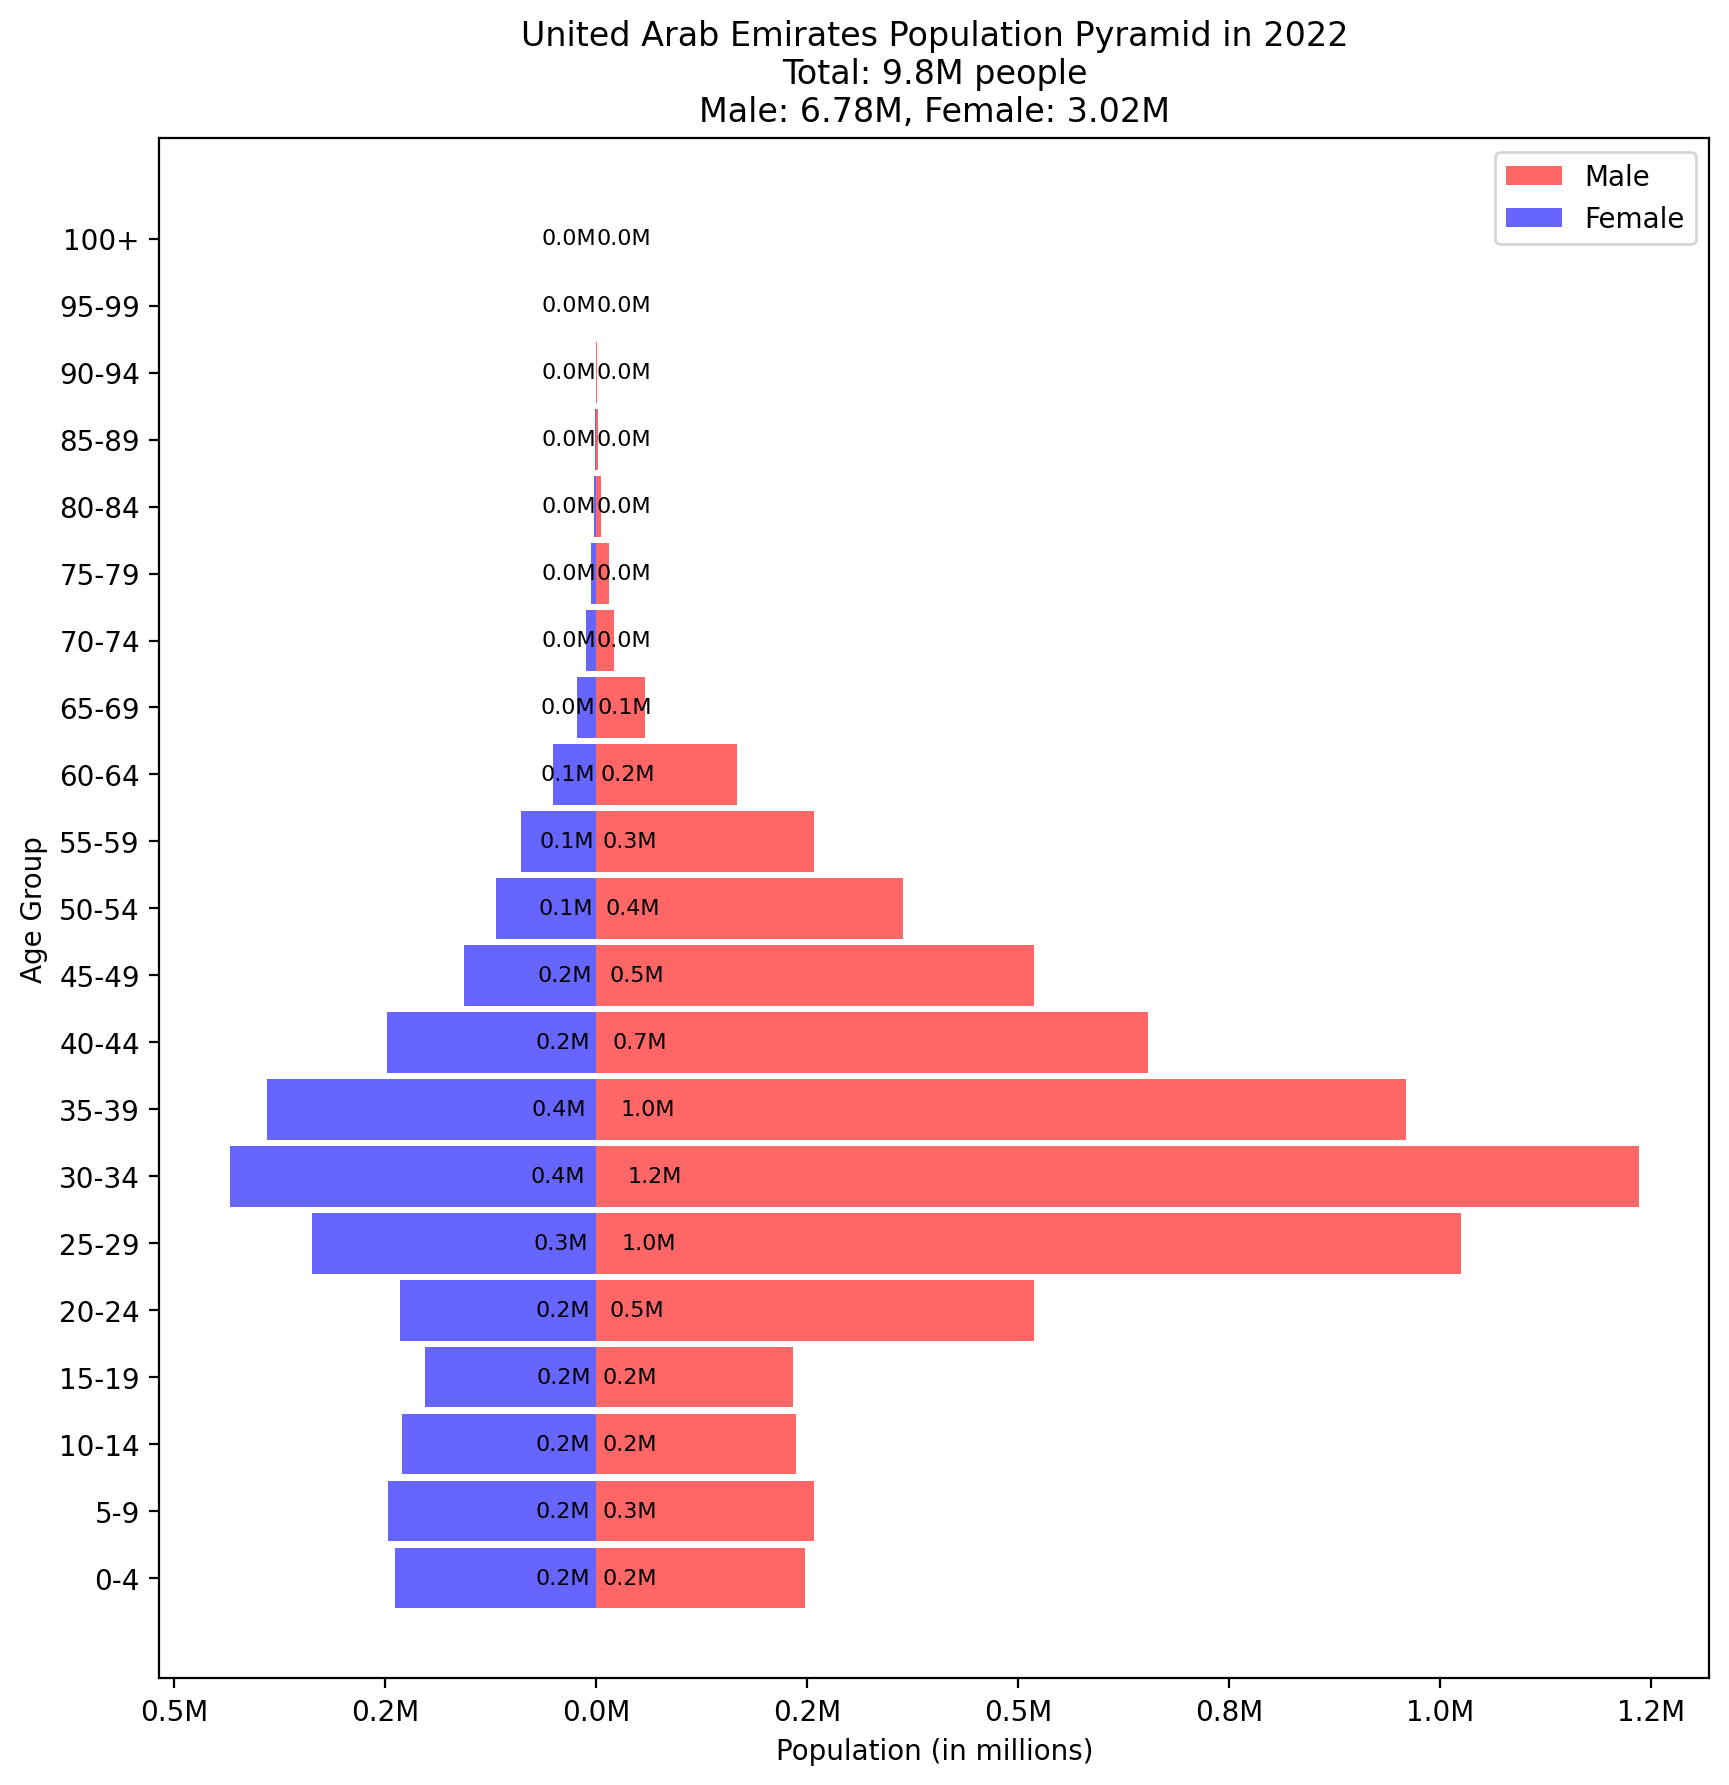

In [390]:
populationpyramid("United Arab Emirates", 2022)

A very interesting Population Pyramid. Like the other Gulf States, this sharp increase in 20-40 year old men are not Qatari born, but are migrant workers. As a result, the typical discontent with the competitive dating pool does not typically apply here, due to these migrants often having their own having families back home.

##### But why is this?

From a historical perspective, its due to a few reasons.

- The Kafari System (1960s): Essentially allows many Gulf State companies to sponsor foreign workers. Used primarily for construction, domestic work, and service industries. This exponentially increased during the UAE's economic boom in the 1990s and early 200s. 

To show the difference this system made, here is a look back in time of UAE's population pyramid in 1960, right when this program started.

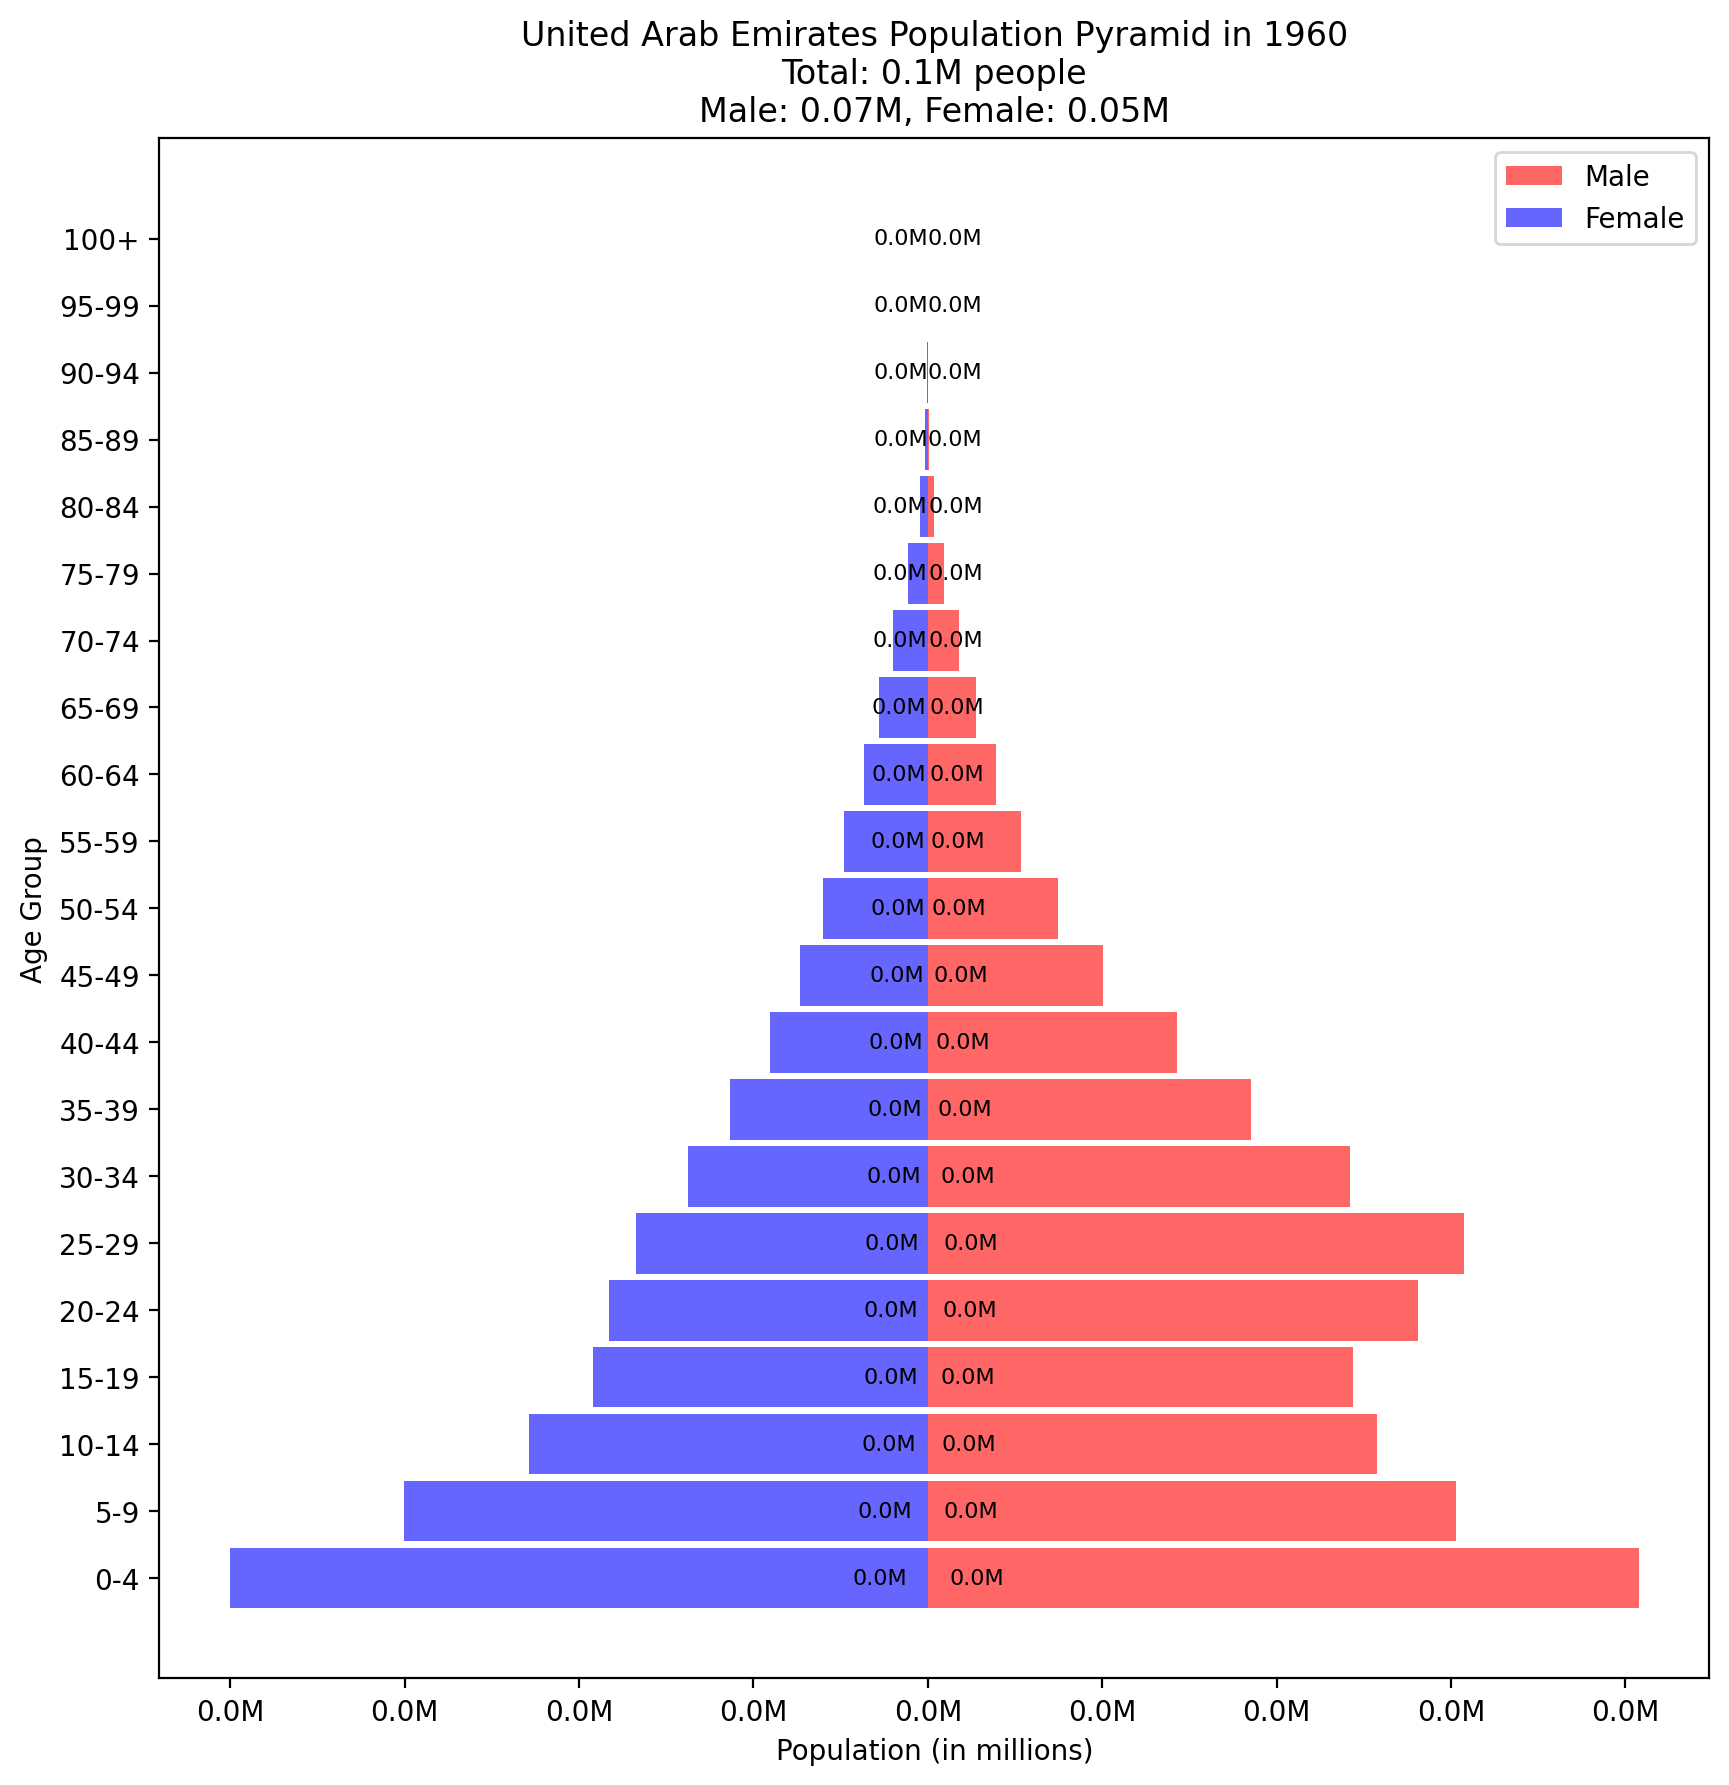

In [389]:
populationpyramid("United Arab Emirates", 1960)

#### The UAE has had the highest relative growth in the world.

We can show this with the Relative Growth Percentage formula below:

\begin{equation}
\text{Relative Growth Percentage} = \frac{   \text{New Population} - \text{Previous Population}}{\text{Previous Population}} \times 100
\end{equation}

In [391]:
grouped_data = data.groupby(['Country', 'Year'])['Total_Population'].sum().reset_index()

data_1950 = grouped_data[grouped_data['Year'] == 1950]
data_2022 = grouped_data[grouped_data['Year'] == 2022]
mergeddata = pd.merge(data_1950, data_2022, on='Country', suffixes=('_1950', '_2022'))

#Using the formula above to calculate
mergeddata['Relative_Growth'] = ((mergeddata['Total_Population_2022'] - mergeddata['Total_Population_1950']) / mergeddata['Total_Population_1950']) * 100
maxgrowthcountry = mergeddata.loc[mergeddata['Relative_Growth'].idxmax()]

maxgrowthcountry[['Country', 'Relative_Growth']]

Country            United Arab Emirates
Relative_Growth            14386.775969
Name: 218, dtype: object

The United Arab Emirates has had their population grow by a staggering 14,387% in the last 72 years.

In [392]:
UAE = maxgrowthcountry['Country']
UAE1950 = mergeddata[mergeddata['Country'] == UAE]['Total_Population_1950'].values[0]
UAE2022 = mergeddata[mergeddata['Country'] == UAE]['Total_Population_2022'].values[0]
difference = UAE2022 - UAE1950

print(f"Population of {UAE} in 1950: {UAE1950}")
print(f"Population of {UAE} in 2022: {UAE2022}")
print(f"Difference: {difference}")

Population of United Arab Emirates in 1950: 69593
Population of United Arab Emirates in 2022: 10081782
Difference: 10012189


This increase of 14,386% is equivalent to 10 million individuals, the majority of whom are migrant workers.

#### Graphing UAE's Population over time:

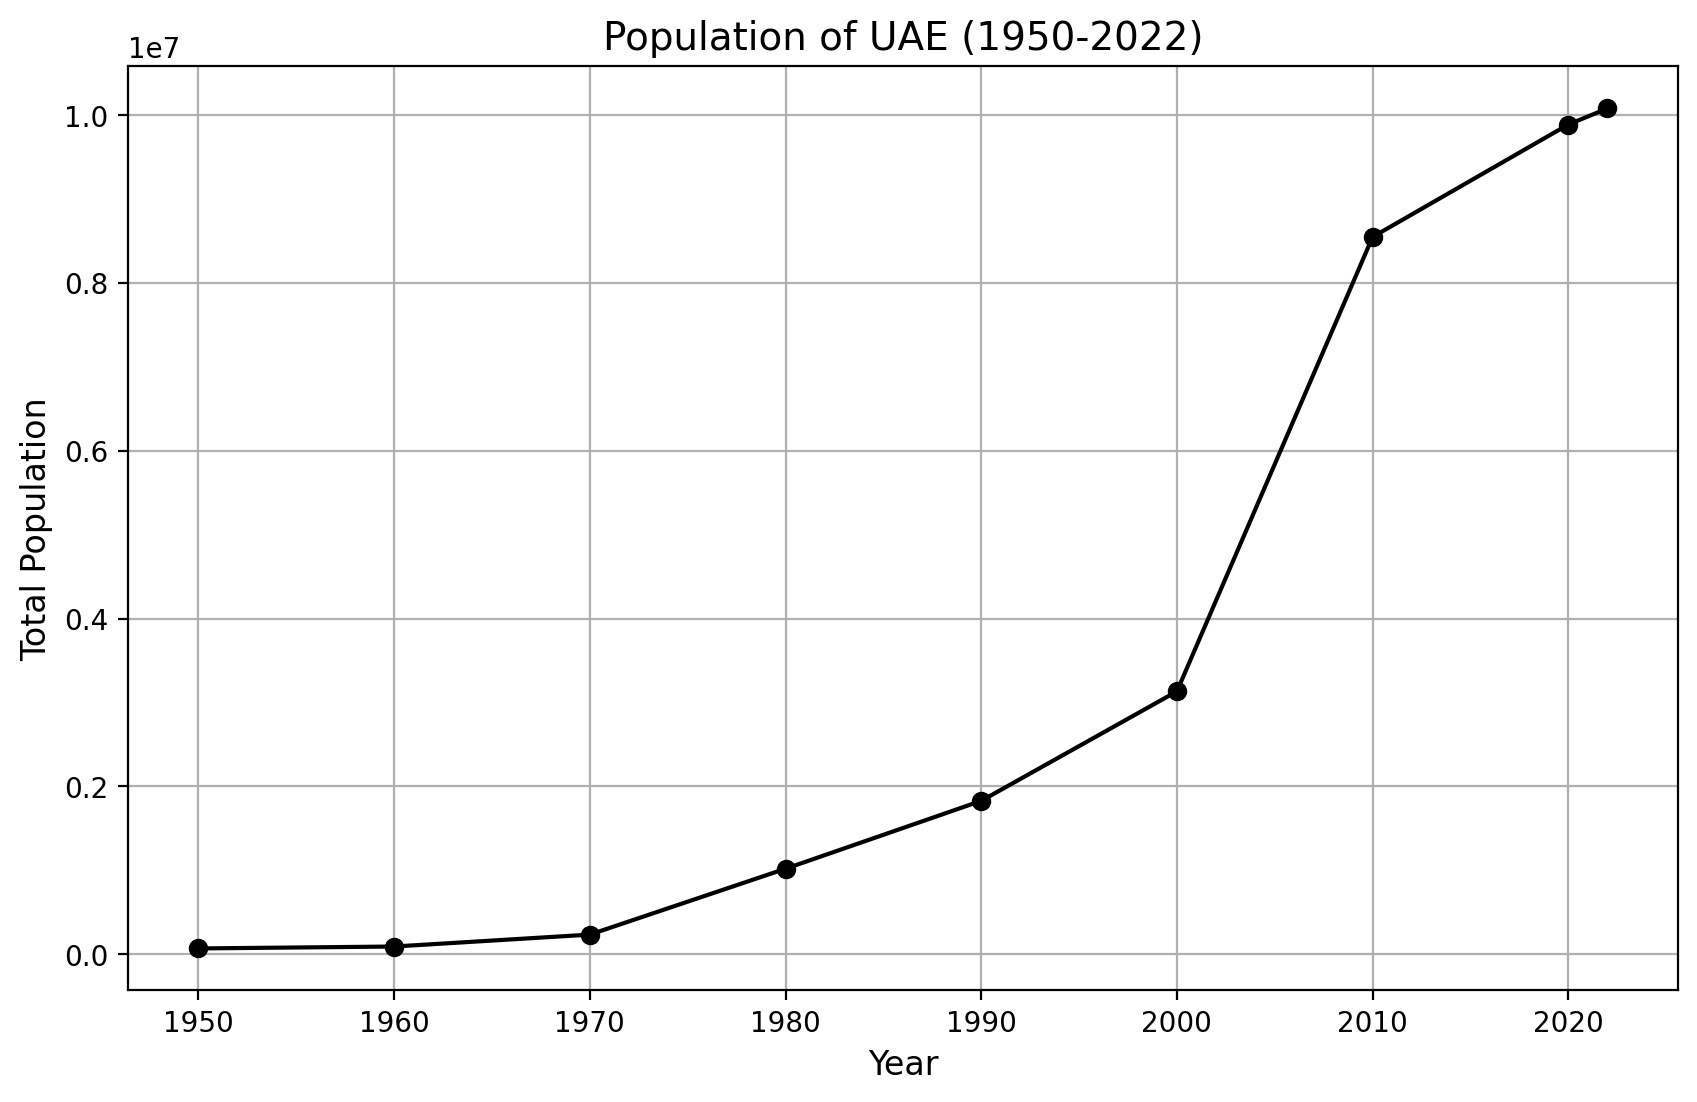

In [393]:
uae_data = grouped_data[grouped_data['Country'] == 'United Arab Emirates']
plt.figure(figsize=(10, 6))
plt.plot(uae_data['Year'], uae_data['Total_Population'], marker='o', linestyle='-', color='black')

plt.title("Population of UAE (1950-2022)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Population", fontsize=12)
plt.grid(True)

There's a sharp increase in population during the Gulf State Economic boom in the early 200s. Let's take a deeper look into how much it increased.

In [394]:
uae_data = grouped_data[grouped_data['Country'] == 'United Arab Emirates']

# Get the population for 2000 and 2010
pop_2000 = uae_data[uae_data['Year'] == 2000]['Total_Population'].values[0]
pop_2010 = uae_data[uae_data['Year'] == 2010]['Total_Population'].values[0]

# Calculate percentage growth
percentage_growth = ((pop_2010 - pop_2000) / pop_2000) * 100

# Output the result
print(f"Percentage growth in UAE's population from 2000 to 2010: {percentage_growth:.2f}%")

Percentage growth in UAE's population from 2000 to 2010: 172.81%


UAE's population in that short time-frame nearly tripled.

### Other Gulf States:

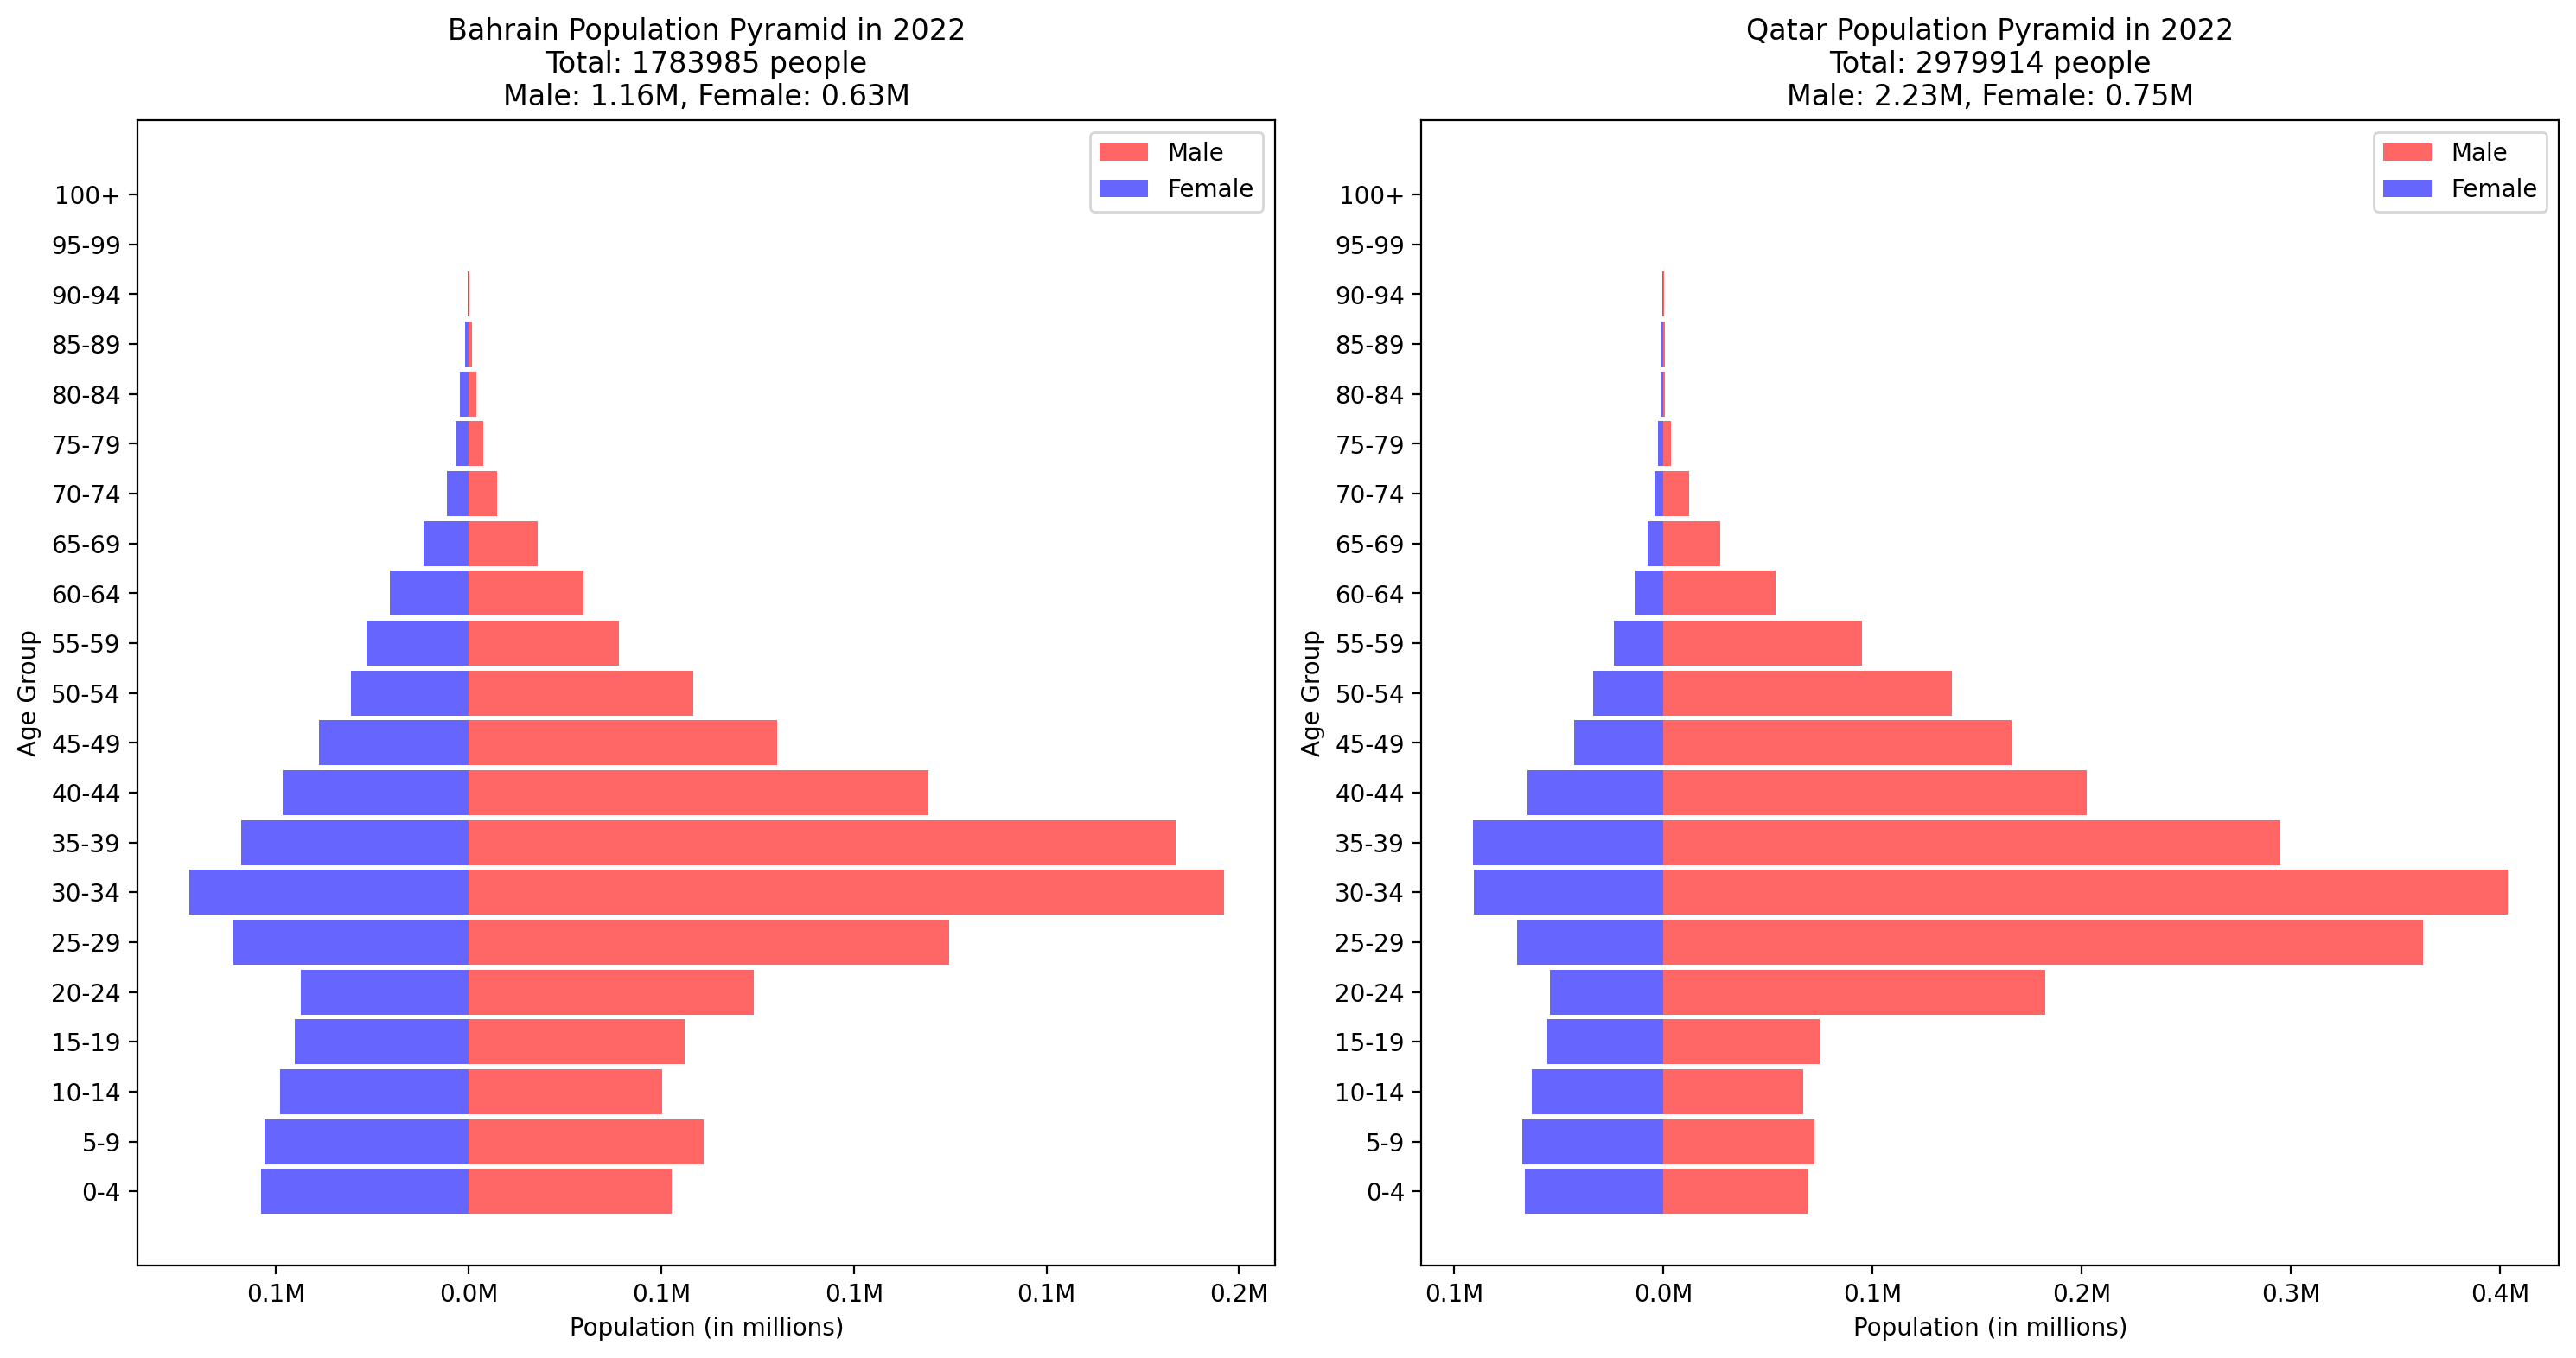

In [410]:
def smallpopulationpyramid(country="Thailand", year=2022, ax=None):  #want some smaller ones so this now accepts an ax parameter
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    populationdata = filter(country, year)
    agegroups = populationdata["Age"].values
    malepopulation = populationdata["M"].values
    femalepopulation = populationdata["F"].values

    totalmale = malepopulation.sum()
    totalfemale = femalepopulation.sum()
    totalpopulation = totalmale + totalfemale
    y_positions = np.arange(len(agegroups))
    ax.xaxis.set_major_formatter(FuncFormatter(formatmillions))
    ax.barh(y_positions, malepopulation, color="red", label="Male", alpha=0.6, height=0.9)
    ax.barh(y_positions, -femalepopulation, color="blue", label="Female", alpha=0.6, height=0.9)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(agegroups)
    ax.set_xlabel("Population (in millions)")
    ax.set_ylabel("Age Group")
    ax.set_title(f"{country} Population Pyramid in {year}\nTotal: {totalpopulation} people\n"
                 f"Male: {totalmale / 1e6:.2f}M, Female: {totalfemale / 1e6:.2f}M")

    ax.legend(loc="upper right")

# subplots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))  # 1 row, 2 columns

smallpopulationpyramid("Bahrain", 2022, ax1)
smallpopulationpyramid("Qatar", 2022, ax2)
plt.tight_layout()



As you can see, these nations have similar Population Pyramids to the UAE. Qatar's is even more extreme, likely due to the increase in workers required for the 2022 Qatar-hosted World Cup.

## 4. Worldwide Population Comparisons and Insights

### Insights on the Youth Population:

#### The Country with the Highest Proportion of Children (0-10):

In [356]:
data2022 = data[data['Year'] == 2022].copy()
agegroups0to10 = data2022[data2022['Age'].isin(['0-4', '5-9'])].copy()

#here, I'm summing the population in the 0-10 age range (both Male (M) and Female (F)) for each country
agegroups0to10.loc[:, 'Total_0_10'] = agegroups0to10['M'] + agegroups0to10['F']
population0to10bycountry = agegroups0to10.groupby('Country')['Total_0_10'].sum()
data2022.loc[:, 'Total_Population'] = data2022['M'] + data2022['F']
totalpopulationbycountry = data2022.groupby('Country')['Total_Population'].sum()
percentageyouth = (population0to10bycountry / totalpopulationbycountry) * 100

#finding the country w/ highest youth relative to overall population
highestyouthpercentage = percentageyouth.idxmax()
maxpercentageyouth = percentageyouth.max()

print(f"Country with highest percentage of children population in 0-10 age range (2022): {highestyouthpercentage}")
print(f"Percentage: {maxpercentageyouth:.2f}%")


Country with highest percentage of children population in 0-10 age range (2022): Niger
Percentage: 35.86%


Niger takes the award for proportionally having the most children.

#### Niger's Population Pyramid:

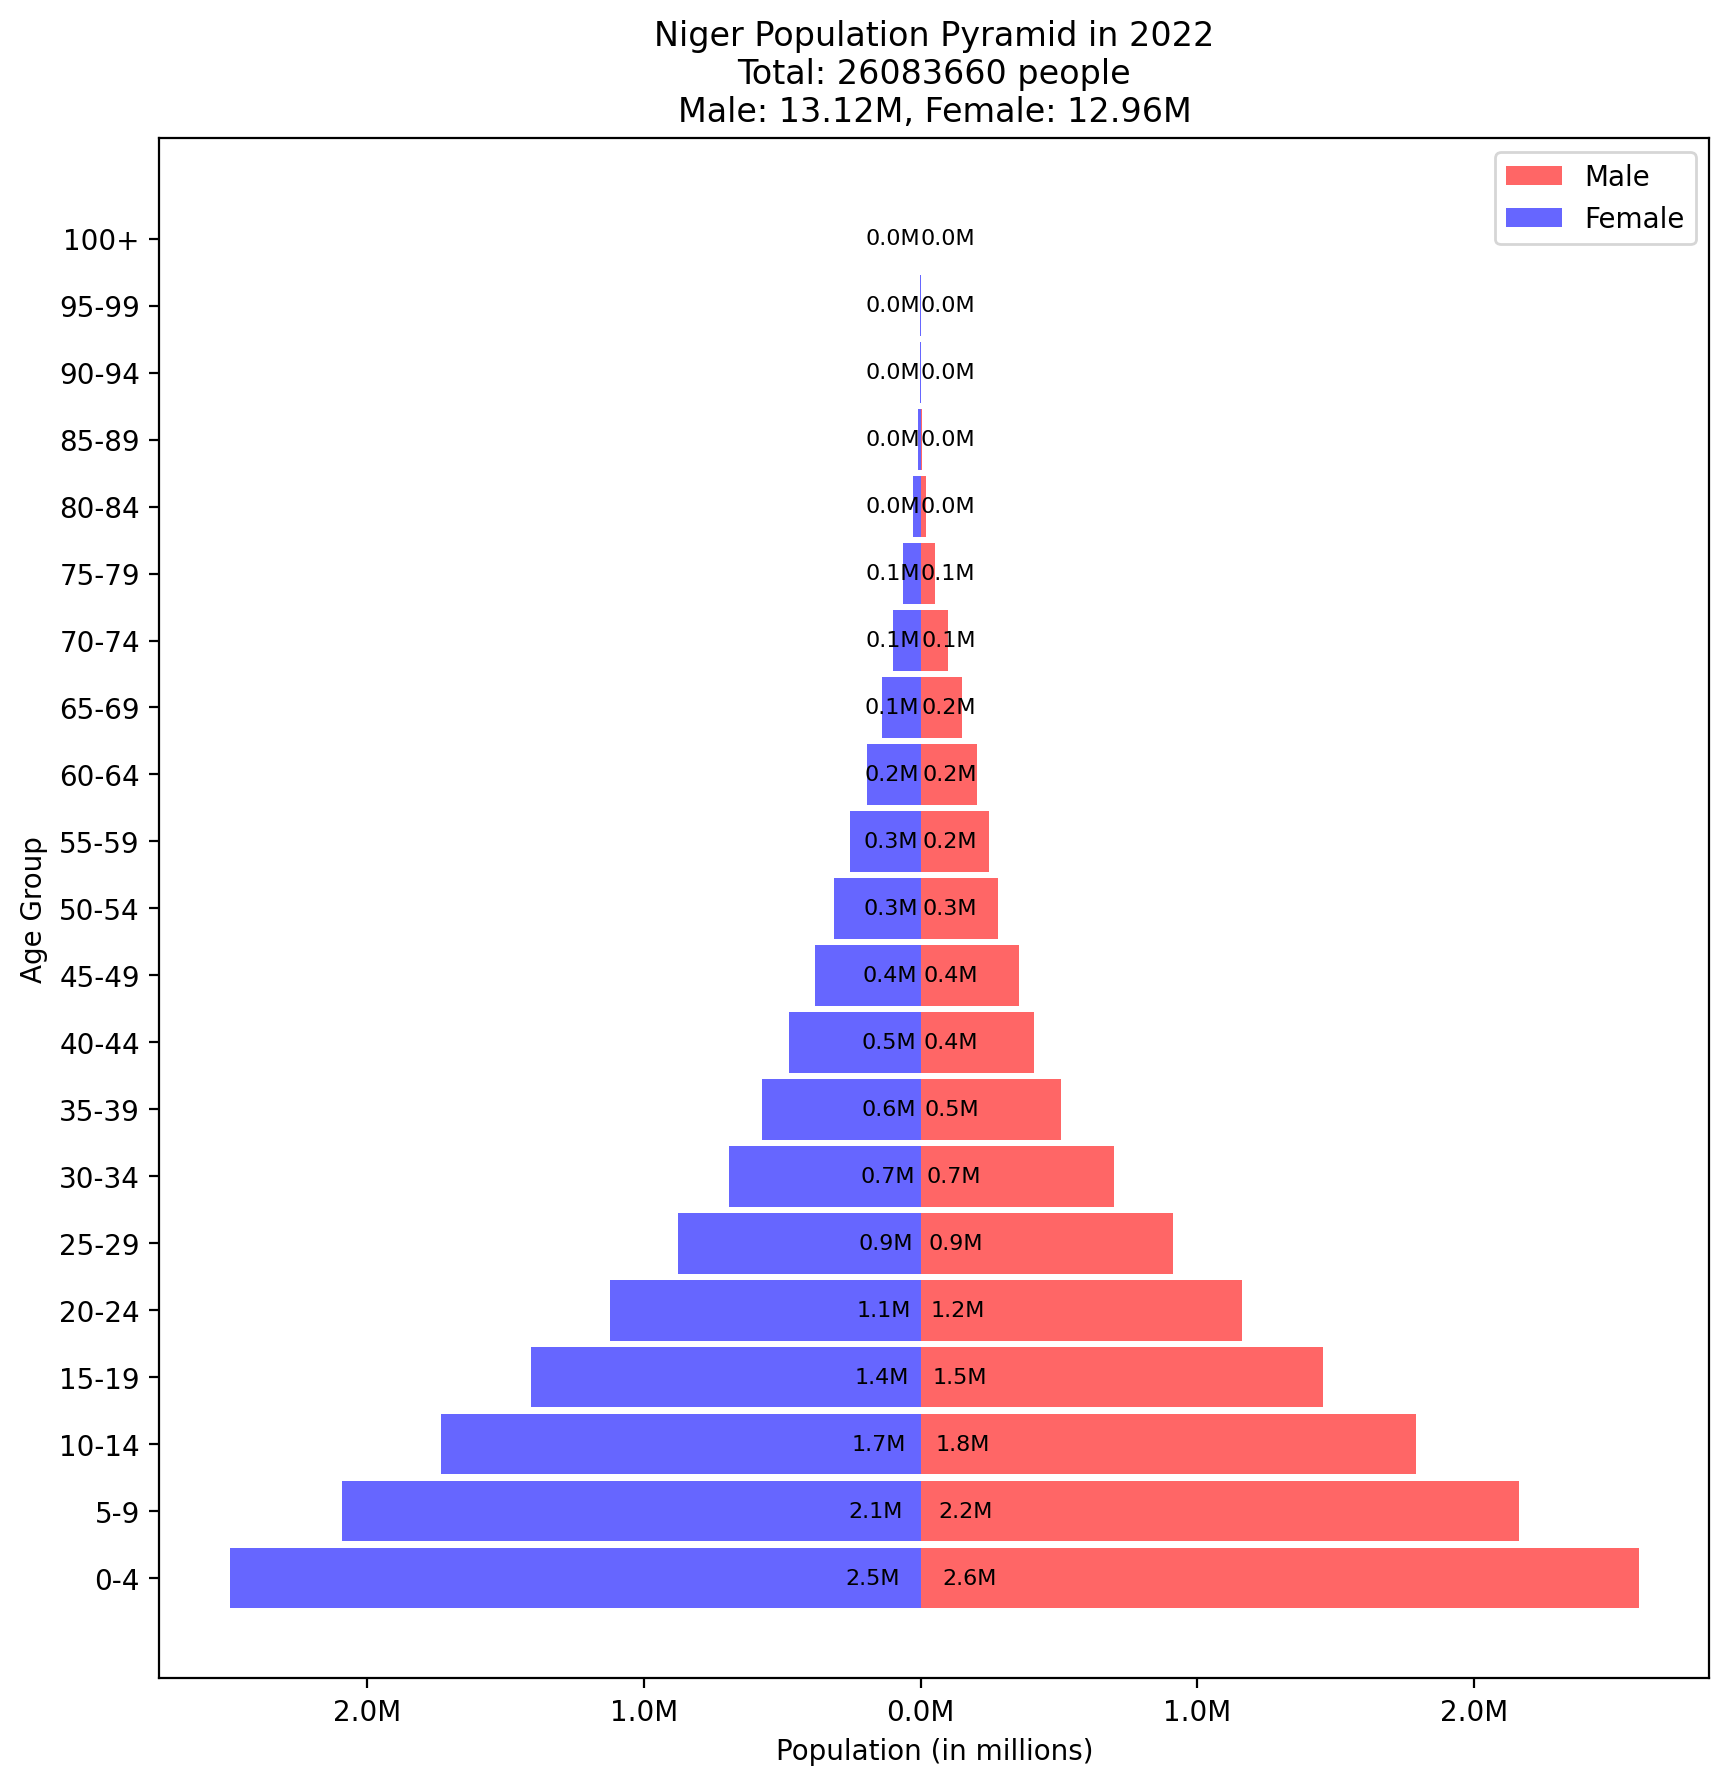

In [344]:
populationpyramid("Niger", 2022)

#### Top 10 Countries with the Highest Proportion of Youth (0-18):

A country with a young population can benefit in several ways:

- Young people represent the future workforce, which can lead to economic growth as they enter jobs, innovate, and drive productivity. 

- A larger young population also means a greater pool of talent and creativity. 

- Additionally, as the population ages, the younger generation can support the elderly through taxes helping maintain the country’s social and economic stability. 

However, it’s important that there are enough resources, such as education and healthcare, to support their development.

In [345]:
#Including the teenagers this time, from ages 10-19, (with 19 being the cuttoff, 18 year olds are the max age incorporated in this analysis)
data2022 = data[data['Year'] == 2022].copy()
agegroups0to18 = data2022[data2022['Age'].isin(['0-4', '5-9', '10-14', '15-19'])].copy()
agegroups0to18.loc[:, 'Total_0_18'] = agegroups0to18['M'] + agegroups0to18['F']
population0to18bycountry = agegroups0to18.groupby('Country')['Total_0_18'].sum()
data2022.loc[:, 'Total_Population'] = data2022['M'] + data2022['F']
totalpopulationbycountry = data2022.groupby('Country')['Total_Population'].sum()
percentageyouth = (population0to18bycountry / totalpopulationbycountry) * 100
top10youthpercentage = percentageyouth.nlargest(10)
print("Top 10 countries with the highest percentage of population in the 0-18 age range (2022):")
print(top10youthpercentage)

Top 10 countries with the highest percentage of population in the 0-18 age range (2022):
Country
Niger                               60.371420
Mali                                57.744812
Chad                                57.246910
Somalia                             57.159639
Angola                              56.836334
Uganda                              56.610893
Democratic Republic of the Congo    56.114228
Middle Africa                       55.408864
Burundi                             55.259994
Central African Republic            54.947289
dtype: float64


### Birth Rate Heatmap:

9


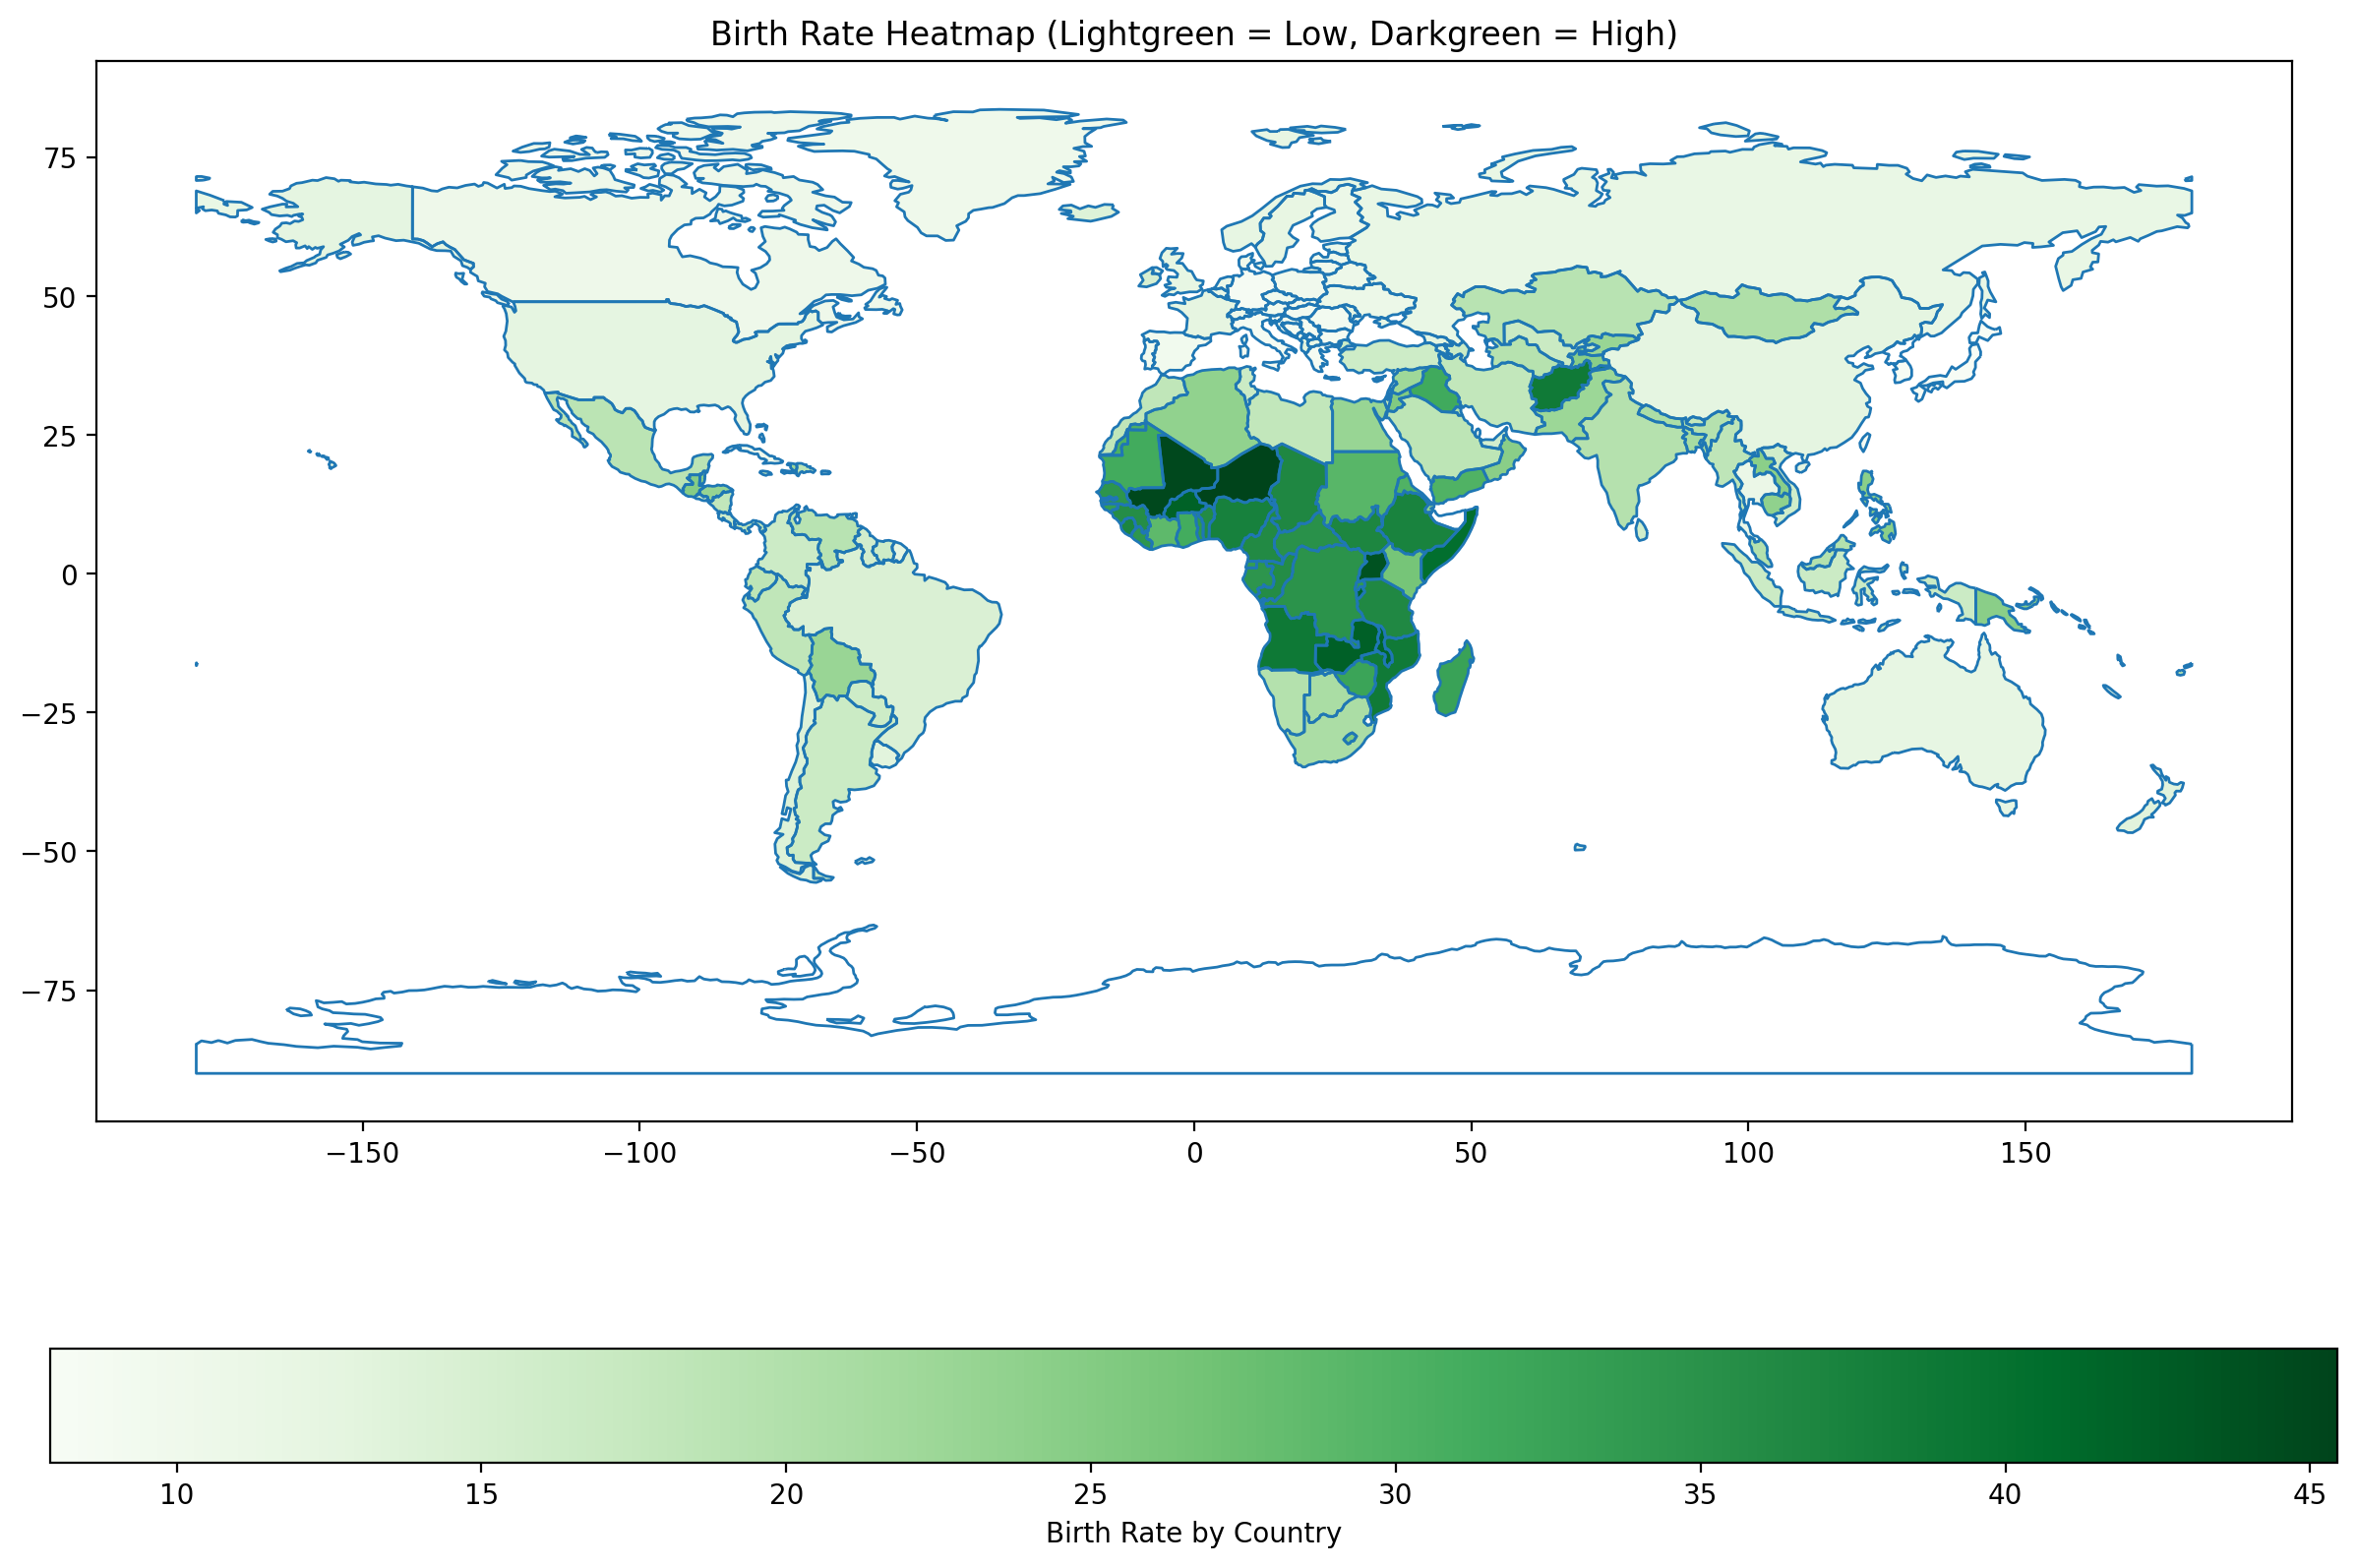

In [495]:
world = gpd.read_file('110m_cultural/ne_110m_admin_0_countries.shp')
df_filtered = df[(df['corrected_name'] != 'European Union') & (~df['corrected_name'].str.contains('Ocean'))]
merged = world.merge(df_filtered, left_on='SOVEREIGNT', right_on='corrected_name', how='left')
print(merged['birth_rate'].isnull().sum())
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.boundary.plot(ax=ax, linewidth=1)
merged.plot(column='birth_rate', cmap='Greens', legend=True, ax=ax,
            legend_kwds={'label': "Birth Rate by Country",
                         'orientation': "horizontal"})
plt.title('Birth Rate Heatmap (Lightgreen = Low, Darkgreen = High)')
plt.show()

#### Top 10 Countries with the highest birth rate:

In [449]:
%%sql
SELECT name AS 'Top 10 Countries with the highest birth rate:',
       birth_rate,
       ROUND(CAST(death_rate AS FLOAT) /
             CAST((SELECT MAX(birth_rate) FROM facts) AS FLOAT), 3)
             AS world_population
FROM facts
WHERE code NOT IN ('ee', 'xx') AND population > 5000000 
ORDER BY 2 DESC
LIMIT 10;

 * sqlite:///factbook.db
Done.


Top 10 Countries with the highest birth rate:,birth_rate,world_population
Niger,45.45,0.273
Mali,44.99,0.284
Uganda,43.79,0.235
Zambia,42.13,0.279
Burkina Faso,42.03,0.258
Burundi,42.01,0.204
Malawi,41.56,0.185
Somalia,40.45,0.3
Angola,38.78,0.253
Mozambique,38.58,0.266


### Insights on the Elderly Population:

In [350]:
data2022 = data[data['Year'] == 2022].copy()
oldagegroup = data2022[data2022['Age'].isin(['50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89',
 '90-94', '95-99', '100+'])].copy()
oldagegroup.loc[:, 'Total_50_100'] = oldagegroup['M'] + oldagegroup['F']
population50to100bycountry = oldagegroup.groupby('Country')['Total_50_100'].sum()

data2022.loc[:, 'Total_Population'] = data2022['M'] + data2022['F']
totalpopulationbycountry = data2022.groupby('Country')['Total_Population'].sum()
percentageelderly = (population50to100bycountry / totalpopulationbycountry) * 100
top10 = percentageelderly.nlargest(10)

print("Top 10 aging countries with the highest percentage of elderly population in the 50-100 age range (2022):")
print(top10)

Top 10 aging countries with the highest percentage of elderly population in the 50-100 age range (2022):
Country
Japan                   48.716089
Martinique              47.092616
Italy                   46.998697
Germany                 45.136274
Portugal                45.135588
Greece                  44.514280
Southern Europe         44.219702
Lithuania               43.981449
China, Hong Kong SAR    43.164320
Slovenia                43.057656
dtype: float64


### World Death Rate Heatmap

9


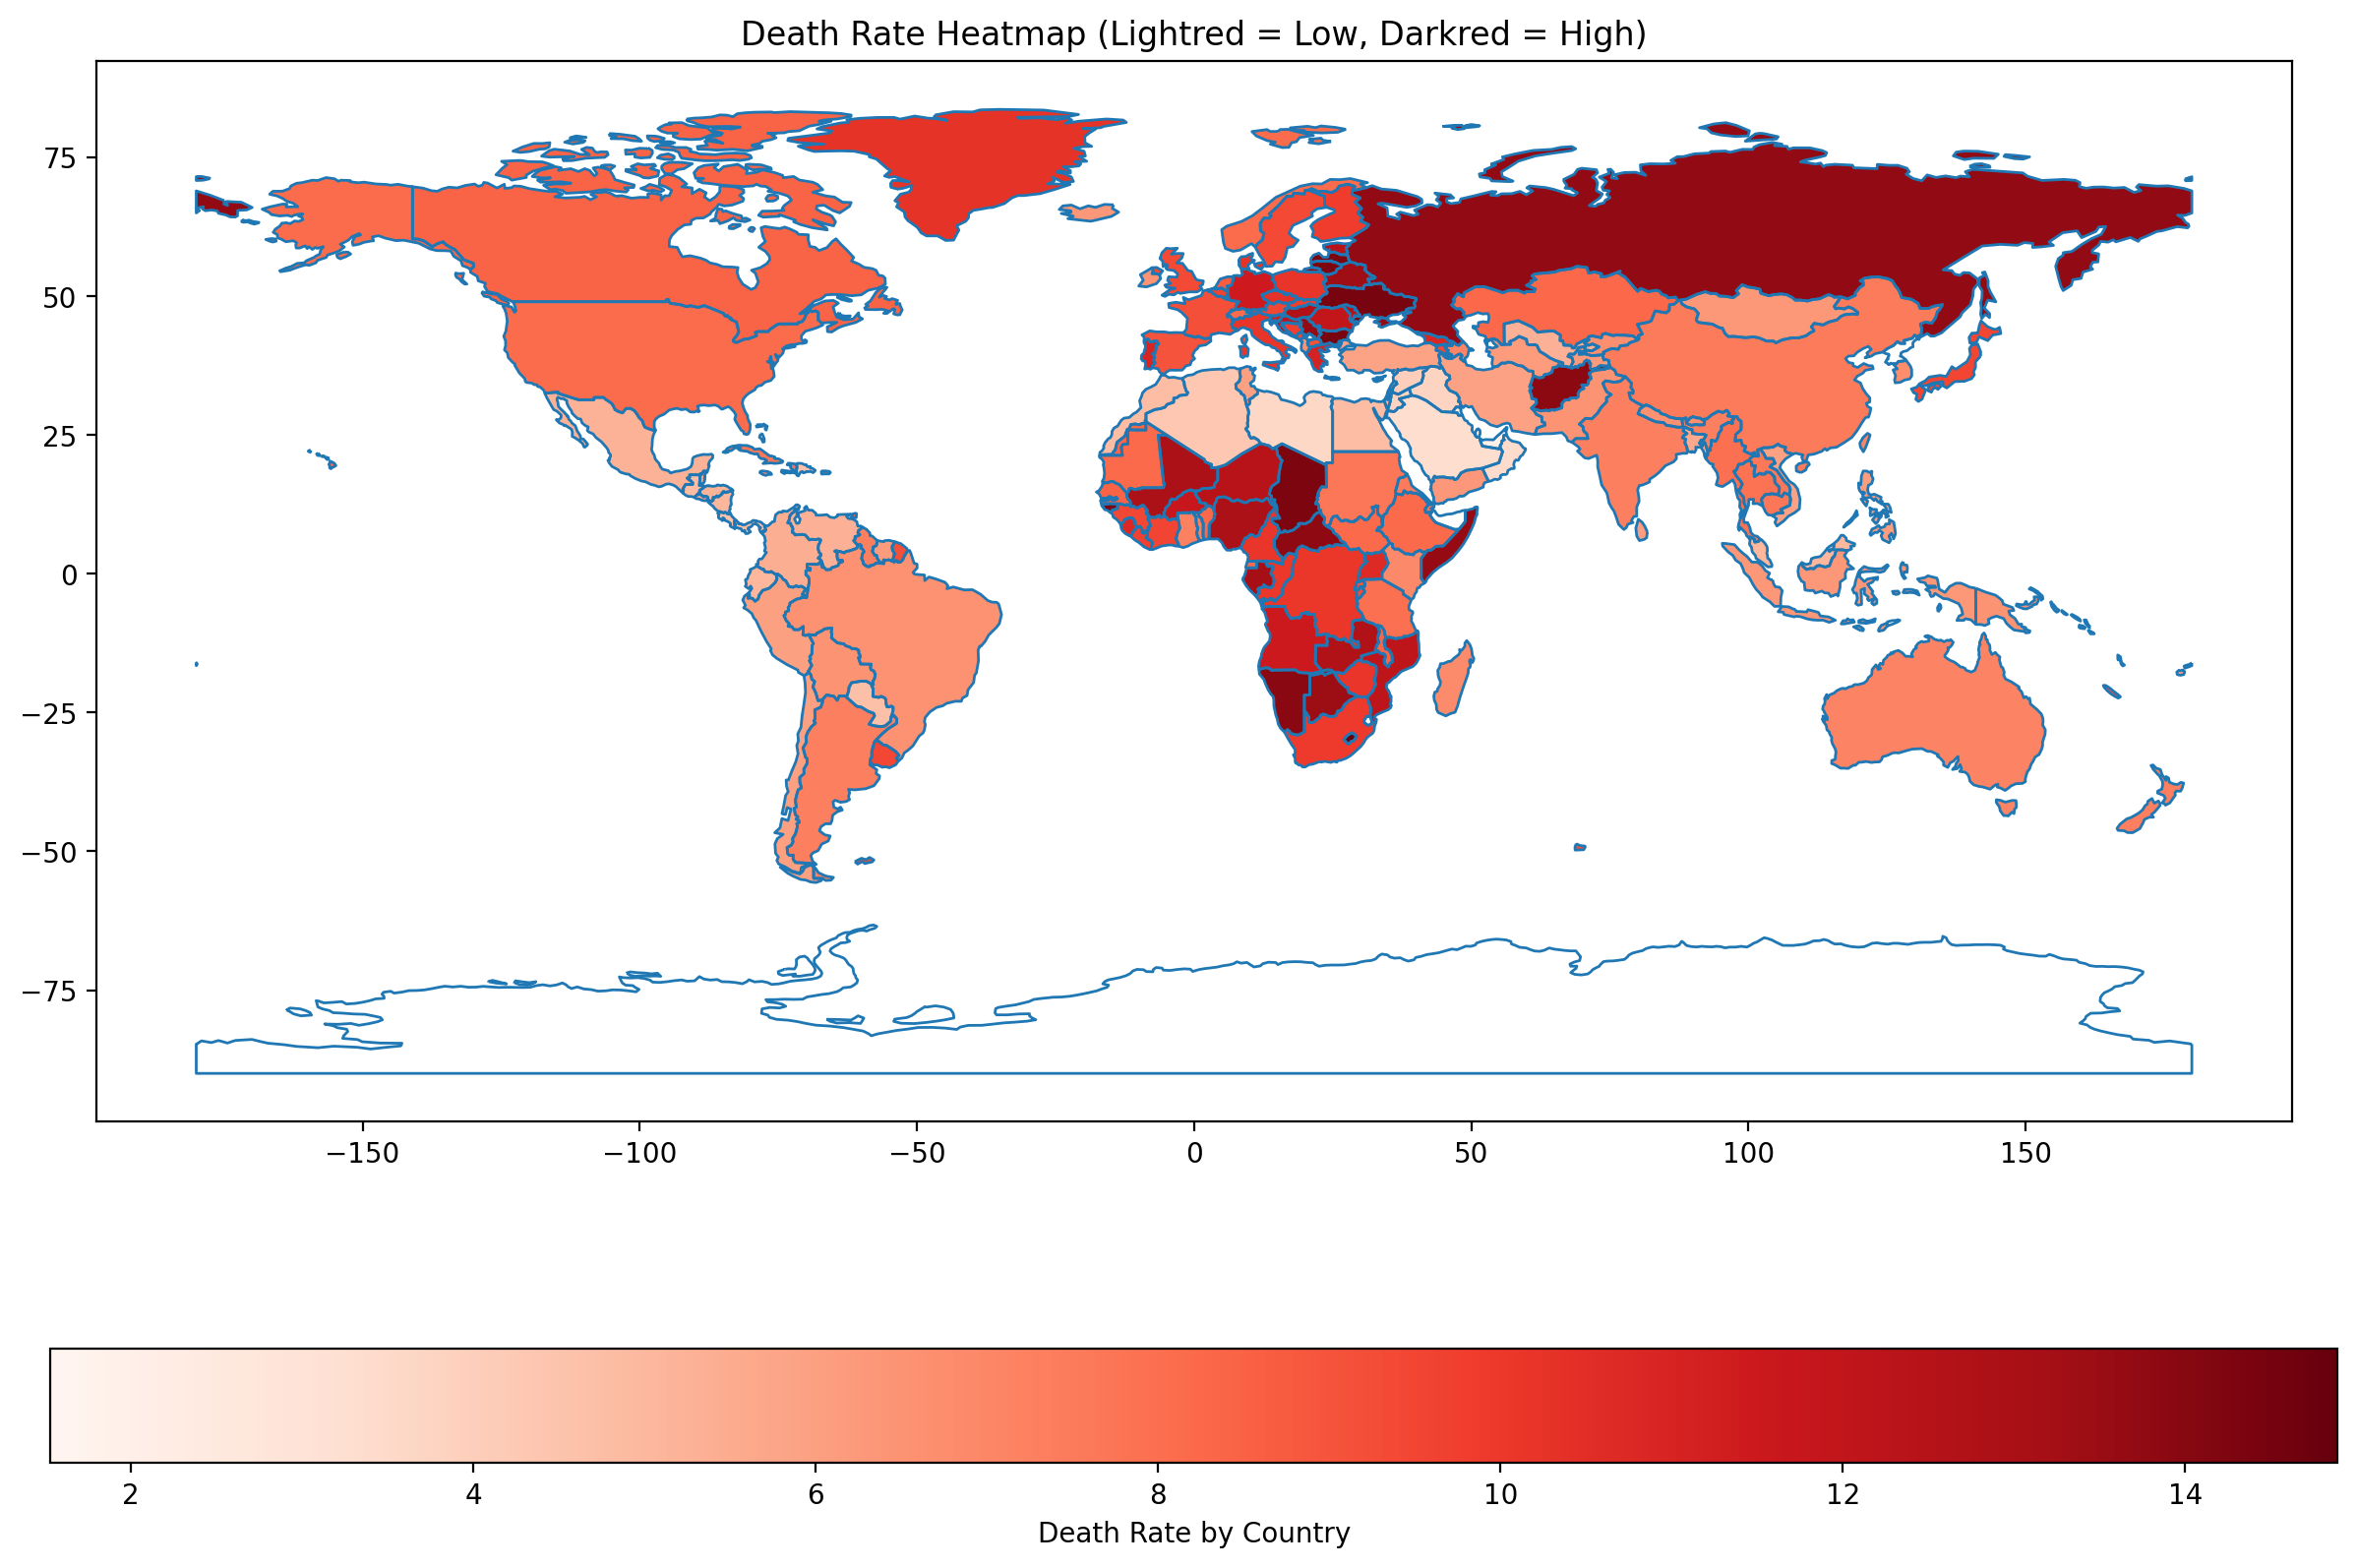

In [496]:
world = gpd.read_file('110m_cultural/ne_110m_admin_0_countries.shp')
df_filtered = df[(df['corrected_name'] != 'European Union') & (~df['corrected_name'].str.contains('Ocean'))]
merged = world.merge(df_filtered, left_on='SOVEREIGNT', right_on='corrected_name', how='left')
print(merged['death_rate'].isnull().sum())
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.boundary.plot(ax=ax, linewidth=1)
merged.plot(column='death_rate', cmap='Reds', legend=True, ax=ax,
            legend_kwds={'label': "Death Rate by Country",
                         'orientation': "horizontal"})
plt.title('Death Rate Heatmap (Lightred = Low, Darkred = High)')
plt.show()

#### Top 10 Countries with the highest Death Rate:

In [448]:
%%sql
SELECT name AS 'Top 10 Countries with the highest death rate:',
       death_rate,
       ROUND(CAST(death_rate AS FLOAT) /
             CAST((SELECT MAX(death_rate) FROM facts) AS FLOAT), 3)
             AS world_population
FROM facts
WHERE code NOT IN ('ee', 'xx') AND population > 5000000 
ORDER BY 2 DESC
LIMIT 10;

 * sqlite:///factbook.db
Done.


Top 10 Countries with the highest death rate:,death_rate,world_population
Ukraine,14.46,0.971
Bulgaria,14.44,0.97
Chad,14.28,0.959
Afghanistan,13.89,0.933
Central African Republic,13.8,0.927
Russia,13.69,0.919
Serbia,13.66,0.917
Somalia,13.62,0.915
Belarus,13.36,0.897
Nigeria,12.9,0.866


##### Plausible Explanations for these results: 

Ukraine: This dataset came out long after the start of the Ukraine war, therefore, their high death rate is rather self-explanatory. 

Bulgaria: They have the highest smoking rates for adults and adolescents in all of the EU by a wide margin. This is likely the main correlation.

Chad: Poverty, lack of healthcare, inadequate supply of nutrition. Their only water source, Lake Chad, is drying up from global warming.

Afghanistan: Endless wars and taliban control put a strain on healthcare.

Central African Republic: CAR is consistently ranked as the poorest country in the world.

Russia: Ukraine war, drinking, and smoking

### Other Population Insights:

#### Population Growth for the Most Populated Countries:

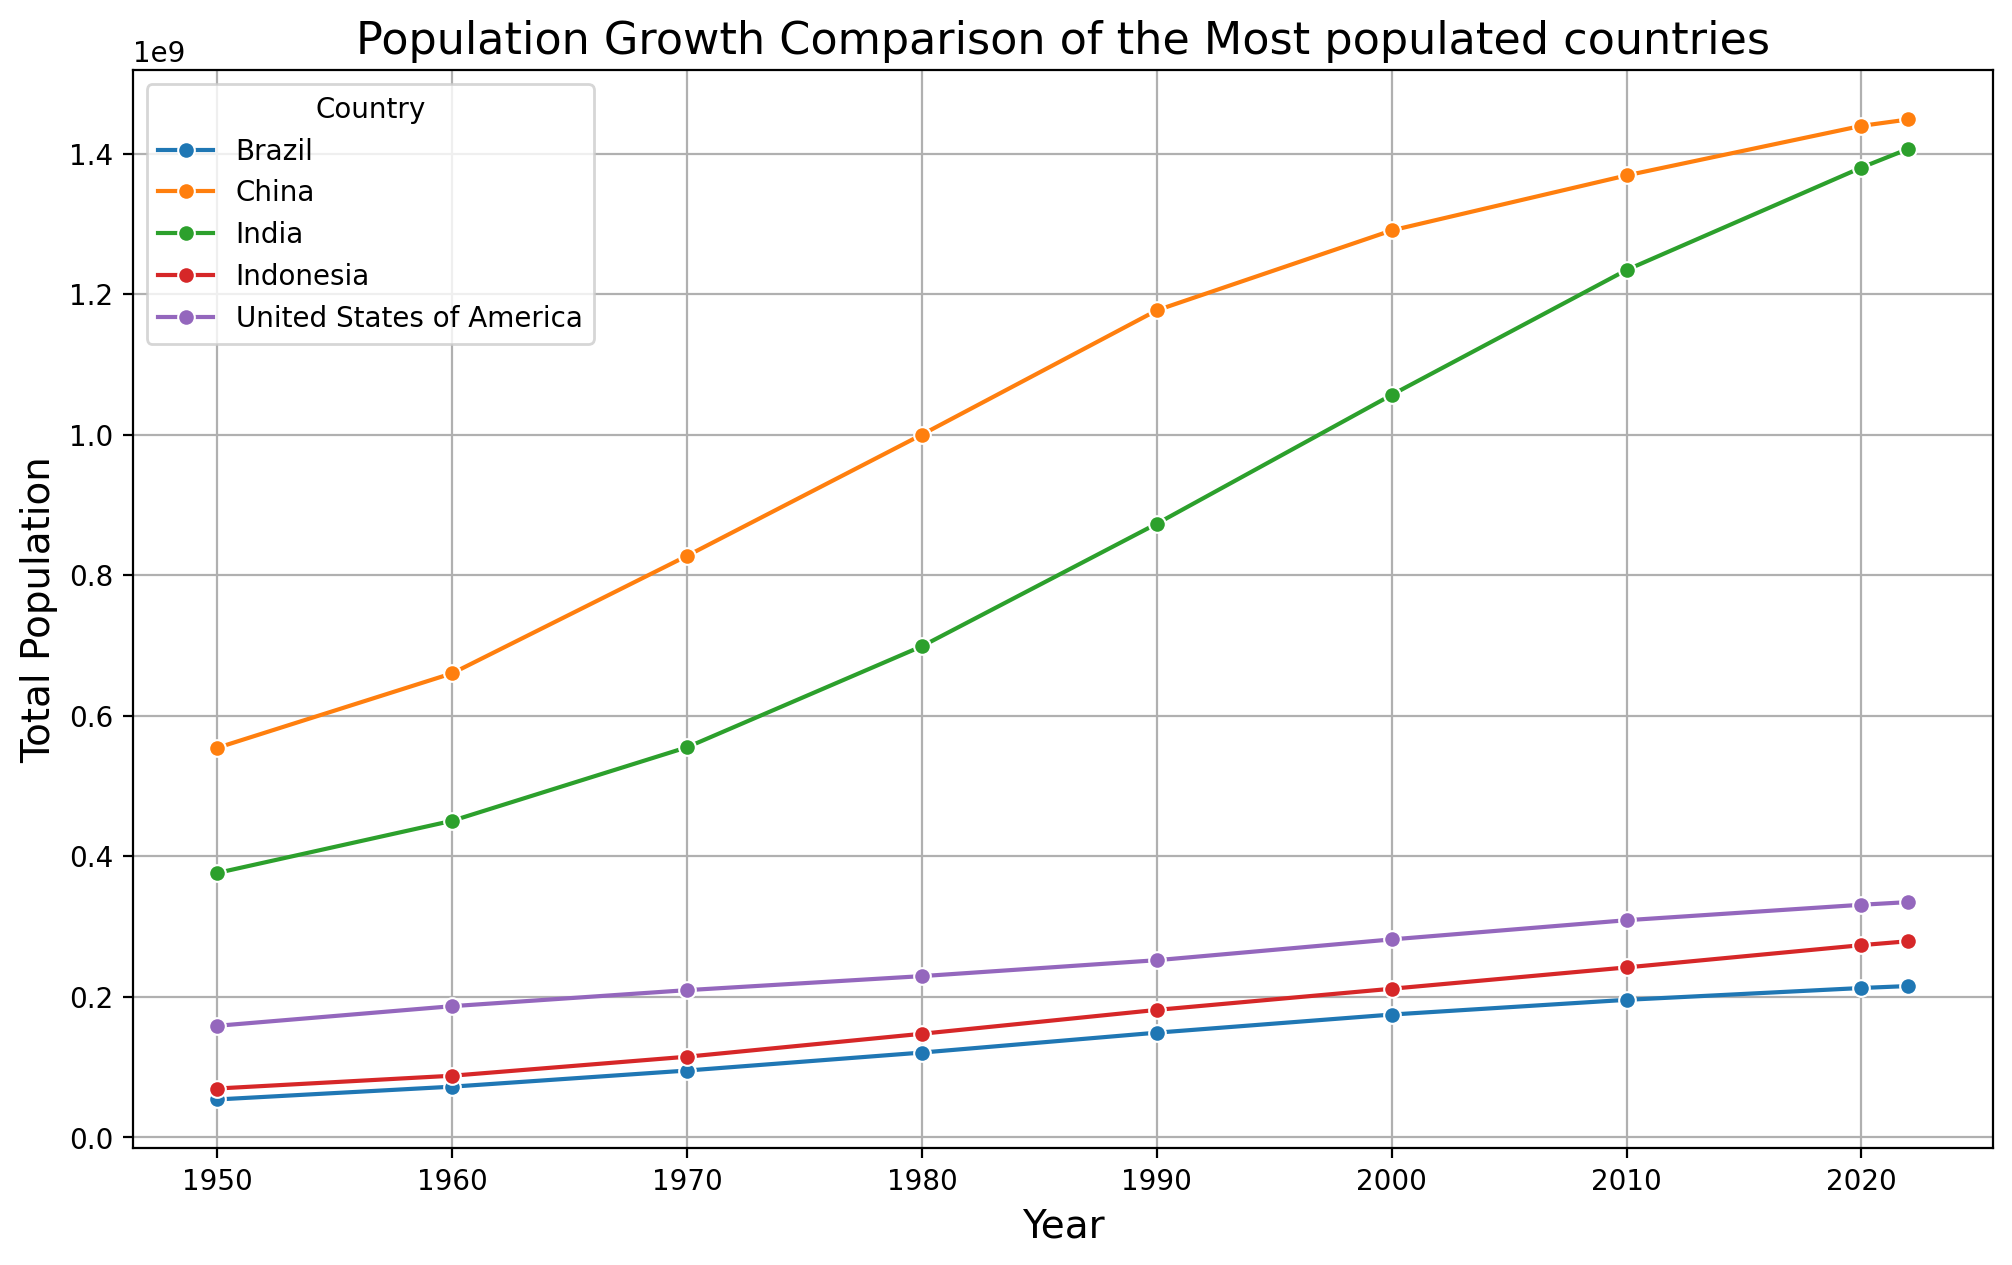

In [478]:
data['Total_Population'] = data['M'] + data['F']
population_growth_by_country = data.groupby(['Country', 'Year'])['Total_Population'].sum().reset_index()
countries = ['China', 'India', 'United States of America', 'Indonesia', 'Brazil']
population_comparison = population_growth_by_country[population_growth_by_country['Country'].isin(countries)]
plt.figure(figsize=(12,7))
sns.lineplot(data=population_comparison, x='Year', y='Total_Population', hue='Country', marker='o')


plt.title('Population Growth Comparison of the Most populated countries', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Population', fontsize=14)
plt.grid(True)

#### Which Country Decreased Their Population the Most Since 1950?

Can use the relative growth formula previously used for the UAE.

In [363]:
mingrowthcountry = mergeddata.loc[mergeddata['Relative_Growth'].idxmin()]
mingrowthcountry[['Country', 'Relative_Growth']]

Country            Bulgaria
Relative_Growth   -5.604816
Name: 28, dtype: object

##### Bulgaria

Bulgaria has lost 5.6% of its overall population since 1950.

Degree of loss:

In [364]:
Bulgaria = mingrowthcountry['Country']

Bulgaria1950 = mergeddata[mergeddata['Country'] == Bulgaria]['Total_Population_1950'].values[0]
Bulgaria2022 = mergeddata[mergeddata['Country'] == Bulgaria]['Total_Population_2022'].values[0]
difference2 = Bulgaria1950 - Bulgaria2022

print(f"Population of {Bulgaria} in 1950: {Bulgaria1950}")
print(f"Population of {Bulgaria} in 2022: {Bulgaria2022}")
print(f"Difference: {difference2}")

Population of Bulgaria in 1950: 7250996
Population of Bulgaria in 2022: 6844591
Difference: 406405


This aforementioned 5.6% accounts for 406405 individuals.

### Bulgaria's Population Pyramid

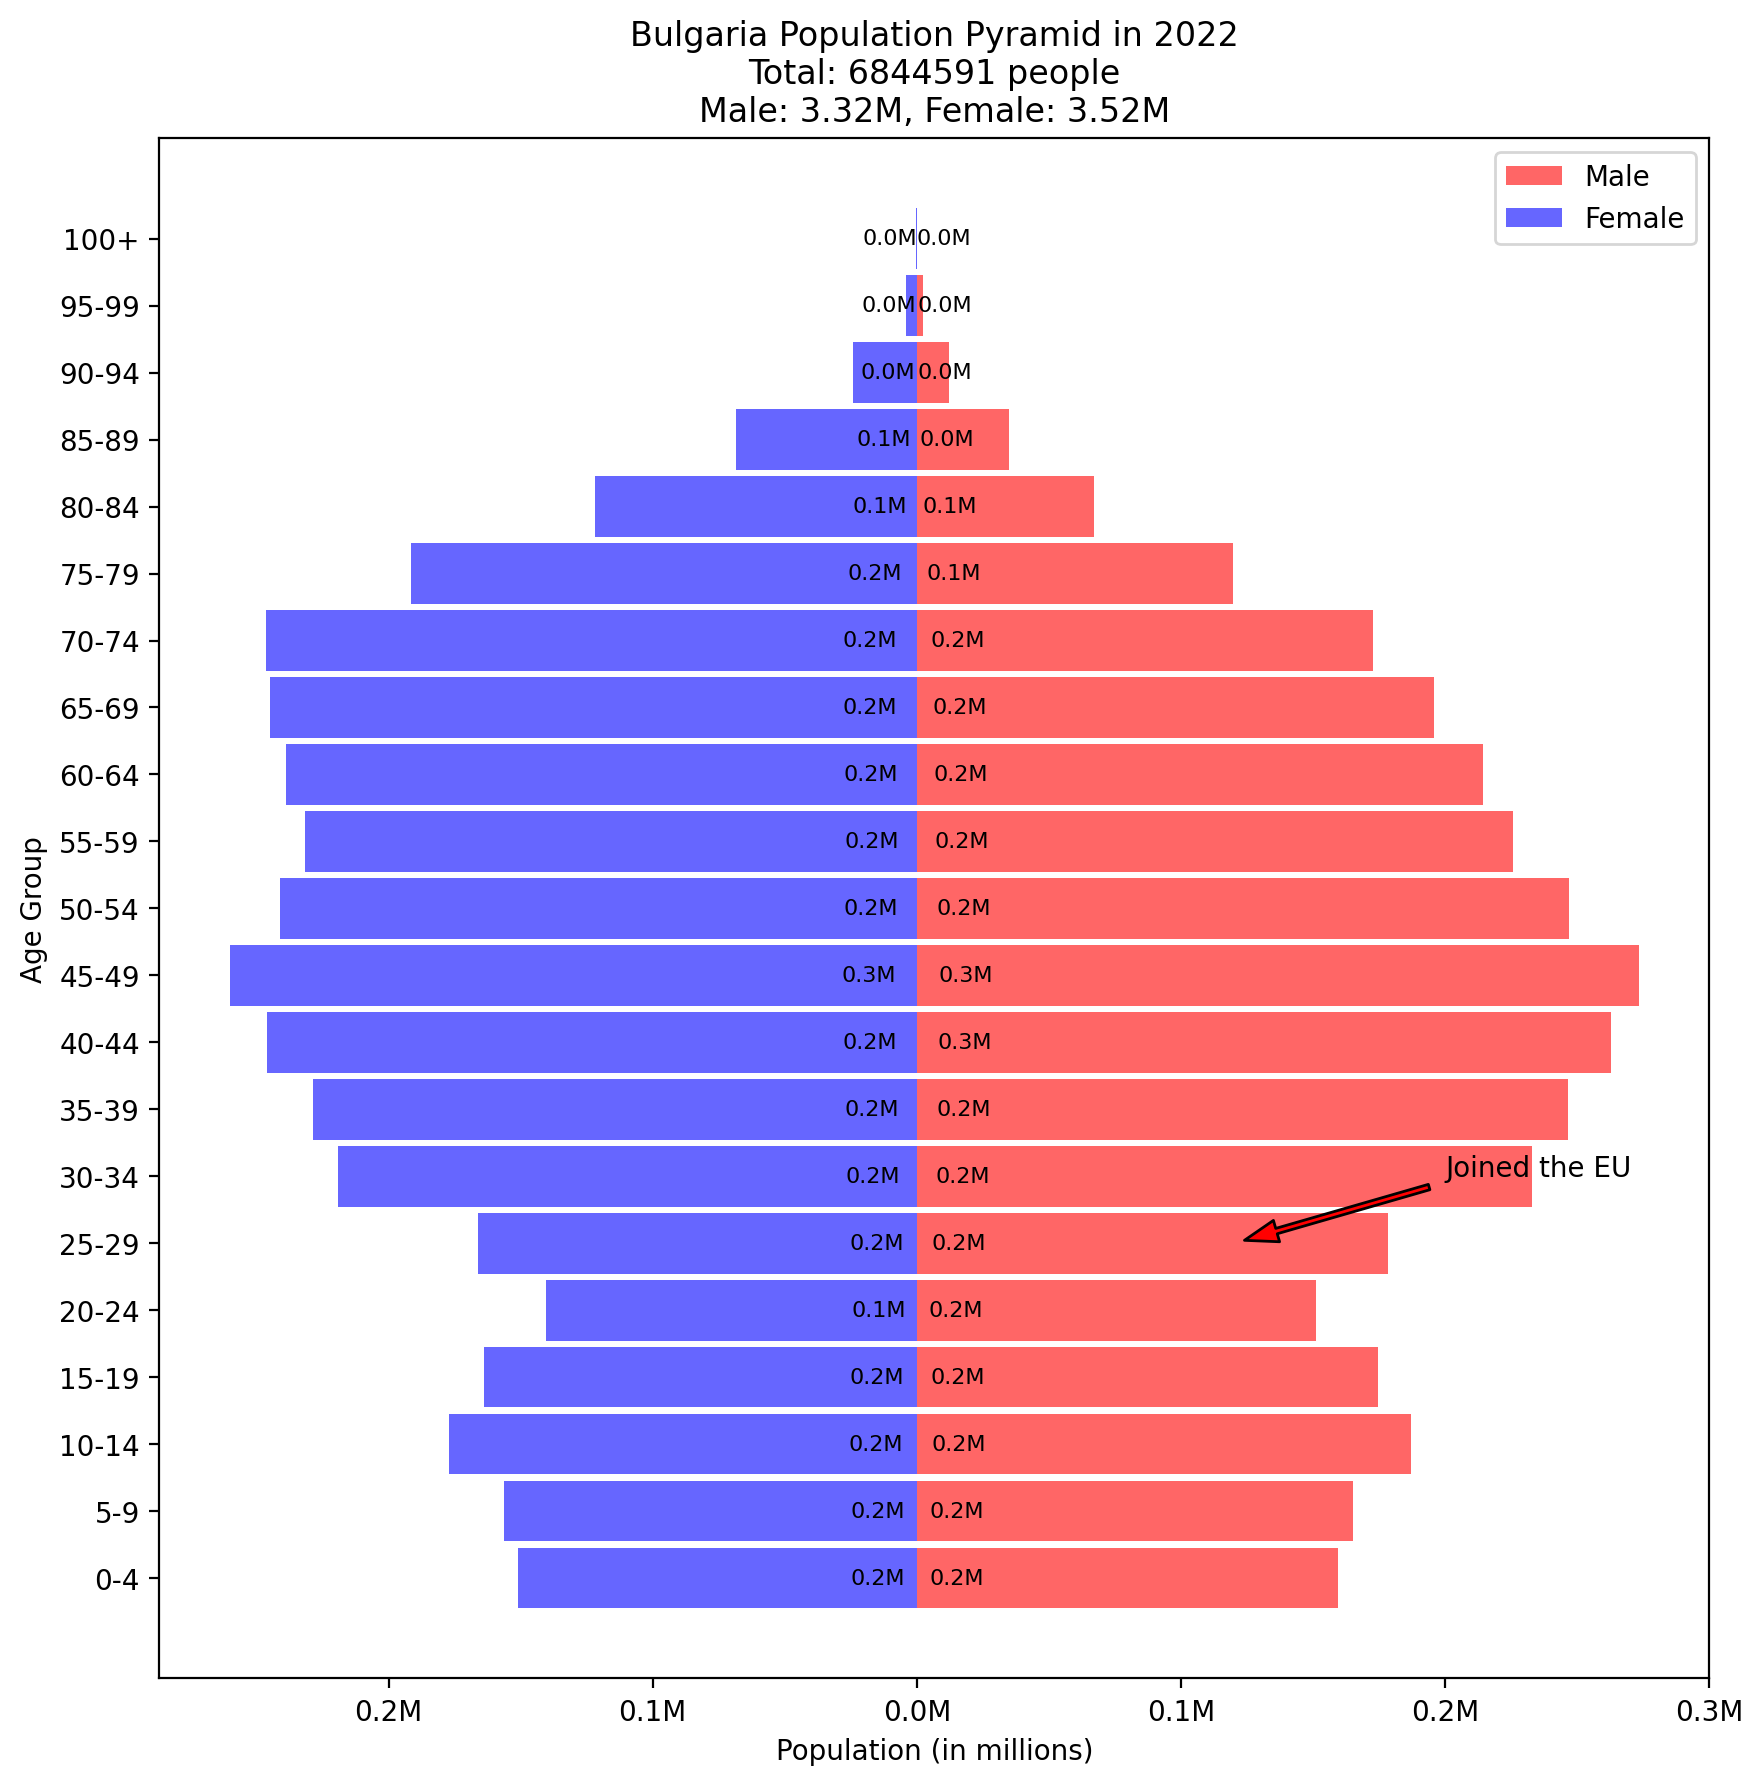

In [497]:
ax = annotationpopulationpyramid("Bulgaria", 2022)
ax.annotate('Joined the EU',
            xy=(120000, 5), 
            xytext=(200000, 6),  
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=10, color='black')
plt.show()

When Bulgaria joined the EU, many of the youth emmigrated to other European nations, seeking better economic prospects. You can see this effect in today's population pyramid with a large dip in 20-30 year olds.

### Population Density Insights:

Can use this simple formula:

\begin{equation}
\text{Population density} = \frac{\text{Total population}}{\text{Land area} \, (\text{km}^2)}
\end{equation}

#### The Territories with the Highest Population Density:

In [365]:
%%sql
SELECT name, area_land, population,
       population / area_land AS population_density
FROM facts

-- Filter out countries with zero or missing "population/land area"
WHERE population IS NOT NULL AND area_land > 0 AND area_land IS NOT NULL
and population > 0

ORDER BY 4 DESC
LIMIT 10;

 * sqlite:///factbook.db
Done.


name,area_land,population,population_density
Macau,28,592731,21168
Monaco,2,30535,15267
Singapore,687,5674472,8259
Hong Kong,1073,7141106,6655
Gaza Strip,360,1869055,5191
Gibraltar,6,29258,4876
Bahrain,760,1346613,1771
Maldives,298,393253,1319
Malta,316,413965,1310
Bermuda,54,70196,1299


While this result is objectively correct, all of these entries are incredibly small countries/territories due to them primarily consisting of urban areas. To gain a broader range of results containing preferably larger countries instead of microstates, these will be filtered out through a land area requirement of 1000 square km

#### Countries with the Highest Population Density (Land Area > 10,000 Square km)

In [366]:
%%sql
SELECT name, area_land, population,
       population / area_land AS population_density
FROM facts

-- Filter out countries with zero or missing "population/land area"
WHERE population IS NOT NULL AND area_land > 0 AND area_land IS NOT NULL
and area_land > 10000

ORDER BY 4 DESC
LIMIT 10;

 * sqlite:///factbook.db
Done.


name,area_land,population,population_density
Bangladesh,130170,168957745,1297
Taiwan,32260,23415126,725
Lebanon,10230,6184701,604
Rwanda,24668,12661733,513
"Korea, South",96920,49115196,506
Netherlands,33893,16947904,500
India,2973193,1251695584,420
Burundi,25680,10742276,418
Israel,20330,8049314,395
Belgium,30278,11323973,374


Bangladesh, despite having the same land area as Iowa or Nepal, has a similar population to that of Russia.
Taiwan's population density is also impressive, considering that the majority of the island consists of rugged mountains

#### Largest Countries with the Lowest Population Density:

In [367]:
%%sql
SELECT name, area_land, population, (population / area_land) AS population_density
FROM facts
WHERE area_land IS NOT NULL
  AND population IS NOT NULL
  AND population > 10000
--It's statistically biased to put this minimum limit of 10000 people, but I need to filter out the tiny islands with few residents
  AND area_land > 0
ORDER BY population_density ASC, area_land DESC
LIMIT 5;

 * sqlite:///factbook.db
Done.


name,area_land,population,population_density
Greenland,2166086,57733,0
Mongolia,1553556,2992908,1
Australia,7682300,22751014,2
Namibia,823290,2212307,2
Western Sahara,266000,570866,2


While Greenland is technically a territory of Denmark, it's distinct culture and location will allow it a spot in the 'country' category here.

## 5. Economic Comparisons:

### GDP Per Capita:

##### A brief definition of GDPPC:

GDP per capita is a measure of a country's economic output that shows the average income per person. It’s calculated by dividing the total value of all goods and services produced in a country (GDP) by its population. This helps give an idea of the standard of living in that country.

First, I'll obtain the GDP per Capita for all countries in the most recent year of the dataset: 2018. 

Unfortunately there are a select few countries that have chosen not to release these metrics, such as South Sudan, Cuba, Eritrea, and of course, North Korea.

In [498]:
gdpdata = pd.read_csv('GDPcleaned.csv')
gdpdata.columns = gdpdata.columns.str.strip()
gdpdata2018 = gdpdata[['Country', '2018']]
gdpdata2018.head()

,Country,2018
0,Afghanistan,1955.006208
1,Angola,6452.355165
2,Albania,13364.155400
3,Arab World,17570.137600
4,United Arab Emirates,75075.257410


16


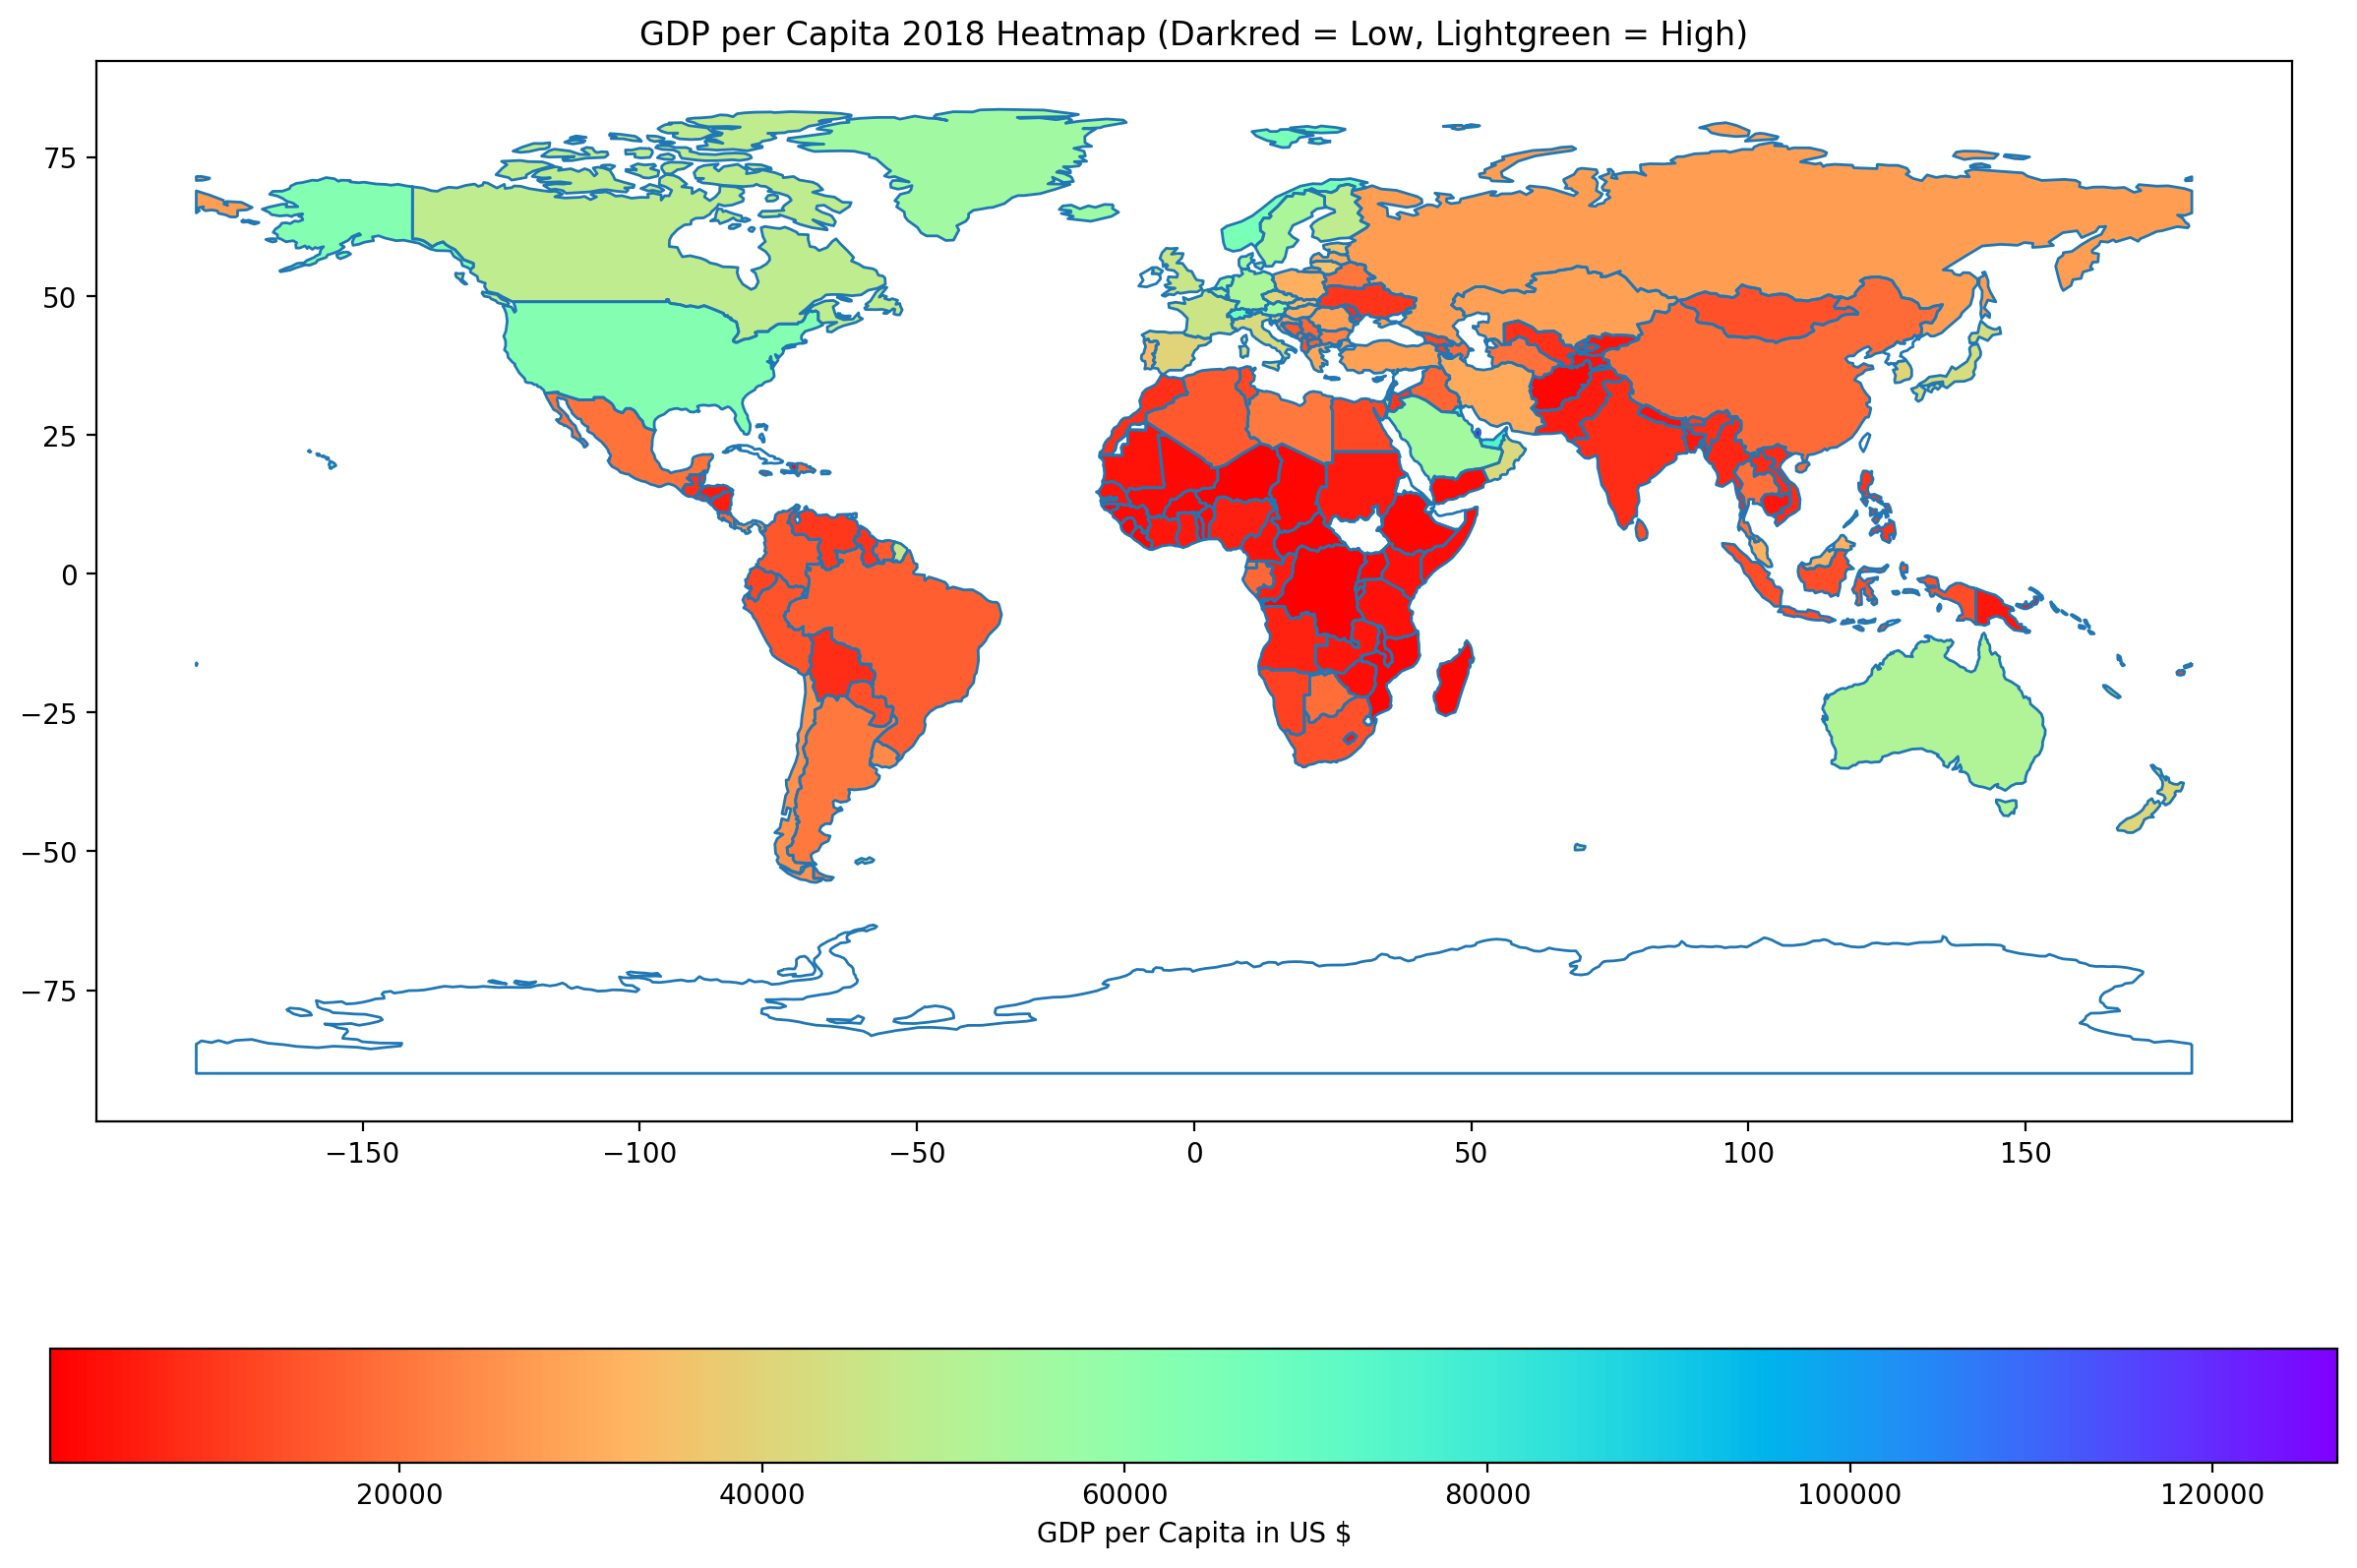

In [500]:
world = gpd.read_file('110m_cultural/ne_110m_admin_0_countries.shp')
merged = world.merge(gdpdata2018, left_on='SOVEREIGNT', right_on='Country', how='left')
print(merged['2018'].isnull().sum())
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.boundary.plot(ax=ax, linewidth=1)
merged.plot(column='2018', cmap='rainbow_r', legend=True, ax=ax,
            legend_kwds={'label': "GDP per Capita in US $",
                         'orientation': "horizontal"})
plt.title('GDP per Capita 2018 Heatmap (Darkred = Low, Lightgreen = High)')
plt.show()

#### Correlation between GDP per Capita and Birth Rate:

I'll be using logarithms here because the GDP follows the Power law, where the high GDP countries are very extreme, and would give rise to a proportional relative change in the other quantity. In this scenario, the birth rate metric is statistically vulnerable, and would heavily skew the result.

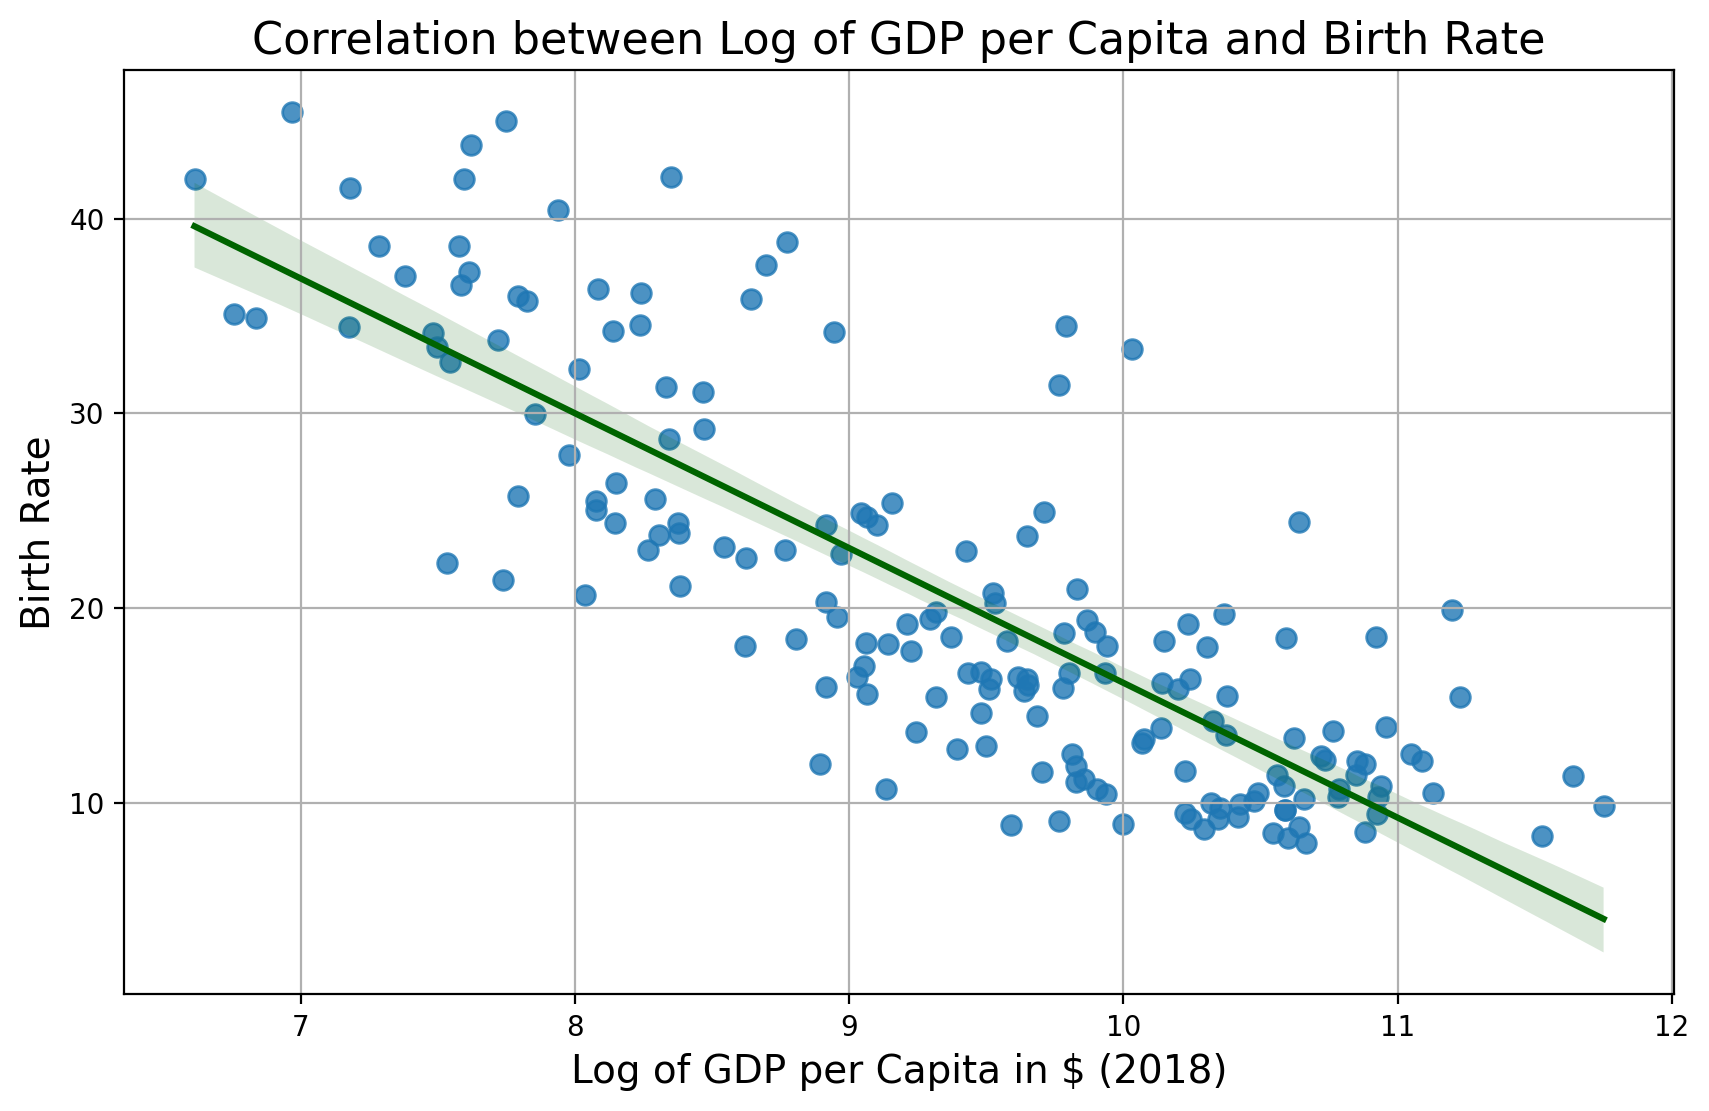

In [501]:
mergedbirthandgdp = df.merge(gdpdata2018, left_on='corrected_name', right_on='Country', how='left')
mergedbirthandgdp['log_gdp_per_capita'] = np.log(mergedbirthandgdp['2018'])

plt.figure(figsize=(10, 6))
sns.regplot(x='log_gdp_per_capita', y='birth_rate', data=mergedbirthandgdp, scatter_kws={'s':50}, line_kws={'color':'darkgreen'})
plt.xlabel('Log of GDP per Capita in $ (2018)', fontsize=14)
plt.ylabel('Birth Rate', fontsize=14)
plt.title('Correlation between Log of GDP per Capita and Birth Rate', fontsize=16)
plt.grid(True)
plt.show()

As observed, the higher a countries' GDP, the lower it's birth rate tends to be. This further solidifies the aforementioned justification in why Japan, a country with a very high GDP, has an incredibly low birth rate.

#### Top 10 Countries With the Lowest GDP

In [472]:
lowestgdp = gdpdata2018.sort_values(by='2018', ascending=True).head(10)
print(lowestgdp)

                              Country         2018
11                            Burundi   744.182072
29           Central African Republic   859.935620
36   Democratic Republic of the Congo   932.172007
127                             Niger  1063.421841
99                            Liberia  1308.629536
124                            Malawi  1310.995555
121                        Mozambique  1459.698413
156                      Sierra Leone  1601.974029
172                              Togo  1773.896632
66                      Guinea-Bissau  1799.067891


Burundi, Niger, Malawi, and Mozambique are all countries that also fall under the top 10 birth rates as stated above in the previous section.

#### Top 10 Countries with the highest GDP per Capita

In [475]:
highestgdp = gdpdata2018.sort_values(by='2018', ascending=False).head(10)
print(highestgdp)

                      Country          2018
147                     Qatar  126898.42590
106                Luxembourg  113337.42050
154                 Singapore  101531.63020
26                    Brunei    80920.04868
4        United Arab Emirates   75075.25741
96                     Kuwait   72897.56235
31                Switzerland   68060.94105
131                    Norway   65510.58527
74       Hong Kong SAR, China   64596.56385
186  United States of America   62794.58565


For the number of people Qatar have, they are adding 171 times more value to their country than Burundi.

#### The Top 10 Fastest Growing Economies

In [487]:
gdpgrowth = gdpdata[['Country', '1990', '2018']].dropna()
gdpgrowth['GDP Growth (%)'] = ((gdpgrowth['2018'] - gdpgrowth['1990']) / gdpgrowth['1990']) * 100
fastestgrowingeconomies = gdpgrowth.sort_values(by='GDP Growth (%)', ascending=False).head(10)
print(fastestgrowingeconomies)

               Country         1990          2018  GDP Growth (%)
67   Equatorial Guinea   660.453110  22743.824430     3343.669818
33               China   987.641179  18236.612980     1746.481634
118            Myanmar   473.863602   6674.028647     1308.428211
191            Vietnam   945.870327   7447.814334      687.403318
40          Cabo Verde  1087.722637   7454.063917      585.290870
97                Laos  1108.386981   7439.599360      571.209558
27              Bhutan  1527.318005  10167.934060      565.737851
80               India  1236.671208   7762.881770      527.723984
103          Sri Lanka  2344.671738  13473.663090      474.650296
32               Chile  4511.170059  25222.527780      459.112768


Dont be mistaken! Equatorial Guinea has one of the worst reputations for NOT distributing their oil wealth into the hands of its citizens!

#### Top 10 Fastest Growing Economies Visualized

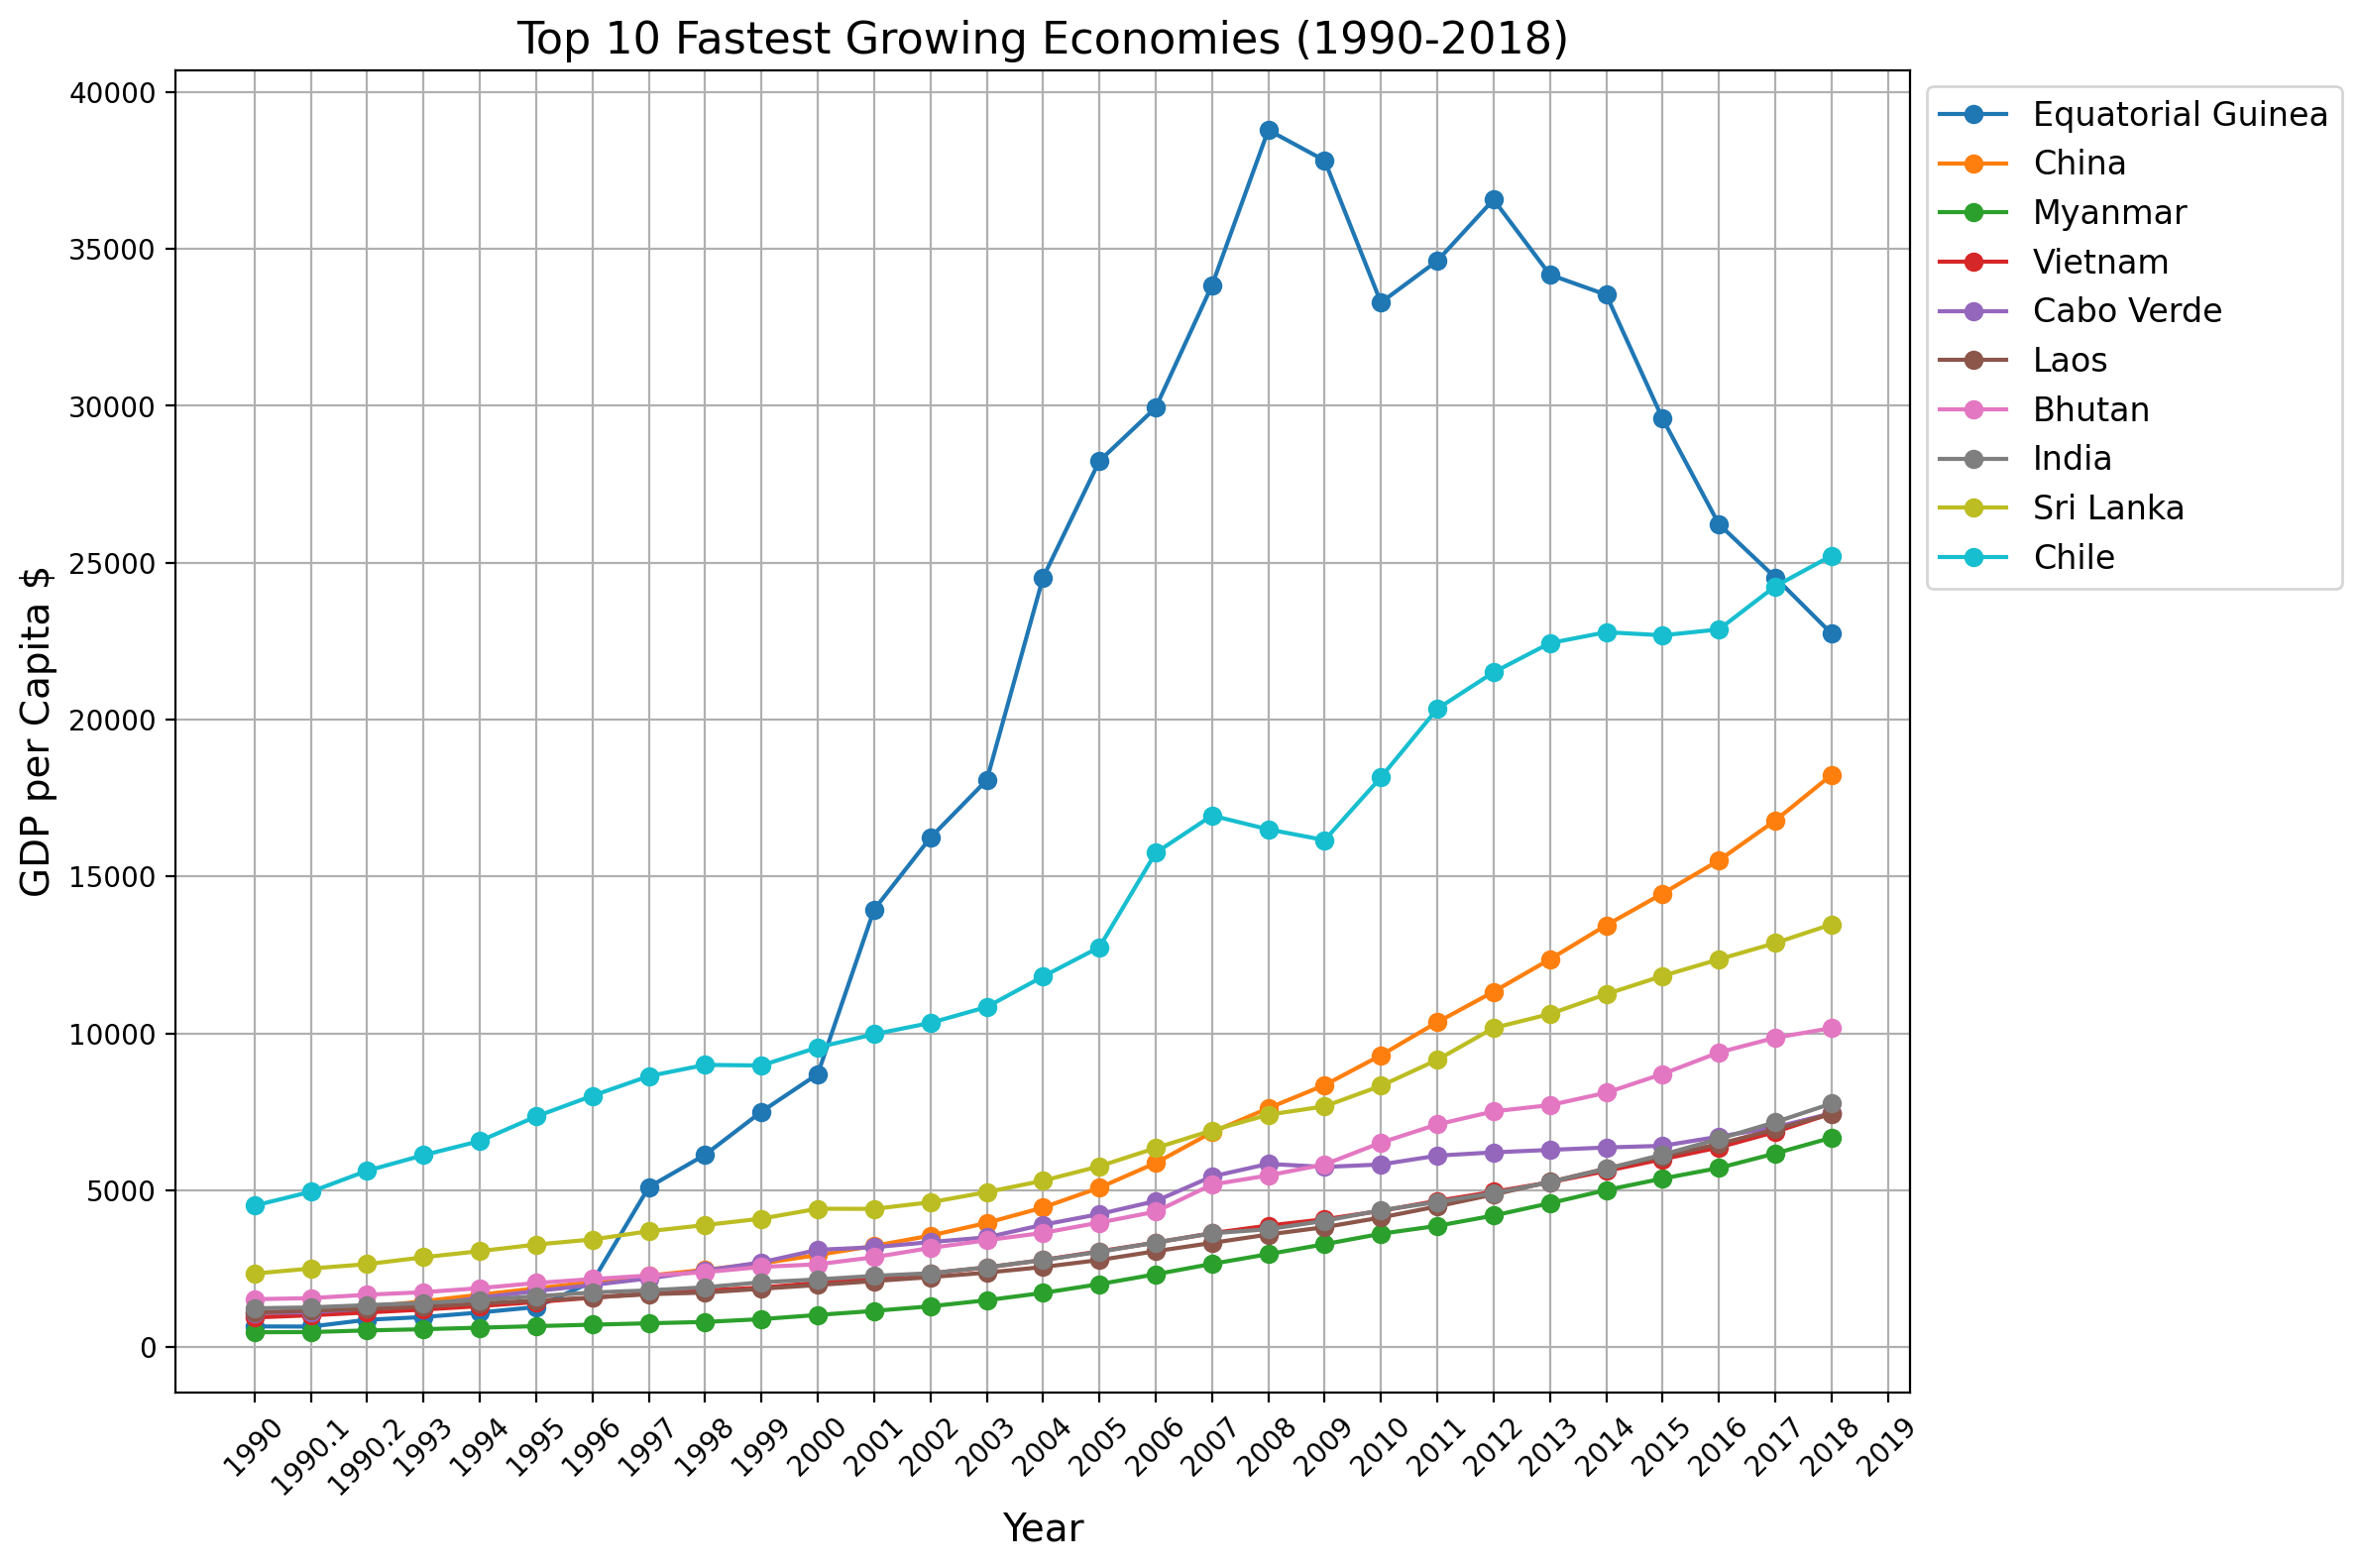

In [502]:
top10countries = fastestgrowingeconomies['Country'].tolist()
top10gdpdata = gdpdata[gdpdata['Country'].isin(top10countries)]
top10gdpdata = top10gdpdata.set_index('Country').drop(columns=['Country Code']).T
plt.figure(figsize=(12, 8))

for country in top10countries:
    plt.plot(top10gdpdata.index, top10gdpdata[country], marker='o', label=country)

plt.xlabel('Year', fontsize=14)
plt.ylabel('GDP per Capita $', fontsize=14)
plt.title('Top 10 Fastest Growing Economies (1990-2018)', fontsize=16)
plt.grid(True)

plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.tight_layout()


### Credit Ratings

#### But what are Credit Ratings? An explanation:

A credit rating is an evaluation of the creditworthiness of a country or organization, reflecting its ability to repay borrowed money. These ratings are typically assigned by credit rating agencies and are used by investors and governments to assess the risk associated with lending money or investing in a certain country. Credit ratings range from the highest level of 'AAA+,' indicating the safest investment, to lower levels (ex. CCC-), indicating increased risk of a loss of invested money. Analyzing global credit ratings provides valuable insight into the economic stability and investment environment across different regions. This data came from https://www.spglobal.com/ratings/en/.

In [368]:
ratings = pd.read_csv("editedcleanedratings.csv")
ratings.head()

,Country/Territory,Rating,Outlook,Date,RatingNumber
0,United Arab Emirates,AA,Stable,30 May 2023,24
1,Albania,BB-,Positive,23 March 2024,14
2,Andorra,BBB+,Positive,12 May 2023,19
3,Angola,B-,Stable,4 February 2022,11
4,Argentina,CCC,Stable,15 March 2024,9


Because it's a lot easier to work with numerical integers rather than alphabetical ratings, I have converted each letter score to a number, as seen above. For example, AAA+ has a score of 27, BBB: 18, CCC: 9, etc.

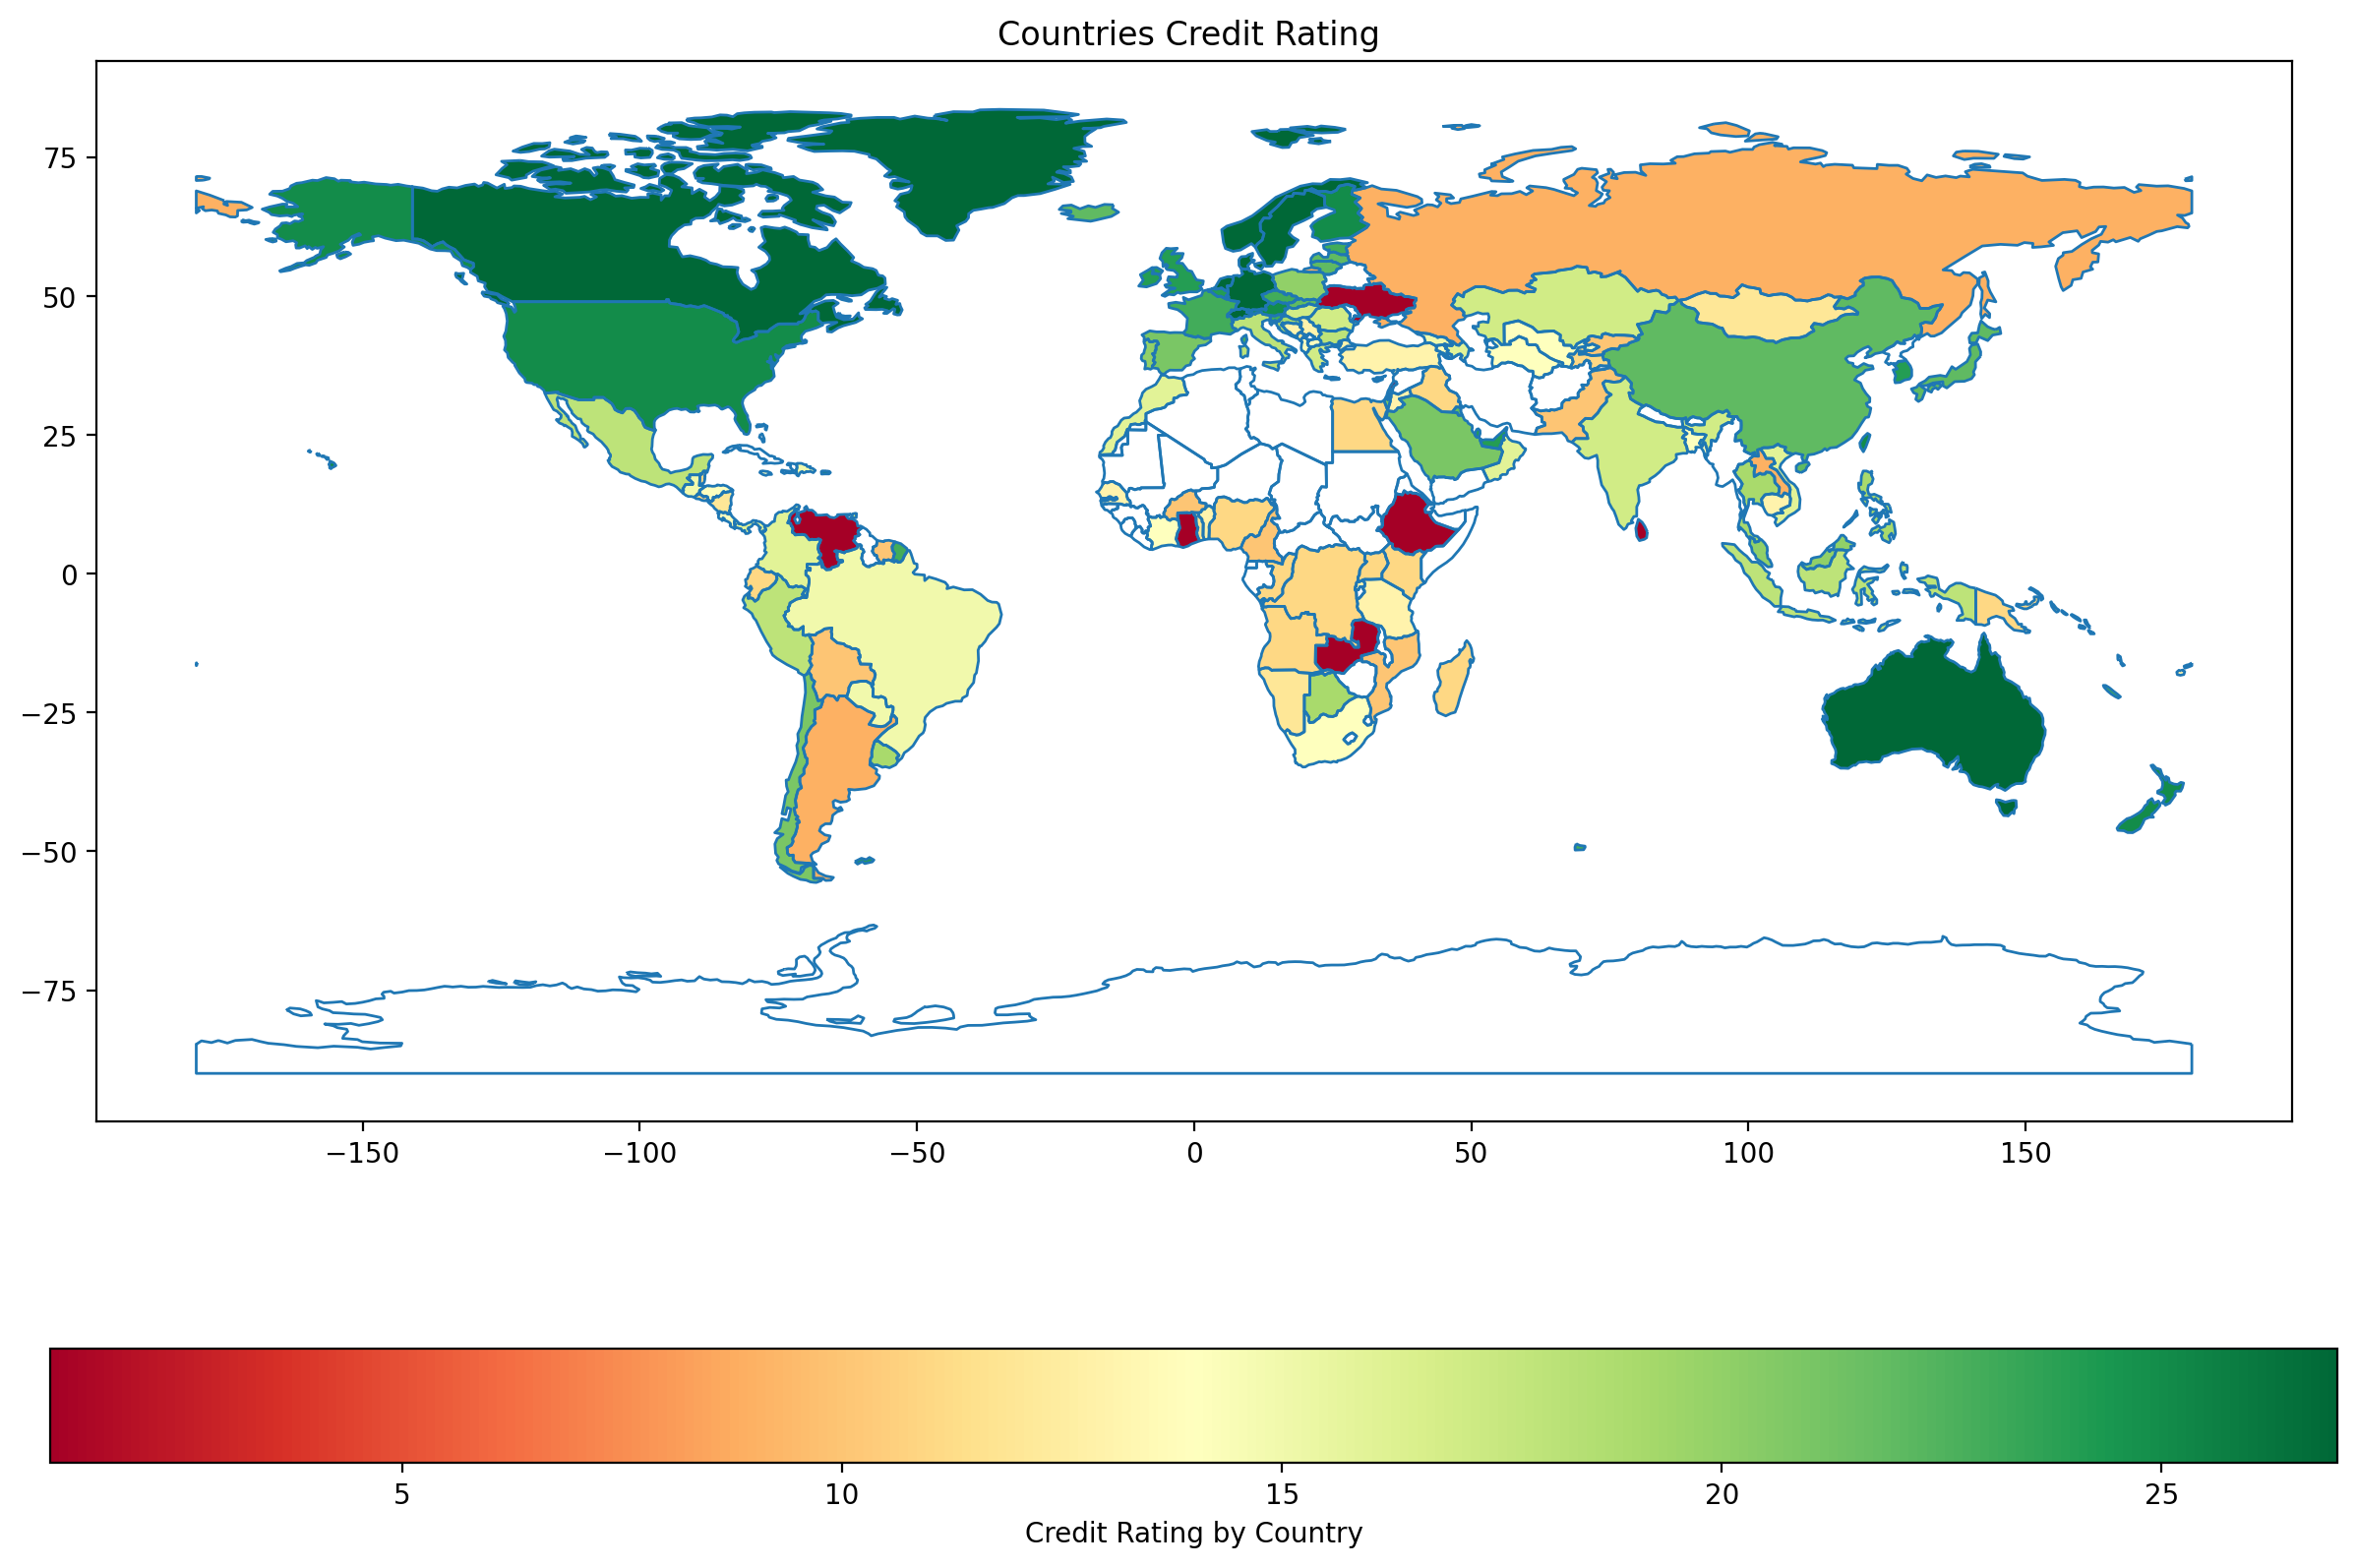

In [503]:
world = gpd.read_file('110m_cultural/ne_110m_admin_0_countries.shp')
merged = world.merge(ratings, left_on='SOVEREIGNT', right_on='Country/Territory', how='left')
# merged
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.boundary.plot(ax=ax, linewidth=1)
merged.plot(column='RatingNumber', cmap='RdYlGn', legend=True, ax=ax,
            legend_kwds={'label': "Credit Rating by Country",
                         'orientation': "horizontal"})
plt.title('Countries Credit Rating ')
plt.show()

Some of the data for certain countries is missing due to them either purposely withholding or supplying incorrect credit data, or merely due to a country's creditworthiness being deemed hopeless by all credit rating agencies.

In [370]:
top10creditratings = ratings.nlargest(10, 'RatingNumber')
print("Top 10 Countries by RatingNumber:")
print(top10creditratings)

Top 10 Countries by RatingNumber:
    Country/Territory Rating  Outlook              Date  RatingNumber
7           Australia    AAA  Stable        6 June 2021            27
26             Canada    AAA  Stable       29 July 2002            27
37            Denmark    AAA  Stable   27 February 2001            27
49            Germany    AAA  Stable    13 January 2012            27
72      Liechtenstein    AAA  Stable   26 February 2016            27
74         Luxembourg    AAA  Stable    14 January 2013            27
84        Netherlands    AAA  Stable   20 November 2015            27
89             Norway    AAA  Stable    8 November 1990            27
106         Singapore    AAA  Stable       6 March 1995            27
114            Sweden    AAA  Stable   16 February 2004            27


In [371]:
bottom5creditratings = ratings.nsmallest(5, 'RatingNumber')
print("\nBottom 5 Countries by RatingNumber:")
print(bottom5creditratings)


Bottom 5 Countries by RatingNumber:
    Country/Territory Rating Outlook              Date  RatingNumber
43           Ethiopia     SD     NaN  15 December 2023             1
50              Ghana     SD     NaN  20 December 2022             1
71            Lebanon     SD     NaN     11 March 2020             1
112         Sri Lanka     SD     NaN     25 April 2022             1
125           Ukraine     SD     NaN     2 August 2024             1


#### Final Question: Is there a correlation between a countries Credit Rating and their GDP per Capita?

The answer might seem obvious but it should be visualized anyway.

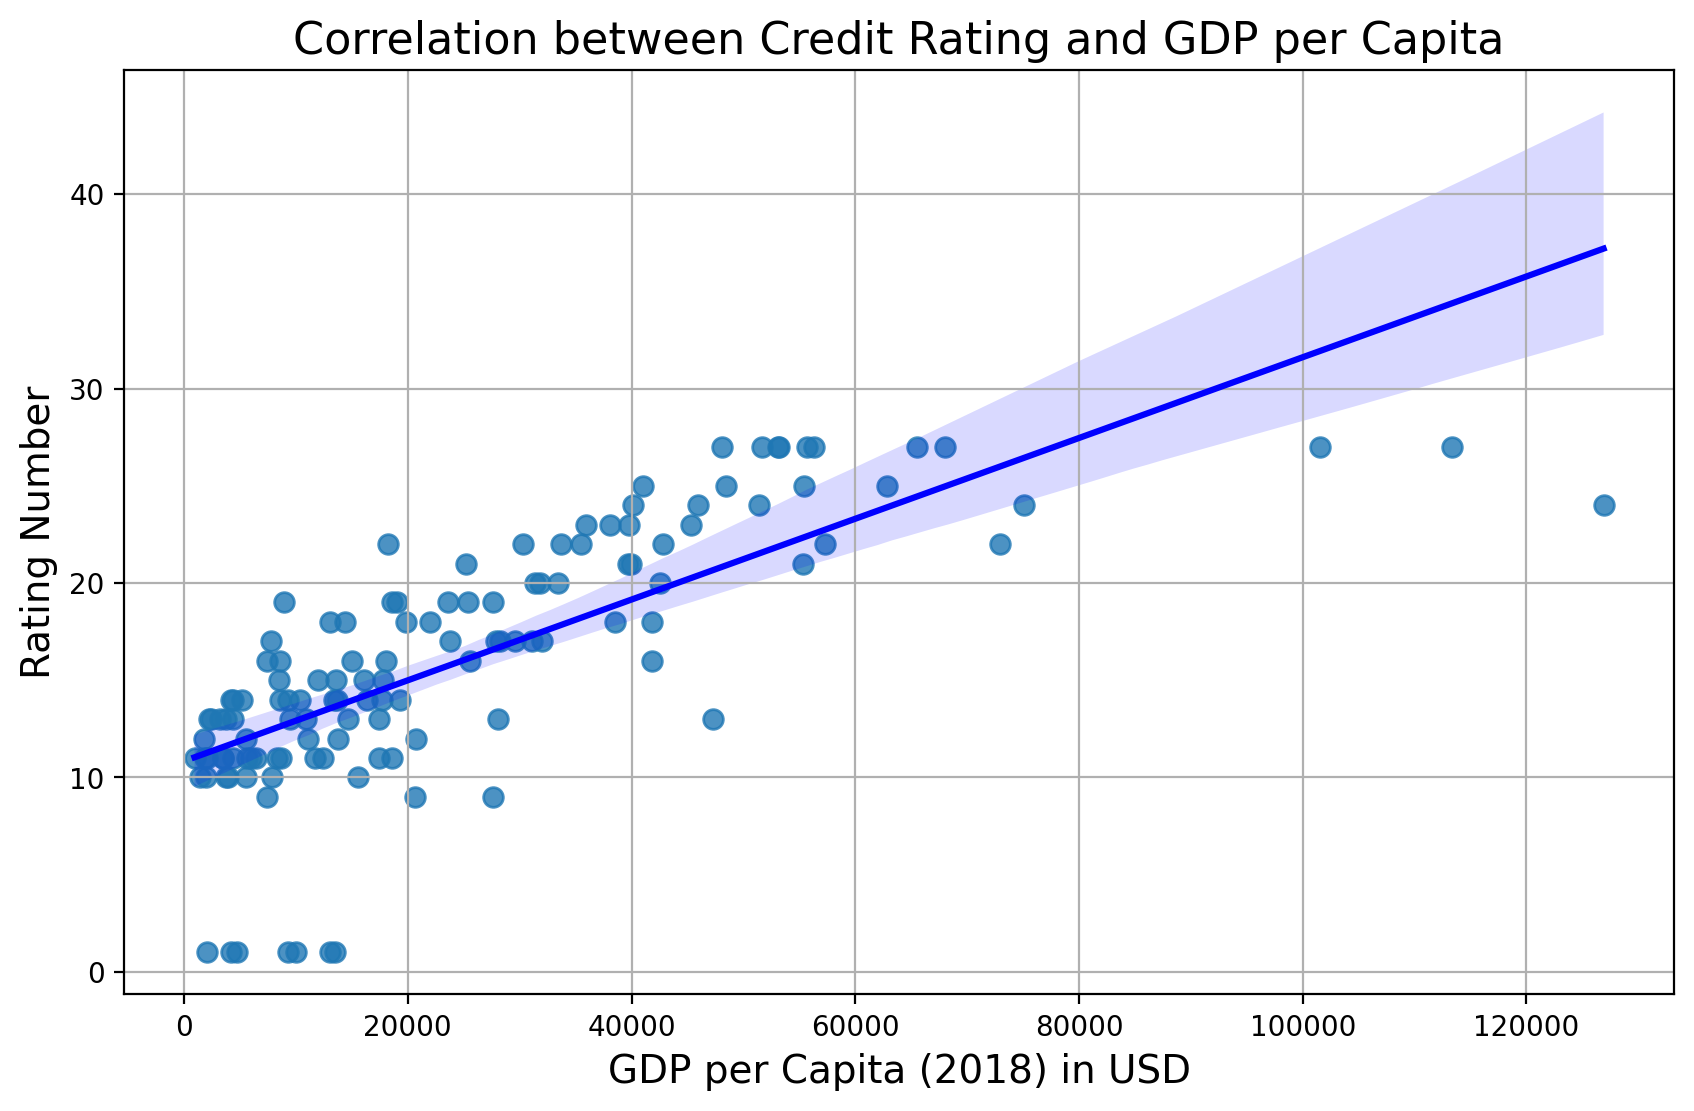

In [504]:
mergedgdpandcredit = gdpdata2018.merge(ratings, left_on='Country', right_on='Country/Territory', how='left')
plt.figure(figsize=(10, 6))
sns.regplot(x='2018', y='RatingNumber', data=mergedgdpandcredit, scatter_kws={'s':50}, line_kws={'color':'blue'})
plt.xlabel('GDP per Capita (2018) in USD', fontsize=14)
plt.ylabel('Rating Number', fontsize=14)
plt.title('Correlation between Credit Rating and GDP per Capita', fontsize=16)
plt.grid(True)
plt.show()

### Thank you for Reading

##### Back to Top